In [1]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm

print("\nReportLab OK")

Python do notebook:
C:\Users\beelt\Documents\collections_case_candidate\.venv\Scripts\python.exe

ReportLab OK


In [2]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")

In [3]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())

Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


##_______________________________________________________________ "" ____________________________________________________________

##_______________________________________________________________ "" ____________________________________________________________

In [5]:
import pandas as pd
import numpy as np

# ============================================================
# DASHBOARD — ONE-TOUCH FULL PAYERS
# Cliente recebeu 1 única mensagem e quitou em 1 pagamento
# ============================================================

df = wa.copy()

# ------------------------------------------------------------
# 0. TIPOS
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

numeric_cols = [
    "days_past_due",
    "outstanding_balance_brl",
    "monthly_salary_brl",
    "payday_day_of_month",
    "amount_paid_brl",
    "paid_within_72h"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# 1. QUANTIDADE DE MENSAGENS POR CLIENTE
# ============================================================

customer_msg_count = (
    df.groupby("customer_id")
      .size()
      .rename("n_messages_total")
      .reset_index()
)

df = df.merge(
    customer_msg_count,
    on="customer_id",
    how="left"
)


# ============================================================
# 2. CLIENTES QUE RECEBERAM EXATAMENTE UMA MENSAGEM
# ============================================================

one_touch = (
    df.loc[df["n_messages_total"].eq(1)]
      .copy()
)

print("=" * 80)
print("ONE-TOUCH POPULATION")
print("=" * 80)

print(f"Total customers WA : {df['customer_id'].nunique():,}")
print(f"One-touch customers: {one_touch['customer_id'].nunique():,}")
print(
    f"Share              : "
    f"{one_touch['customer_id'].nunique() / df['customer_id'].nunique():.1%}"
)

ONE-TOUCH POPULATION
Total customers WA : 11,724
One-touch customers: 1,173
Share              : 10.0%


In [6]:
# ============================================================
# 3. IDENTIFICAR QUITAÇÃO INTEGRAL
# ============================================================

# Tolerância de centavos
TOL = 0.05

one_touch["full_payment"] = (
    one_touch["amount_paid_brl"].fillna(0)
    >=
    one_touch["outstanding_balance_brl"].fillna(np.inf) - TOL
).astype(int)

# Também guardamos qualquer pagamento
one_touch["any_payment"] = (
    one_touch["amount_paid_brl"].fillna(0) > 0
).astype(int)


# ============================================================
# 4. ONE-TOUCH FULL PAYERS
# ============================================================

one_touch_full = (
    one_touch.loc[
        one_touch["full_payment"].eq(1)
    ]
    .copy()
)


# ============================================================
# QA
# ============================================================

print("\n" + "=" * 80)
print("ONE-TOUCH FULL PAYMENT")
print("=" * 80)

print(f"One-touch customers : {len(one_touch):,}")
print(f"Any payment         : {one_touch['any_payment'].sum():,}")
print(f"Full payment        : {one_touch['full_payment'].sum():,}")

print(
    f"Full payment rate   : "
    f"{one_touch['full_payment'].mean():.2%}"
)

print(
    f"Recovered amount    : "
    f"R$ {one_touch_full['amount_paid_brl'].sum():,.2f}"
)

print(
    f"Median balance      : "
    f"R$ {one_touch_full['outstanding_balance_brl'].median():,.2f}"
)

print(
    f"Median salary       : "
    f"R$ {one_touch_full['monthly_salary_brl'].median():,.2f}"
)


ONE-TOUCH FULL PAYMENT
One-touch customers : 1,173
Any payment         : 785
Full payment        : 757
Full payment rate   : 64.54%
Recovered amount    : R$ 606,176.06
Median balance      : R$ 675.57
Median salary       : R$ 2,510.00


In [7]:
# ============================================================
# FEATURES — DASHBOARD
# ============================================================

dash = one_touch.copy()


# ------------------------------------------------------------
# 1. DPD BUCKET
# ------------------------------------------------------------

dash["dpd_bucket"] = pd.cut(
    dash["days_past_due"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 2. AFFORDABILITY
# saldo / salário
# ------------------------------------------------------------

dash["balance_salary_ratio"] = (
    dash["outstanding_balance_brl"]
    /
    dash["monthly_salary_brl"]
)

dash["affordability_bucket"] = pd.cut(
    dash["balance_salary_ratio"],
    bins=[0, .10, .25, .50, 1, np.inf],
    labels=[
        "≤10%",
        "10–25%",
        "25–50%",
        "50–100%",
        ">100%"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 3. WEEKDAY
# ------------------------------------------------------------

weekday_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

dash["weekday"] = (
    dash["sent_at"]
    .dt.dayofweek
    .map(weekday_map)
)


# ------------------------------------------------------------
# 4. HOUR
# ------------------------------------------------------------

dash["hour"] = dash["sent_at"].dt.hour

dash["hour_bucket"] = pd.cut(
    dash["hour"],
    bins=[-1, 10, 13, 16, 19, 23],
    labels=[
        "00–10",
        "11–13",
        "14–16",
        "17–19",
        "20–23"
    ]
)


# ------------------------------------------------------------
# 5. DISTÂNCIA PARA PAYDAY
# ------------------------------------------------------------

dash["sent_day"] = dash["sent_at"].dt.day

dash["days_from_payday"] = (
    dash["sent_day"]
    -
    dash["payday_day_of_month"]
)

# negativo = mensagem ANTES do payday
# zero     = payday
# positivo = mensagem DEPOIS do payday

dash["payday_bucket"] = pd.cut(
    dash["days_from_payday"],
    bins=[
        -np.inf,
        -8,
        -4,
        -1,
        0,
        3,
        7,
        np.inf
    ],
    labels=[
        "≤ -8d",
        "-7 a -4d",
        "-3 a -1d",
        "Payday",
        "+1 a +3d",
        "+4 a +7d",
        "≥ +8d"
    ]
)

In [8]:
# ============================================================
# SUMMARY FUNCTION
# ============================================================

def one_touch_summary(data, group_col):

    out = (
        data
        .groupby(group_col, observed=True)
        .agg(
            customers=("customer_id", "nunique"),
            full_payers=("full_payment", "sum"),
            recovered_brl=("amount_paid_brl", "sum"),
            avg_balance=("outstanding_balance_brl", "mean"),
            median_balance=("outstanding_balance_brl", "median")
        )
        .reset_index()
    )

    out["full_payment_rate"] = (
        out["full_payers"]
        /
        out["customers"]
    )

    return out

In [9]:
dpd_summary = one_touch_summary(
    dash,
    "dpd_bucket"
)

print("\nDPD")
display(dpd_summary)


DPD


,dpd_bucket,customers,full_payers,recovered_brl,avg_balance,median_balance,full_payment_rate
0,01–07,1094,709,"577,243.06",816.76,693.88,0.65
1,08–15,73,44,"36,184.04",846.92,734.17,0.60
2,16–30,6,4,"2,371.11",472.89,456.46,0.67


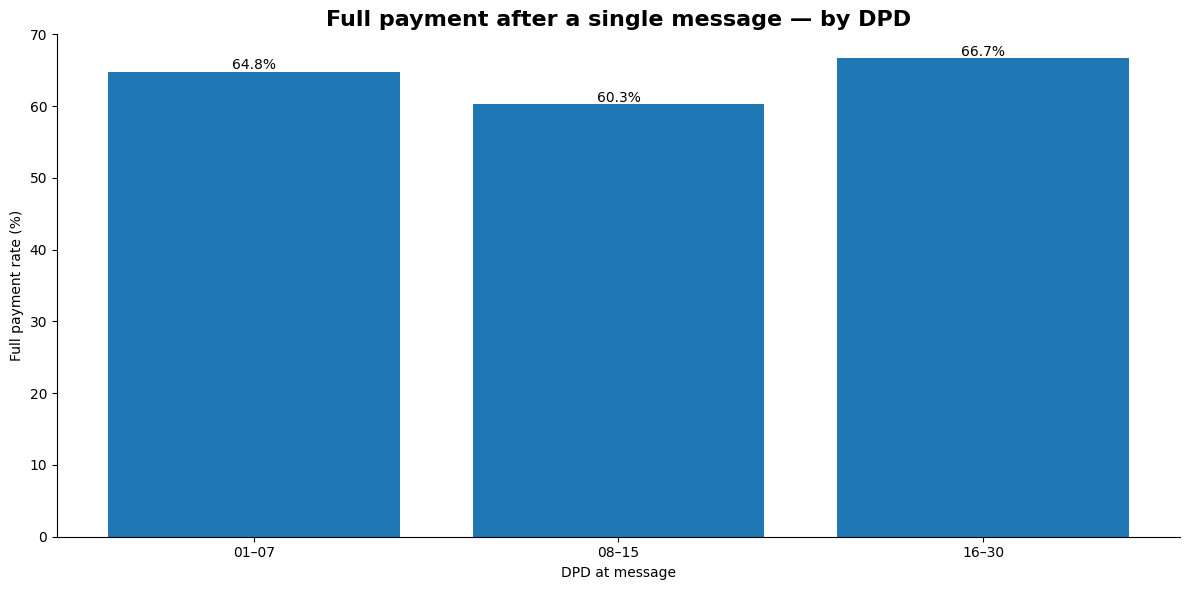

In [10]:
import matplotlib.pyplot as plt

plot = dpd_summary.copy()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    plot["dpd_bucket"].astype(str),
    plot["full_payment_rate"] * 100
)

ax.set_title(
    "Full payment after a single message — by DPD",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Full payment rate (%)")
ax.set_xlabel("DPD at message")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    plot["full_payment_rate"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [11]:
aff_summary = one_touch_summary(
    dash,
    "affordability_bucket"
)

display(aff_summary)

,affordability_bucket,customers,full_payers,recovered_brl,avg_balance,median_balance,full_payment_rate
0,≤10%,37,26,"7,880.04",301.05,250.68,0.70
1,10–25%,426,295,"136,679.97",467.08,378.60,0.69
2,25–50%,606,381,"397,387.58","1,019.81",917.23,0.63
3,50–100%,104,55,"73,850.62","1,250.66","1,229.76",0.53


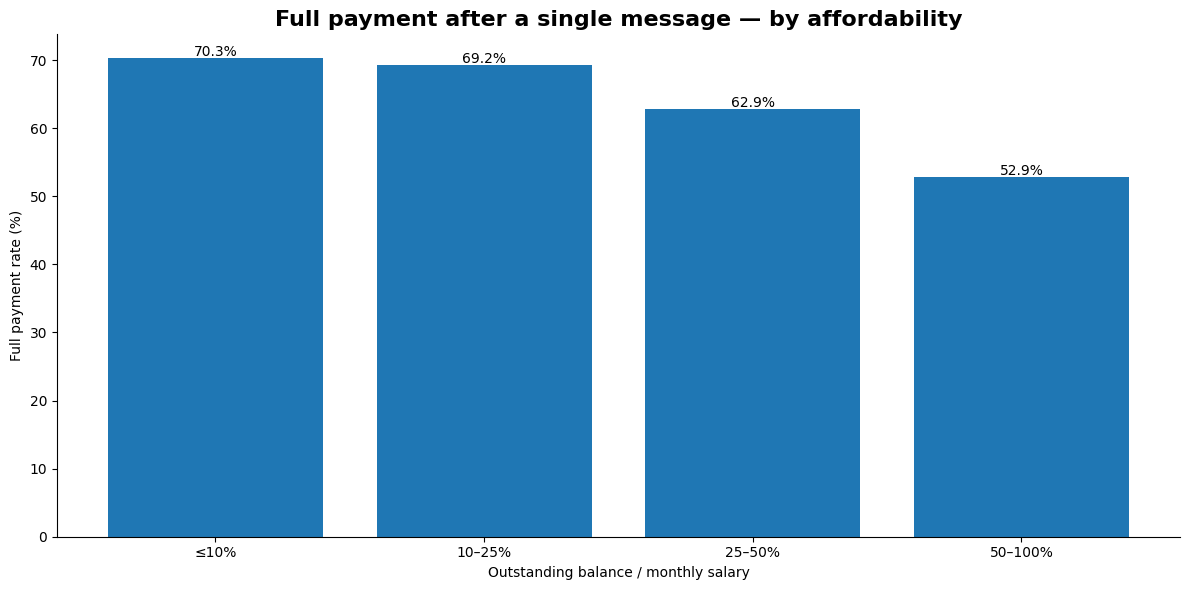

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    aff_summary["affordability_bucket"].astype(str),
    aff_summary["full_payment_rate"] * 100
)

ax.set_title(
    "Full payment after a single message — by affordability",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Full payment rate (%)")
ax.set_xlabel("Outstanding balance / monthly salary")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    aff_summary["full_payment_rate"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [13]:
payday_summary = one_touch_summary(
    dash,
    "payday_bucket"
)

display(payday_summary)

,payday_bucket,customers,full_payers,recovered_brl,avg_balance,median_balance,full_payment_rate
0,≤ -8d,139,135,"107,956.46",796.94,725.19,0.97
1,-7 a -4d,87,79,"68,009.15",867.58,765.38,0.91
2,-3 a -1d,70,53,"42,456.61",779.39,691.40,0.76
3,Payday,44,37,"32,070.45",845.61,744.61,0.84
4,+1 a +3d,110,81,"67,495.70",862.30,778.64,0.74
5,+4 a +7d,142,106,"78,482.91",750.01,635.43,0.75
6,≥ +8d,581,266,"219,326.93",824.13,684.24,0.46


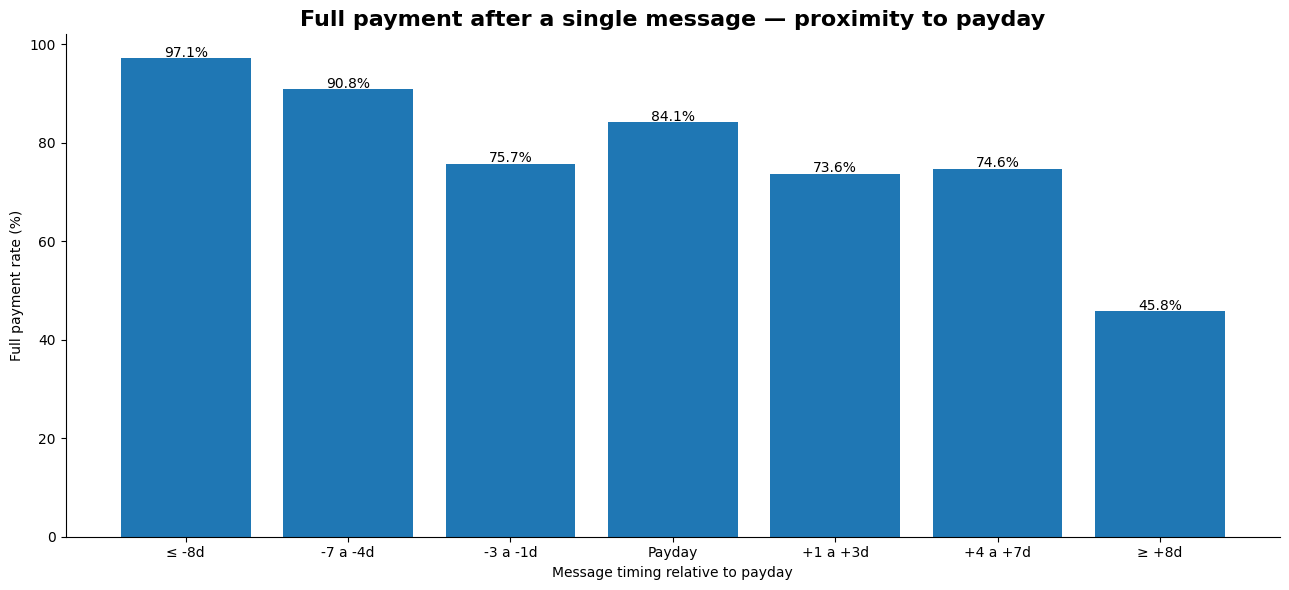

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    payday_summary["payday_bucket"].astype(str),
    payday_summary["full_payment_rate"] * 100
)

ax.set_title(
    "Full payment after a single message — proximity to payday",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Full payment rate (%)")
ax.set_xlabel("Message timing relative to payday")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    payday_summary["full_payment_rate"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + .3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [15]:
weekday_summary = one_touch_summary(
    dash,
    "weekday"
)

weekday_order = [
    "Mon", "Tue", "Wed",
    "Thu", "Fri", "Sat", "Sun"
]

weekday_summary["weekday"] = pd.Categorical(
    weekday_summary["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_summary = weekday_summary.sort_values("weekday")

display(weekday_summary)

,weekday,customers,full_payers,recovered_brl,avg_balance,median_balance,full_payment_rate
1,Mon,325,159,"129,853.24",841.01,725.84,0.49
5,Tue,173,146,"113,689.01",764.36,632.81,0.84
6,Wed,140,108,"90,856.80",836.46,716.25,0.77
4,Thu,169,128,"105,941.05",823.02,729.48,0.76
0,Fri,187,115,"91,429.54",787.01,651.55,0.61
2,Sat,99,56,"41,624.97",758.57,627.21,0.57
3,Sun,80,45,"42,403.60",927.08,787.01,0.56


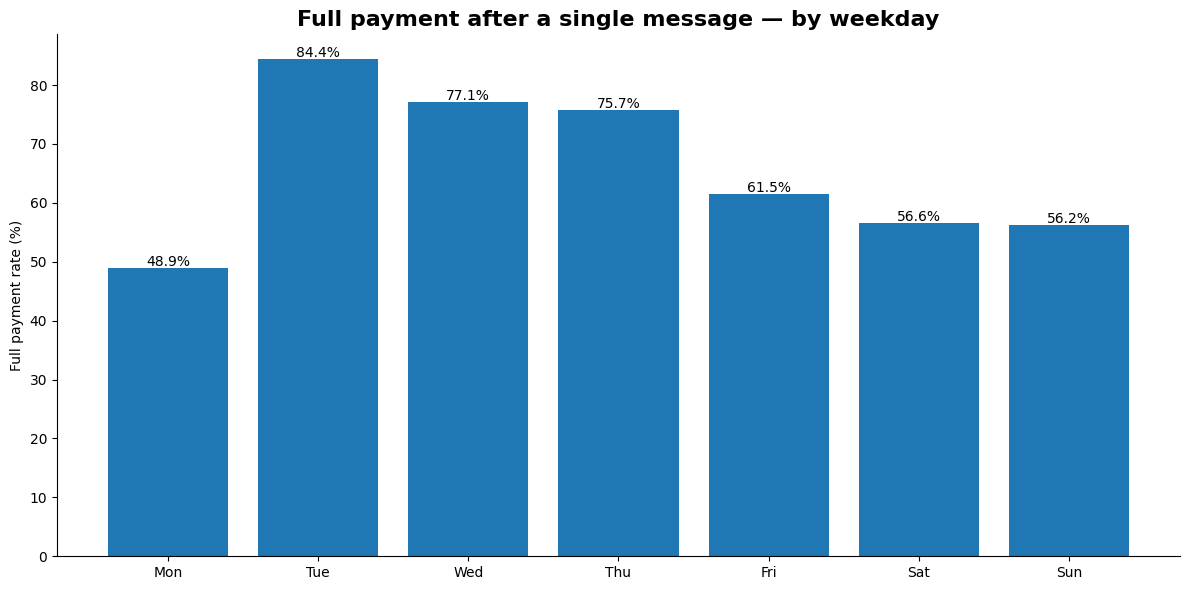

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    weekday_summary["weekday"].astype(str),
    weekday_summary["full_payment_rate"] * 100
)

ax.set_title(
    "Full payment after a single message — by weekday",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Full payment rate (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    weekday_summary["full_payment_rate"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + .3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [17]:
hour_summary = one_touch_summary(
    dash,
    "hour_bucket"
)

display(hour_summary)

,hour_bucket,customers,full_payers,recovered_brl,avg_balance,median_balance,full_payment_rate
0,00–10,314,194,"155,252.17",815.48,692.89,0.62
1,11–13,369,256,"201,082.94",784.43,673.09,0.69
2,14–16,254,151,"121,620.39",814.94,694.00,0.59
3,17–19,181,123,"105,723.63",853.11,740.94,0.68
4,20–23,55,33,"32,119.08",932.17,781.98,0.60


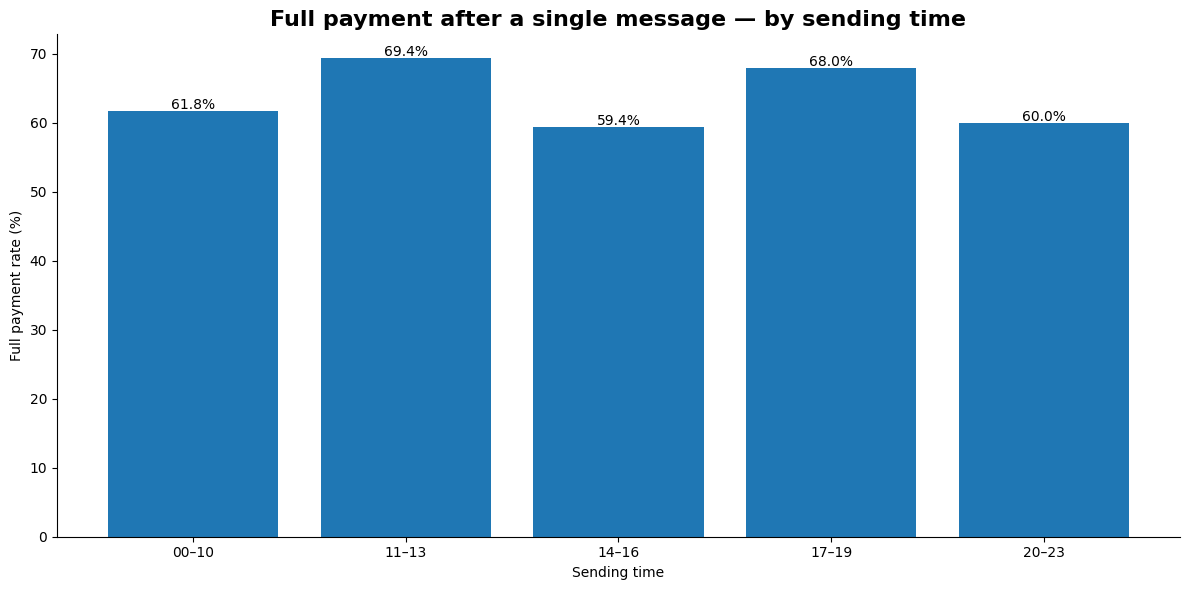

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    hour_summary["hour_bucket"].astype(str),
    hour_summary["full_payment_rate"] * 100
)

ax.set_title(
    "Full payment after a single message — by sending time",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Full payment rate (%)")
ax.set_xlabel("Sending time")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    hour_summary["full_payment_rate"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + .3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [19]:
template_summary = one_touch_summary(
    dash,
    "template"
)

template_summary = template_summary.sort_values(
    "full_payment_rate",
    ascending=False
)

display(template_summary)

,template,customers,full_payers,recovered_brl,avg_balance,median_balance,full_payment_rate
1,pix_link,374,264,"214,992.93",788.99,663.75,0.71
2,urgent_reminder,43,28,"22,440.30",770.34,646.27,0.65
0,friendly_reminder,756,465,"378,364.98",833.32,724.37,0.62


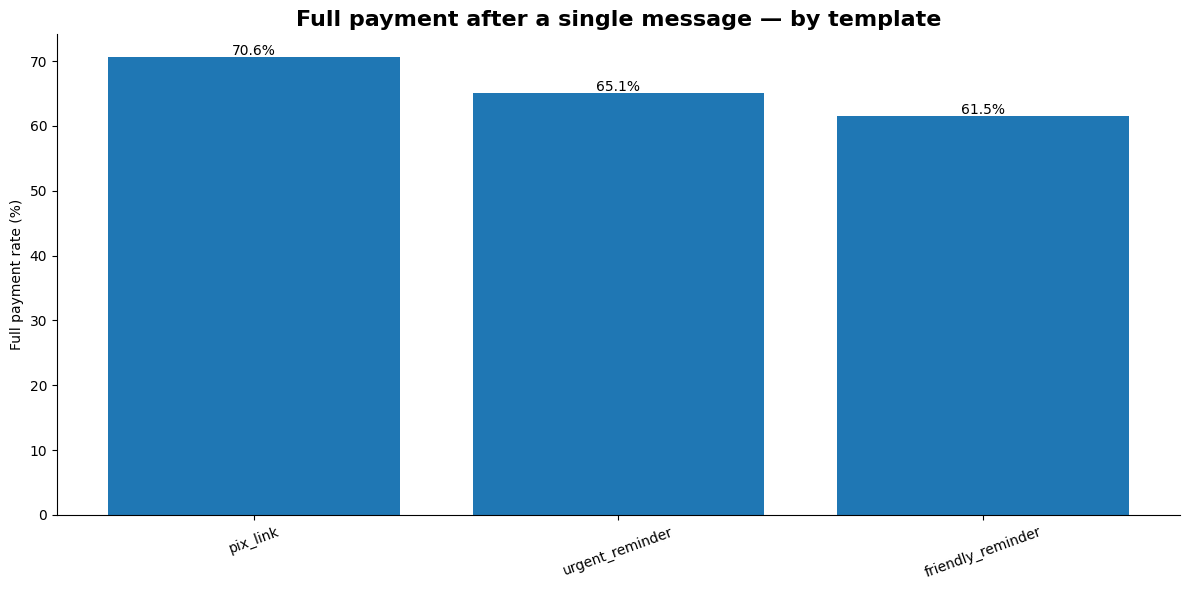

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    template_summary["template"].astype(str),
    template_summary["full_payment_rate"] * 100
)

ax.set_title(
    "Full payment after a single message — by template",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Full payment rate (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    template_summary["full_payment_rate"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + .3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# WEIGHTED BENCHMARK — ONE-TOUCH FULL PAYMENT
# ============================================================

tmp = template_summary.copy()

# Total de clientes
total_customers = tmp["customers"].sum()

# Peso de cada template na população
tmp["customer_weight"] = (
    tmp["customers"] / total_customers
)

# Taxa global ponderada
weighted_rate = (
    tmp["full_payment_rate"] *
    tmp["customer_weight"]
).sum()

# Diferença contra benchmark em pontos percentuais
tmp["vs_weighted_avg_pp"] = (
    tmp["full_payment_rate"] - weighted_rate
) * 100

# Índice relativo
# 100 = média da população
tmp["relative_index"] = (
    tmp["full_payment_rate"] /
    weighted_rate
) * 100

print(
    f"Weighted full-payment rate: "
    f"{weighted_rate:.2%}"
)

display(
    tmp[
        [
            "template",
            "customers",
            "full_payers",
            "customer_weight",
            "full_payment_rate",
            "vs_weighted_avg_pp",
            "relative_index"
        ]
    ].sort_values(
        "full_payment_rate",
        ascending=False
    )
)

Weighted full-payment rate: 64.54%


,template,customers,full_payers,customer_weight,full_payment_rate,vs_weighted_avg_pp,relative_index
1,pix_link,374,264,0.32,0.71,6.05,109.38
2,urgent_reminder,43,28,0.04,0.65,0.58,100.90
0,friendly_reminder,756,465,0.64,0.62,-3.03,95.31


In [22]:
# ============================================================
# CONFIDENCE INTERVAL — WILSON
# ============================================================

from statsmodels.stats.proportion import proportion_confint

tmp = template_summary.copy()

ci = tmp.apply(
    lambda r: proportion_confint(
        count=r["full_payers"],
        nobs=r["customers"],
        alpha=0.05,
        method="wilson"
    ),
    axis=1
)

tmp["ci_low"] = [x[0] for x in ci]
tmp["ci_high"] = [x[1] for x in ci]

tmp["ci_low_pct"] = tmp["ci_low"] * 100
tmp["ci_high_pct"] = tmp["ci_high"] * 100

display(
    tmp[
        [
            "template",
            "customers",
            "full_payers",
            "full_payment_rate",
            "ci_low_pct",
            "ci_high_pct"
        ]
    ]
)

,template,customers,full_payers,full_payment_rate,ci_low_pct,ci_high_pct
1,pix_link,374,264,0.71,65.78,74.98
2,urgent_reminder,43,28,0.65,50.17,77.58
0,friendly_reminder,756,465,0.62,57.99,64.91


In [23]:
import pandas as pd
import numpy as np

# ============================================================
# SINGLE-PAYMENT FULL PAYERS
# Objetivo:
# 1. Encontrar clientes que quitaram a dívida em UM pagamento
# 2. Contar quantas mensagens receberam ATÉ essa quitação
# 3. Separar 1 mensagem vs >1 mensagem
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "paid_within_72h"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. IDENTIFICAR PAGAMENTO INTEGRAL EM UMA ÚNICA LINHA
# ============================================================

TOL = 0.05

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (
        df["amount_paid_brl"].fillna(0)
        >=
        df["outstanding_balance_brl"].fillna(np.inf) - TOL
    )
).astype(int)


# ============================================================
# 2. PRIMEIRO EVENTO DE QUITAÇÃO INTEGRAL POR CLIENTE
# ============================================================

full_payment_event = (
    df.loc[df["is_single_full_payment"].eq(1)]
      .sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
      [
          [
              "customer_id",
              "sent_at",
              "amount_paid_brl",
              "outstanding_balance_brl"
          ]
      ]
      .rename(
          columns={
              "sent_at": "full_payment_at",
              "amount_paid_brl": "full_payment_amount",
              "outstanding_balance_brl": "balance_before_payment"
          }
      )
)

print(
    "Customers with single full payment:",
    f"{full_payment_event['customer_id'].nunique():,}"
)

Customers with single full payment: 3,275


In [24]:
# ============================================================
# 3. HISTÓRICO ATÉ A QUITAÇÃO
# ============================================================

hist = df.merge(
    full_payment_event[
        ["customer_id", "full_payment_at"]
    ],
    on="customer_id",
    how="inner"
)

hist_until_payment = hist.loc[
    hist["sent_at"] <= hist["full_payment_at"]
].copy()


# ============================================================
# 4. NÚMERO DE MENSAGENS ATÉ A QUITAÇÃO
# ============================================================

n_messages = (
    hist_until_payment
    .groupby("customer_id")
    .size()
    .rename("n_messages_until_full_payment")
    .reset_index()
)


full_payers = full_payment_event.merge(
    n_messages,
    on="customer_id",
    how="left"
)


# ============================================================
# 5. SEGMENTAÇÃO
# ============================================================

full_payers["message_segment"] = np.where(
    full_payers["n_messages_until_full_payment"].eq(1),
    "1 message",
    ">1 message"
)


# ============================================================
# 6. RESULTADO
# ============================================================

summary = (
    full_payers
    .groupby("message_segment")
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("full_payment_amount", "sum"),
        avg_balance=("balance_before_payment", "mean"),
        median_balance=("balance_before_payment", "median")
    )
    .reset_index()
)

summary["customer_share"] = (
    summary["customers"]
    /
    summary["customers"].sum()
)

summary["recovery_share"] = (
    summary["recovered_brl"]
    /
    summary["recovered_brl"].sum()
)

display(summary)

print("\n" + "=" * 70)
print("SINGLE-PAYMENT FULL PAYERS")
print("=" * 70)

print(
    f"Total full payers : "
    f"{full_payers['customer_id'].nunique():,}"
)

for _, row in summary.iterrows():

    print(
        f"{row['message_segment']:>12}: "
        f"{row['customers']:,.0f} customers "
        f"({row['customer_share']:.1%})"
    )

,message_segment,customers,recovered_brl,avg_balance,median_balance,customer_share,recovery_share
0,1 message,757,"606,176.06",800.76,675.57,0.23,0.24
1,>1 message,2518,"1,881,177.63",747.09,619.91,0.77,0.76



SINGLE-PAYMENT FULL PAYERS
Total full payers : 3,275
   1 message: 757 customers (23.1%)
  >1 message: 2,518 customers (76.9%)


FULL PAYERS — 1 MENSAGEM vs MAIS DE 1


,message_segment,customers,recovered_brl,avg_balance,median_balance,customer_share,recovery_share
0,1 mensagem,757,"606,176.06",800.76,675.57,0.23,0.24
1,>1 mensagem,2518,"1,881,177.63",747.09,619.91,0.77,0.76



DISTRIBUIÇÃO — MENSAGENS ATÉ QUITAÇÃO


,n_messages_until_full_payment,customers,recovered_brl,customer_share,cumulative_share
0,1,757,"606,176.06",0.23,0.23
1,2,584,"457,954.37",0.18,0.41
2,3,510,"363,689.74",0.16,0.57
3,4,419,"303,994.98",0.13,0.69
4,5,323,"224,167.87",0.10,0.79
5,6,218,"169,920.38",0.07,0.86
6,7,174,"141,100.24",0.05,0.91
7,8,103,"79,215.54",0.03,0.94
8,9,84,"67,221.63",0.03,0.97
9,10,49,"33,918.89",0.01,0.98



KPIs
Full payers           : 3,275
1 mensagem            : 757 (23.1%)
>1 mensagem           : 2,518 (76.9%)


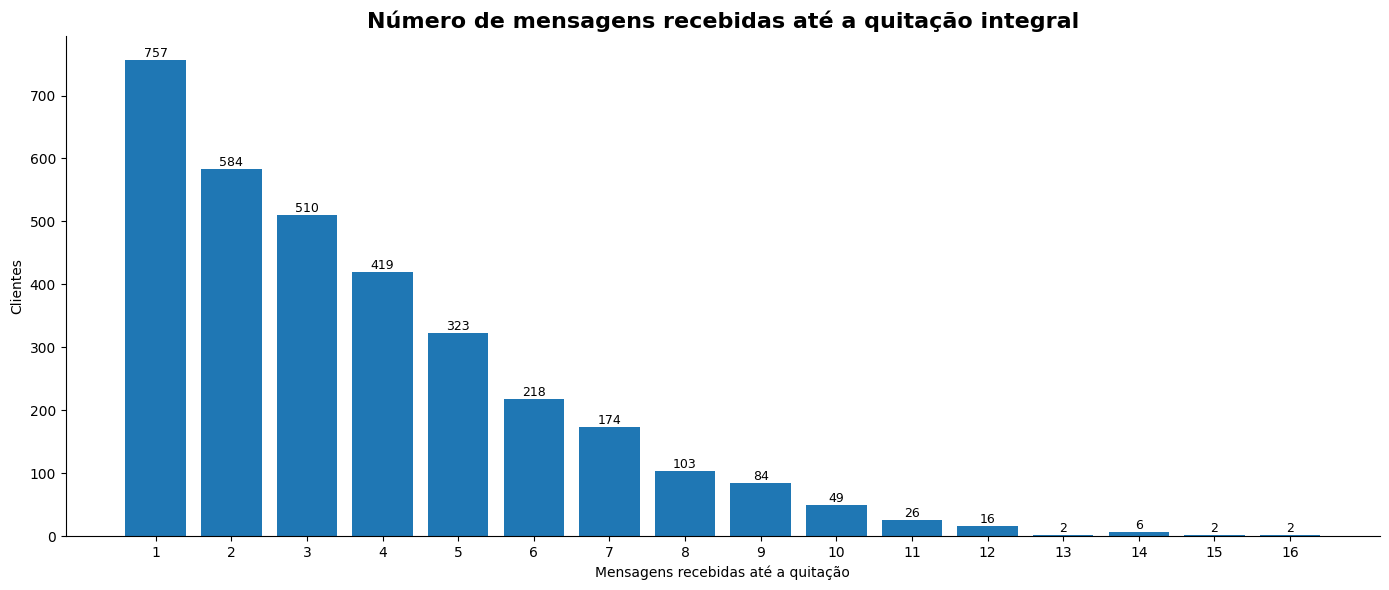

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SINGLE-PAYMENT FULL PAYERS
# Quantas mensagens receberam até a quitação?
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. IDENTIFICAR EVENTO DE QUITAÇÃO EM UM ÚNICO PAGAMENTO
# ============================================================

TOL = 0.05

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (
        df["amount_paid_brl"].fillna(0)
        >=
        df["outstanding_balance_brl"].fillna(np.inf) - TOL
    )
)


# ============================================================
# 2. PRIMEIRA QUITAÇÃO INTEGRAL DO CLIENTE
# ============================================================

full_payment_event = (
    df.loc[df["is_single_full_payment"]]
      .sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
      [
          [
              "customer_id",
              "sent_at",
              "amount_paid_brl",
              "outstanding_balance_brl"
          ]
      ]
      .rename(columns={
          "sent_at": "full_payment_at",
          "amount_paid_brl": "full_payment_amount",
          "outstanding_balance_brl": "balance_before_payment"
      })
)


# ============================================================
# 3. PEGAR HISTÓRICO DESSES CLIENTES
# ============================================================

hist = df.merge(
    full_payment_event[
        ["customer_id", "full_payment_at"]
    ],
    on="customer_id",
    how="inner"
)


# Somente mensagens até o evento associado à quitação
hist = hist.loc[
    hist["sent_at"] <= hist["full_payment_at"]
].copy()


# ============================================================
# 4. CONTAR MENSAGENS ATÉ QUITAÇÃO
# ============================================================

message_count = (
    hist
    .groupby("customer_id")
    .size()
    .rename("n_messages_until_full_payment")
    .reset_index()
)


full_payers = full_payment_event.merge(
    message_count,
    on="customer_id",
    how="left"
)


# ============================================================
# 5. SEGMENTAR: 1 MENSAGEM vs MAIS DE 1
# ============================================================

full_payers["message_segment"] = np.where(
    full_payers["n_messages_until_full_payment"].eq(1),
    "1 mensagem",
    ">1 mensagem"
)


summary = (
    full_payers
    .groupby("message_segment")
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("full_payment_amount", "sum"),
        avg_balance=("balance_before_payment", "mean"),
        median_balance=("balance_before_payment", "median")
    )
    .reset_index()
)

summary["customer_share"] = (
    summary["customers"]
    / summary["customers"].sum()
)

summary["recovery_share"] = (
    summary["recovered_brl"]
    / summary["recovered_brl"].sum()
)


print("=" * 90)
print("FULL PAYERS — 1 MENSAGEM vs MAIS DE 1")
print("=" * 90)

display(summary)


# ============================================================
# 6. DISTRIBUIÇÃO EXATA DE MENSAGENS
# ============================================================

message_distribution = (
    full_payers
    .groupby("n_messages_until_full_payment")
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("full_payment_amount", "sum")
    )
    .reset_index()
    .sort_values("n_messages_until_full_payment")
)

message_distribution["customer_share"] = (
    message_distribution["customers"]
    / message_distribution["customers"].sum()
)

message_distribution["cumulative_share"] = (
    message_distribution["customer_share"].cumsum()
)


print("\n" + "=" * 90)
print("DISTRIBUIÇÃO — MENSAGENS ATÉ QUITAÇÃO")
print("=" * 90)

display(message_distribution)


# ============================================================
# 7. KPIs
# ============================================================

total = len(full_payers)

one_msg = (
    full_payers["n_messages_until_full_payment"]
    .eq(1)
    .sum()
)

more_than_one = (
    full_payers["n_messages_until_full_payment"]
    .gt(1)
    .sum()
)

print("\n" + "=" * 90)
print("KPIs")
print("=" * 90)

print(f"Full payers           : {total:,}")
print(
    f"1 mensagem            : {one_msg:,} "
    f"({one_msg/total:.1%})"
)
print(
    f">1 mensagem           : {more_than_one:,} "
    f"({more_than_one/total:.1%})"
)


# ============================================================
# 8. GRÁFICO — DISTRIBUIÇÃO EXATA
# ============================================================

plot = message_distribution.copy()

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    plot["n_messages_until_full_payment"].astype(str),
    plot["customers"]
)

ax.set_title(
    "Número de mensagens recebidas até a quitação integral",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Mensagens recebidas até a quitação")
ax.set_ylabel("Clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, n in zip(
    bars,
    plot["customers"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{n:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# AUDIT — QUAL MENSAGEM ESTÁ ASSOCIADA AO SINGLE FULL PAYMENT?
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. IDENTIFICAR A LINHA QUE REPRESENTA QUITAÇÃO INTEGRAL
# ============================================================

TOL = 0.05

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (
        df["amount_paid_brl"].fillna(0)
        >=
        df["outstanding_balance_brl"].fillna(np.inf) - TOL
    )
)


# ============================================================
# 2. TODAS AS LINHAS ASSOCIADAS A FULL PAYMENT
# ============================================================

payment_events = (
    df.loc[df["is_single_full_payment"]]
      .copy()
)

print("=" * 90)
print("SINGLE FULL PAYMENT EVENTS")
print("=" * 90)

print(
    f"Rows              : {len(payment_events):,}"
)

print(
    f"Unique customers  : "
    f"{payment_events['customer_id'].nunique():,}"
)

SINGLE FULL PAYMENT EVENTS
Rows              : 3,275
Unique customers  : 3,275


In [27]:
# ============================================================
# 3. QA — QUANTOS EVENTOS DE FULL PAYMENT POR CLIENTE?
# ============================================================

events_per_customer = (
    payment_events
    .groupby("customer_id")
    .size()
    .rename("n_full_payment_events")
    .reset_index()
)

print("\n" + "=" * 90)
print("FULL PAYMENT EVENTS PER CUSTOMER")
print("=" * 90)

display(
    events_per_customer[
        "n_full_payment_events"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("n_full_payment_events")
    .reset_index(name="customers")
)


# Clientes problemáticos
multiple_events = events_per_customer.loc[
    events_per_customer["n_full_payment_events"] > 1
]

print(
    f"\nCustomers with >1 full-payment event: "
    f"{len(multiple_events):,}"
)


FULL PAYMENT EVENTS PER CUSTOMER


,n_full_payment_events,customers
0,1,3275



Customers with >1 full-payment event: 0


In [28]:
# ============================================================
# 4. MENSAGEM ASSOCIADA AO FULL PAYMENT
# ============================================================

payment_message = (
    payment_events
    [
        [
            "customer_id",
            "sent_at",
            "template",
            "delivery_status",
            "interaction",
            "days_past_due",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .copy()
)

payment_message = payment_message.rename(
    columns={
        "sent_at": "payment_associated_message_at",
        "template": "payment_associated_template",
        "delivery_status": "payment_associated_delivery_status",
        "interaction": "payment_associated_interaction",
        "days_past_due": "payment_associated_dpd",
        "outstanding_balance_brl": "balance_before_payment",
        "amount_paid_brl": "single_payment_brl"
    }
)

display(payment_message.head(20))

,customer_id,payment_associated_message_at,payment_associated_template,payment_associated_delivery_status,payment_associated_interaction,payment_associated_dpd,balance_before_payment,single_payment_brl
40346,C000001,2026-07-29 09:14:00,urgent_reminder,delivered,none,26,934.58,934.58
22661,C000004,2026-07-10 10:57:00,urgent_reminder,delivered,none,11,"1,331.09","1,331.09"
49395,C000009,2026-08-06 10:58:00,pix_link,delivered,none,56,878.15,878.15
32669,C000012,2026-07-21 12:28:00,friendly_reminder,delivered,none,18,320.23,320.23
14991,C000013,2026-07-01 12:58:00,pix_link,delivered,replied,9,798.50,798.50
2389,C000019,2026-06-11 13:38:00,pix_link,delivered,clicked_link,3,836.08,836.08
18405,C000020,2026-07-06 10:27:00,urgent_reminder,delivered,clicked_link,8,593.48,593.48
64258,C000021,2026-08-20 14:55:00,friendly_reminder,delivered,none,1,981.61,981.61
15004,C000030,2026-07-01 13:13:00,friendly_reminder,delivered,read,2,401.69,401.69
10313,C000031,2026-06-25 11:12:00,pix_link,delivered,clicked_link,3,411.12,411.12


In [29]:
# ============================================================
# 5. BALANCE RECONCILIATION
# ============================================================

payment_message["payment_balance_gap"] = (
    payment_message["single_payment_brl"]
    -
    payment_message["balance_before_payment"]
)

payment_message["payment_balance_gap_abs"] = (
    payment_message["payment_balance_gap"].abs()
)

print("=" * 90)
print("PAYMENT × BALANCE RECONCILIATION")
print("=" * 90)

print(
    payment_message["payment_balance_gap"]
    .describe(
        percentiles=[.01, .05, .50, .95, .99]
    )
)

print()

print(
    "Exact / within R$0.05:",
    (
        payment_message["payment_balance_gap_abs"]
        <= 0.05
    ).mean()
)

print(
    "Within R$1:",
    (
        payment_message["payment_balance_gap_abs"]
        <= 1
    ).mean()
)

PAYMENT × BALANCE RECONCILIATION
count   3,275.00
mean        0.00
std         0.00
min         0.00
1%          0.00
5%          0.00
50%         0.00
95%         0.00
99%         0.00
max         0.00
Name: payment_balance_gap, dtype: float64

Exact / within R$0.05: 1.0
Within R$1: 1.0


In [30]:
# ============================================================
# 6. TEMPLATE ASSOCIATED WITH SINGLE FULL PAYMENT
# ============================================================

template_payment = (
    payment_message
    .groupby("payment_associated_template")
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("single_payment_brl", "sum"),
        avg_payment=("single_payment_brl", "mean"),
        median_payment=("single_payment_brl", "median")
    )
    .reset_index()
)

template_payment["customer_share"] = (
    template_payment["customers"]
    /
    template_payment["customers"].sum()
)

template_payment["recovery_share"] = (
    template_payment["recovered_brl"]
    /
    template_payment["recovered_brl"].sum()
)

template_payment = template_payment.sort_values(
    "customers",
    ascending=False
)

display(template_payment)

,payment_associated_template,customers,recovered_brl,avg_payment,median_payment,customer_share,recovery_share
0,friendly_reminder,1193,"944,072.57",791.34,675.57,0.36,0.38
1,pix_link,1157,"870,328.60",752.23,623.71,0.35,0.35
2,urgent_reminder,925,"672,952.52",727.52,598.71,0.28,0.27


In [31]:
# ============================================================
# 7. MESSAGE NUMBER ASSOCIATED WITH FULL PAYMENT
# ============================================================

df["message_number"] = (
    df.groupby("customer_id")
      .cumcount()
      .add(1)
)

payment_position = (
    df.loc[df["is_single_full_payment"]]
      [
          [
              "customer_id",
              "message_number",
              "sent_at",
              "template",
              "days_past_due",
              "outstanding_balance_brl",
              "amount_paid_brl"
          ]
      ]
      .copy()
)

position_summary = (
    payment_position
    .groupby("message_number")
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
    .sort_values("message_number")
)

position_summary["customer_share"] = (
    position_summary["customers"]
    /
    position_summary["customers"].sum()
)

position_summary["cumulative_share"] = (
    position_summary["customer_share"]
    .cumsum()
)

display(position_summary)

,message_number,customers,recovered_brl,customer_share,cumulative_share
0,1,757,"606,176.06",0.23,0.23
1,2,584,"457,954.37",0.18,0.41
2,3,510,"363,689.74",0.16,0.57
3,4,419,"303,994.98",0.13,0.69
4,5,323,"224,167.87",0.10,0.79
5,6,218,"169,920.38",0.07,0.86
6,7,174,"141,100.24",0.05,0.91
7,8,103,"79,215.54",0.03,0.94
8,9,84,"67,221.63",0.03,0.97
9,10,49,"33,918.89",0.01,0.98


In [32]:
import pandas as pd
import numpy as np

# ============================================================
# AUDIT 01
# QUAL MENSAGEM ESTÁ ASSOCIADA À QUITAÇÃO EM PAGAMENTO ÚNICO?
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. LINHAS COM PAGAMENTO
# ============================================================

payments = df.loc[
    df["amount_paid_brl"].fillna(0) > 0
].copy()

print("=" * 90)
print("PAYMENT EVENTS")
print("=" * 90)

print(f"Payment rows      : {len(payments):,}")
print(f"Paying customers  : {payments['customer_id'].nunique():,}")

PAYMENT EVENTS
Payment rows      : 5,626
Paying customers  : 4,893


In [33]:
# ============================================================
# 2. IDENTIFICAR SINGLE FULL PAYMENT
# ============================================================

TOL = 0.05

payments["payment_balance_gap"] = (
    payments["amount_paid_brl"]
    -
    payments["outstanding_balance_brl"]
)

payments["is_single_full_payment"] = (
    payments["payment_balance_gap"] >= -TOL
)


single_full_payment = payments.loc[
    payments["is_single_full_payment"]
].copy()


print("\n" + "=" * 90)
print("SINGLE FULL PAYMENT")
print("=" * 90)

print(f"Rows       : {len(single_full_payment):,}")
print(
    f"Customers  : "
    f"{single_full_payment['customer_id'].nunique():,}"
)


SINGLE FULL PAYMENT
Rows       : 3,275
Customers  : 3,275


In [34]:
# ============================================================
# 3. MENSAGEM ASSOCIADA À QUITAÇÃO
# ============================================================

cols = [
    "customer_id",
    "sent_at",
    "template",
    "delivery_status",
    "interaction",
    "days_past_due",
    "outstanding_balance_brl",
    "amount_paid_brl",
    "payment_balance_gap"
]

payment_message = (
    single_full_payment[
        [c for c in cols if c in single_full_payment.columns]
    ]
    .sort_values(["customer_id", "sent_at"])
    .copy()
)

display(
    payment_message.head(30)
)

,customer_id,sent_at,template,delivery_status,interaction,days_past_due,outstanding_balance_brl,amount_paid_brl,payment_balance_gap
40346,C000001,2026-07-29 09:14:00,urgent_reminder,delivered,none,26,934.58,934.58,0.00
22661,C000004,2026-07-10 10:57:00,urgent_reminder,delivered,none,11,"1,331.09","1,331.09",0.00
49395,C000009,2026-08-06 10:58:00,pix_link,delivered,none,56,878.15,878.15,0.00
32669,C000012,2026-07-21 12:28:00,friendly_reminder,delivered,none,18,320.23,320.23,0.00
14991,C000013,2026-07-01 12:58:00,pix_link,delivered,replied,9,798.50,798.50,0.00
2389,C000019,2026-06-11 13:38:00,pix_link,delivered,clicked_link,3,836.08,836.08,0.00
18405,C000020,2026-07-06 10:27:00,urgent_reminder,delivered,clicked_link,8,593.48,593.48,0.00
64258,C000021,2026-08-20 14:55:00,friendly_reminder,delivered,none,1,981.61,981.61,0.00
15004,C000030,2026-07-01 13:13:00,friendly_reminder,delivered,read,2,401.69,401.69,0.00
10313,C000031,2026-06-25 11:12:00,pix_link,delivered,clicked_link,3,411.12,411.12,0.00


In [35]:
# ============================================================
# 4. QA — QUANTAS MENSAGENS COM SINGLE FULL PAYMENT
# EXISTEM POR CLIENTE?
# ============================================================

audit_customer = (
    single_full_payment
    .groupby("customer_id")
    .agg(
        n_single_full_payment_events=(
            "is_single_full_payment",
            "size"
        ),
        total_paid=(
            "amount_paid_brl",
            "sum"
        )
    )
    .reset_index()
)

event_distribution = (
    audit_customer[
        "n_single_full_payment_events"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "n_single_full_payment_events"
    )
    .reset_index(
        name="customers"
    )
)

display(event_distribution)

,n_single_full_payment_events,customers
0,1,3275


In [36]:
# ============================================================
# 5. TEMPLATE DA MENSAGEM ASSOCIADA AO PAGAMENTO
# ============================================================

template_audit = (
    single_full_payment
    .groupby("template")
    .agg(
        customers=("customer_id", "nunique"),
        payment_events=("customer_id", "size"),
        recovered_brl=("amount_paid_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean"),
        median_balance=("outstanding_balance_brl", "median")
    )
    .reset_index()
)

template_audit["customer_share"] = (
    template_audit["customers"]
    /
    single_full_payment["customer_id"].nunique()
)

template_audit = template_audit.sort_values(
    "customers",
    ascending=False
)

display(template_audit)

,template,customers,payment_events,recovered_brl,avg_balance,median_balance,customer_share
0,friendly_reminder,1193,1193,"944,072.57",791.34,675.57,0.36
1,pix_link,1157,1157,"870,328.60",752.23,623.71,0.35
2,urgent_reminder,925,925,"672,952.52",727.52,598.71,0.28


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONTEXTO DA MENSAGEM ASSOCIADA À QUITAÇÃO INTEGRAL
# ============================================================

pay = payment_position.copy()

# Precisamos recuperar payday e outras informações da linha original
extra_cols = [
    "customer_id",
    "sent_at",
    "payday_day_of_month"
]

extra = (
    df[extra_cols]
    .drop_duplicates(
        subset=["customer_id", "sent_at"]
    )
)

pay = pay.merge(
    extra,
    on=["customer_id", "sent_at"],
    how="left"
)

# ============================================================
# QA
# ============================================================

print("=" * 90)
print("PAYMENT-ASSOCIATED MESSAGE — CONTEXT")
print("=" * 90)

print(f"Rows      : {len(pay):,}")
print(f"Customers : {pay['customer_id'].nunique():,}")

print(
    f"Payday available: "
    f"{pay['payday_day_of_month'].notna().mean():.1%}"
)

PAYMENT-ASSOCIATED MESSAGE — CONTEXT
Rows      : 3,275
Customers : 3,275
Payday available: 100.0%


In [38]:
# ============================================================
# DAY OF MONTH
# ============================================================

pay["day_of_month"] = pay["sent_at"].dt.day

day_summary = (
    pay.groupby("day_of_month")
       .agg(
           customers=("customer_id", "nunique"),
           recovered_brl=("amount_paid_brl", "sum")
       )
       .reset_index()
       .sort_values("day_of_month")
)

day_summary["customer_share"] = (
    day_summary["customers"]
    / day_summary["customers"].sum()
)

display(day_summary)

,day_of_month,customers,recovered_brl,customer_share
0,1,72,"54,292.74",0.02
1,2,60,"56,465.47",0.02
2,3,93,"65,200.74",0.03
3,4,77,"59,489.13",0.02
4,5,90,"65,288.66",0.03
5,6,115,"85,416.13",0.04
6,7,133,"95,315.58",0.04
7,8,88,"70,342.39",0.03
8,9,77,"61,711.74",0.02
9,10,139,"103,487.78",0.04


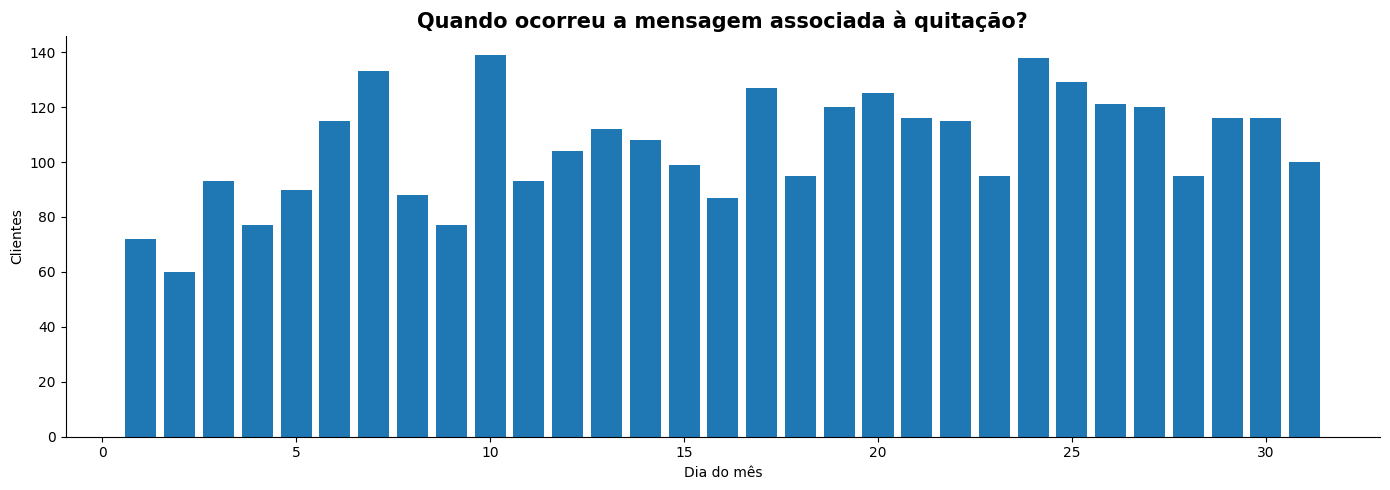

In [39]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    day_summary["day_of_month"],
    day_summary["customers"]
)

ax.set_title(
    "Quando ocorreu a mensagem associada à quitação?",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Dia do mês")
ax.set_ylabel("Clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# DPD
# ============================================================

pay["dpd_bucket"] = pd.cut(
    pay["days_past_due"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

dpd_summary = (
    pay.groupby(
        "dpd_bucket",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("amount_paid_brl", "sum"),
        avg_payment=("amount_paid_brl", "mean"),
        median_payment=("amount_paid_brl", "median")
    )
    .reset_index()
)

dpd_summary["customer_share"] = (
    dpd_summary["customers"]
    / dpd_summary["customers"].sum()
)

dpd_summary["recovery_share"] = (
    dpd_summary["recovered_brl"]
    / dpd_summary["recovered_brl"].sum()
)

display(dpd_summary)

,dpd_bucket,customers,recovered_brl,avg_payment,median_payment,customer_share,recovery_share
0,01–07,1357,"1,089,254.52",802.69,679.82,0.41,0.44
1,08–15,1046,"773,056.45",739.06,597.48,0.32,0.31
2,16–30,683,"483,855.49",708.43,593.86,0.21,0.19
3,31–45,123,"91,045.41",740.21,624.93,0.04,0.04
4,46–60,66,"50,141.82",759.72,731.96,0.02,0.02


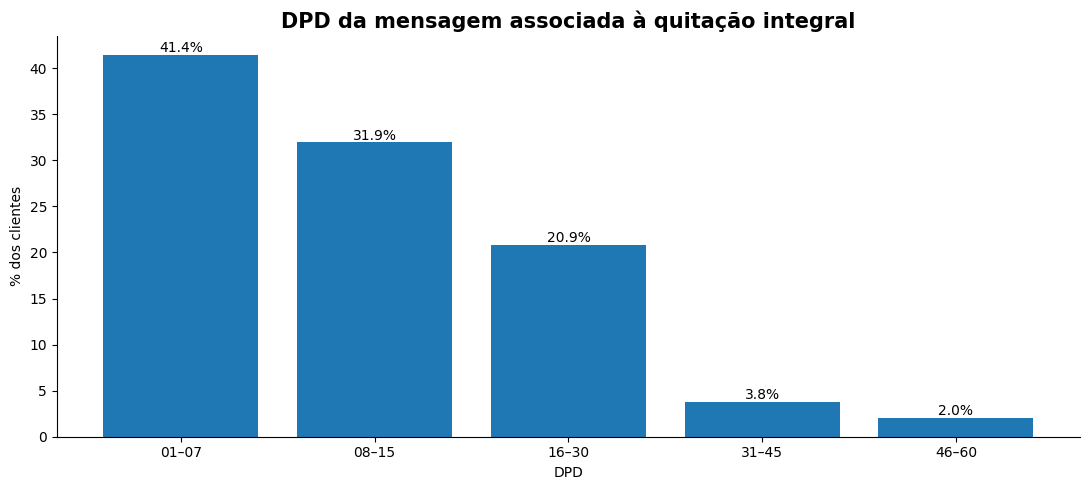

In [41]:
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    dpd_summary["dpd_bucket"].astype(str),
    dpd_summary["customer_share"] * 100
)

ax.set_title(
    "DPD da mensagem associada à quitação integral",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("DPD")
ax.set_ylabel("% dos clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    dpd_summary["customer_share"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + .3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# HOUR
# ============================================================

pay["hour"] = pay["sent_at"].dt.hour

hour_summary = (
    pay.groupby("hour")
       .agg(
           customers=("customer_id", "nunique"),
           recovered_brl=("amount_paid_brl", "sum")
       )
       .reset_index()
       .sort_values("hour")
)

hour_summary["customer_share"] = (
    hour_summary["customers"]
    / hour_summary["customers"].sum()
)

display(hour_summary)

,hour,customers,recovered_brl,customer_share
0,9,425,"333,577.56",0.13
1,10,437,"324,304.99",0.13
2,11,465,"345,053.96",0.14
3,12,347,"263,474.44",0.11
4,13,253,"176,618.50",0.08
5,14,192,"156,692.01",0.06
6,15,213,"157,371.33",0.07
7,16,223,"163,824.63",0.07
8,17,241,"197,440.50",0.07
9,18,175,"130,891.92",0.05


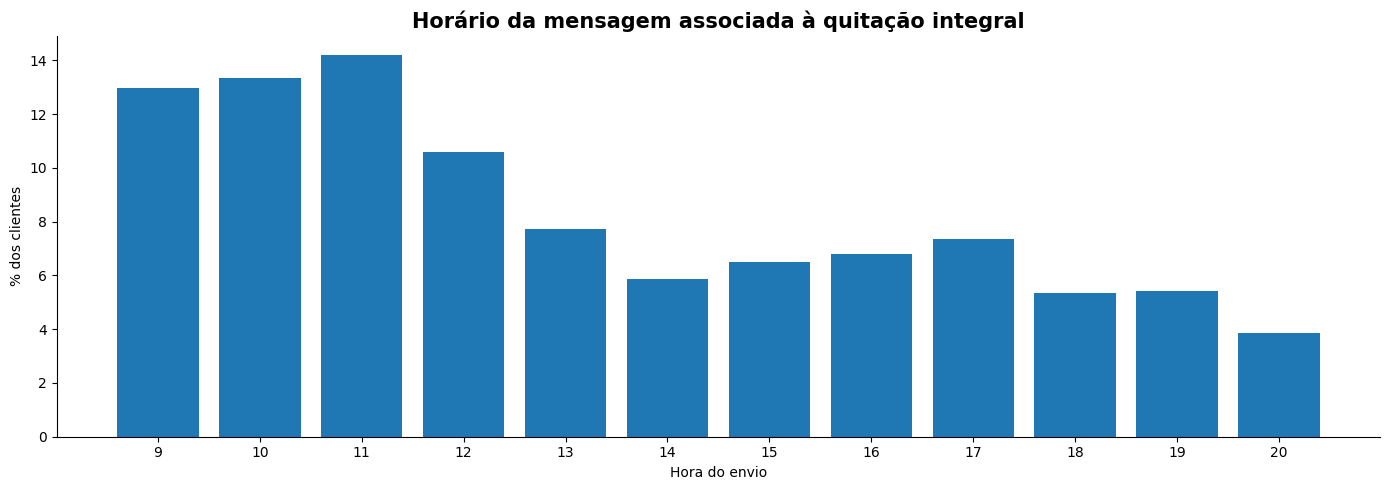

In [43]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    hour_summary["hour"],
    hour_summary["customer_share"] * 100
)

ax.set_title(
    "Horário da mensagem associada à quitação integral",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Hora do envio")
ax.set_ylabel("% dos clientes")

ax.set_xticks(hour_summary["hour"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# DISTANCE TO NEAREST PAYDAY
# ============================================================

def nearest_payday_distance(row):

    sent = row["sent_at"]
    payday = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday):
        return np.nan

    payday = int(payday)

    candidates = []

    # mês anterior, atual e seguinte
    for offset in [-1, 0, 1]:

        month_ref = (
            sent.to_period("M") + offset
        )

        year = month_ref.year
        month = month_ref.month

        # Último dia do mês
        last_day = pd.Period(
            f"{year}-{month:02d}"
        ).days_in_month

        valid_day = min(
            payday,
            last_day
        )

        candidate = pd.Timestamp(
            year=year,
            month=month,
            day=valid_day
        )

        candidates.append(candidate)

    nearest = min(
        candidates,
        key=lambda x: abs((sent.normalize() - x).days)
    )

    # negativo = mensagem ANTES do payday
    # positivo = mensagem DEPOIS do payday
    return (
        sent.normalize() - nearest
    ).days


pay["days_from_nearest_payday"] = (
    pay.apply(
        nearest_payday_distance,
        axis=1
    )
)

In [45]:
payday_summary = (
    pay.dropna(
        subset=["days_from_nearest_payday"]
    )
    .groupby("days_from_nearest_payday")
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
    .sort_values("days_from_nearest_payday")
)

payday_summary["customer_share"] = (
    payday_summary["customers"]
    / payday_summary["customers"].sum()
)

display(payday_summary)

,days_from_nearest_payday,customers,recovered_brl,customer_share
0,-15,77,"60,521.81",0.02
1,-14,106,"80,753.16",0.03
2,-13,95,"72,012.47",0.03
3,-12,106,"80,209.05",0.03
4,-11,98,"73,681.04",0.03
5,-10,97,"78,087.97",0.03
6,-9,101,"68,177.31",0.03
7,-8,121,"95,608.16",0.04
8,-7,89,"69,804.41",0.03
9,-6,112,"88,262.91",0.03


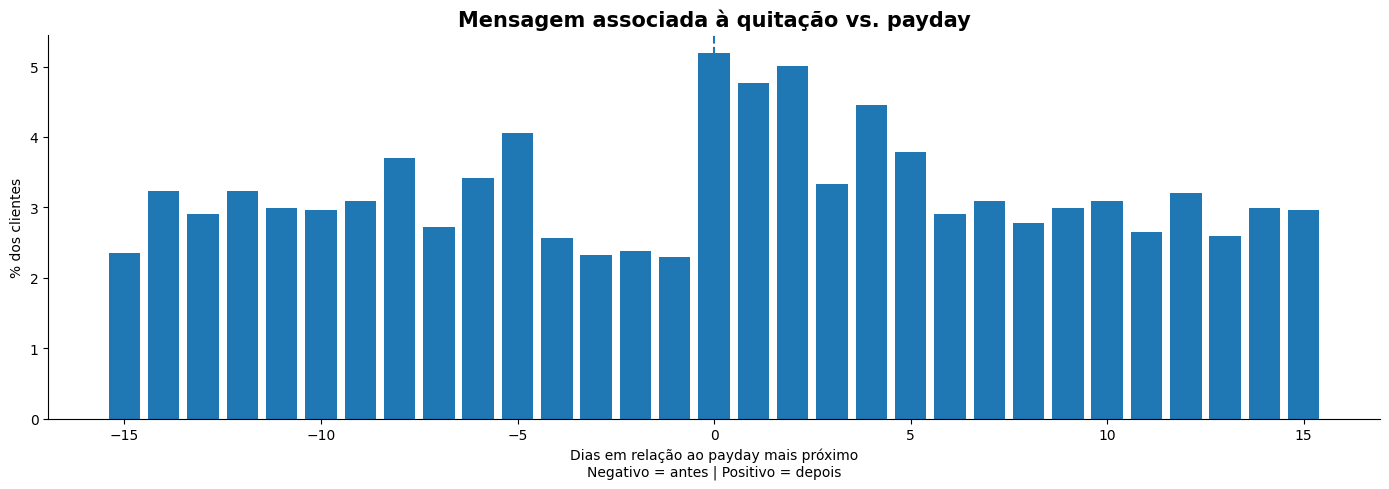

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    payday_summary["days_from_nearest_payday"],
    payday_summary["customer_share"] * 100
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Mensagem associada à quitação vs. payday",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Dias em relação ao payday mais próximo\n"
    "Negativo = antes | Positivo = depois"
)

ax.set_ylabel("% dos clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# PAYDAY BUCKETS
# ============================================================

pay["payday_bucket"] = pd.cut(
    pay["days_from_nearest_payday"],
    bins=[
        -np.inf,
        -8,
        -4,
        -1,
        0,
        3,
        7,
        np.inf
    ],
    labels=[
        "≤ -8d",
        "-7 a -4d",
        "-3 a -1d",
        "Payday",
        "+1 a +3d",
        "+4 a +7d",
        "≥ +8d"
    ]
)

payday_bucket_summary = (
    pay.groupby(
        "payday_bucket",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        recovered_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

payday_bucket_summary["customer_share"] = (
    payday_bucket_summary["customers"]
    / payday_bucket_summary["customers"].sum()
)

display(payday_bucket_summary)

,payday_bucket,customers,recovered_brl,customer_share
0,≤ -8d,801,"609,050.97",0.24
1,-7 a -4d,418,"333,527.86",0.13
2,-3 a -1d,229,"170,805.30",0.07
3,Payday,170,"125,134.06",0.05
4,+1 a +3d,429,"337,882.11",0.13
5,+4 a +7d,466,"338,647.88",0.14
6,≥ +8d,762,"572,305.51",0.23


In [48]:
# ============================================================
# WEEKDAY
# ============================================================

weekday_map = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

weekday_order = [
    "Seg",
    "Ter",
    "Qua",
    "Qui",
    "Sex",
    "Sáb",
    "Dom"
]

pay["weekday"] = (
    pay["sent_at"]
    .dt.dayofweek
    .map(weekday_map)
)

weekday_summary = (
    pay.groupby("weekday")
       .agg(
           customers=("customer_id", "nunique"),
           recovered_brl=("amount_paid_brl", "sum")
       )
       .reset_index()
)

weekday_summary["weekday"] = pd.Categorical(
    weekday_summary["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_summary = (
    weekday_summary
    .sort_values("weekday")
)

weekday_summary["customer_share"] = (
    weekday_summary["customers"]
    / weekday_summary["customers"].sum()
)

display(weekday_summary)


,weekday,customers,recovered_brl,customer_share
3,Seg,607,"457,823.18",0.19
6,Ter,575,"426,294.54",0.18
1,Qua,559,"427,664.31",0.17
2,Qui,533,"415,623.99",0.16
4,Sex,585,"440,265.53",0.18
5,Sáb,255,"190,493.95",0.08
0,Dom,161,"129,188.19",0.05


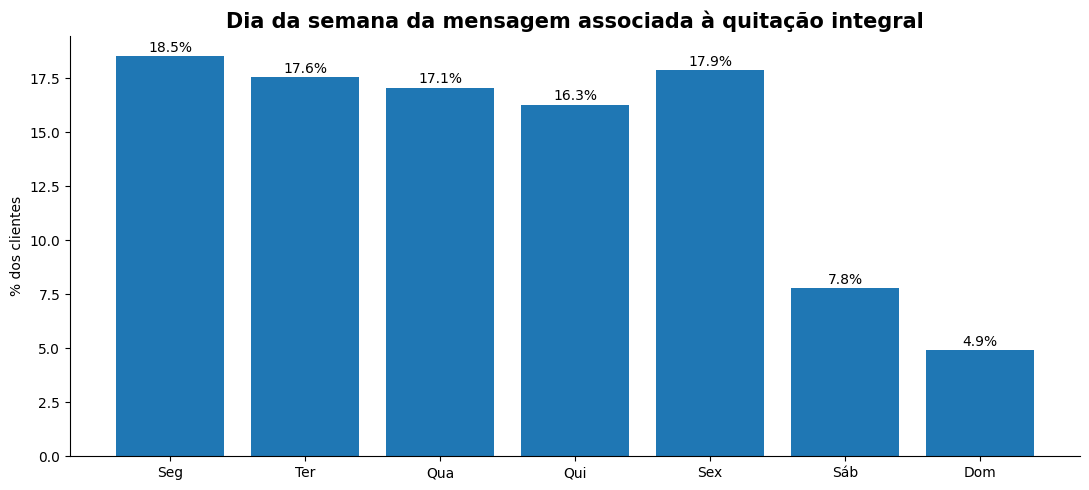

In [49]:
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    weekday_summary["weekday"].astype(str),
    weekday_summary["customer_share"] * 100
)

ax.set_title(
    "Dia da semana da mensagem associada à quitação integral",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("% dos clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    weekday_summary["customer_share"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + .2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import numpy as np

# ============================================================
# SINGLE FULL PAYERS — BASE CANÔNICA
#
# 1 linha por cliente
#
# Denominador econômico:
#   primeiro saldo observado do cliente
#
# Contexto:
#   mensagem associada à quitação
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due",
    "payday_day_of_month"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. PRIMEIRO SALDO OBSERVADO DE CADA CLIENTE
# ============================================================

first_state = (
    df
    .groupby("customer_id", as_index=False)
    .first()
    [
        [
            "customer_id",
            "sent_at",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "first_observed_at",

            "outstanding_balance_brl":
                "initial_balance_brl"
        }
    )
)


# ============================================================
# 2. IDENTIFICAR SINGLE FULL PAYMENT
# ============================================================

TOL = 0.05

df["payment_balance_gap"] = (
    df["amount_paid_brl"].fillna(0)
    -
    df["outstanding_balance_brl"]
)

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (df["payment_balance_gap"] >= -TOL)
)


# ============================================================
# 3. MENSAGEM ASSOCIADA À QUITAÇÃO
# ============================================================

single_full = (
    df.loc[
        df["is_single_full_payment"],
        [
            "customer_id",
            "sent_at",
            "template",
            "days_past_due",
            "payday_day_of_month",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .copy()
)

single_full = single_full.rename(
    columns={
        "sent_at":
            "payment_message_at",

        "outstanding_balance_brl":
            "balance_at_payment_message",

        "amount_paid_brl":
            "single_full_recovery_brl"
    }
)


# ============================================================
# 4. MERGE COM PRIMEIRO SALDO
# ============================================================

single_full = single_full.merge(
    first_state,
    on="customer_id",
    how="left"
)


# ============================================================
# QA
# ============================================================

print("=" * 90)
print("SINGLE FULL PAYERS — CANONICAL BASE")
print("=" * 90)

print(
    f"Rows                 : {len(single_full):,}"
)

print(
    f"Customers            : "
    f"{single_full['customer_id'].nunique():,}"
)

print(
    f"Initial balance      : "
    f"R$ {single_full['initial_balance_brl'].sum():,.2f}"
)

print(
    f"Single full recovery : "
    f"R$ {single_full['single_full_recovery_brl'].sum():,.2f}"
)

SINGLE FULL PAYERS — CANONICAL BASE
Rows                 : 3,275
Customers            : 3,275
Initial balance      : R$ 2,652,705.56
Single full recovery : R$ 2,487,353.69


In [51]:
# ============================================================
# CONTEXTO DA MENSAGEM ASSOCIADA À QUITAÇÃO
# ============================================================

single_full["payment_day_of_month"] = (
    single_full["payment_message_at"].dt.day
)

single_full["payment_hour"] = (
    single_full["payment_message_at"].dt.hour
)

weekday_map = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

single_full["payment_weekday"] = (
    single_full["payment_message_at"]
    .dt.dayofweek
    .map(weekday_map)
)


# DPD
single_full["dpd_bucket"] = pd.cut(
    single_full["days_past_due"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

In [52]:
# ============================================================
# CONTEXTO DA MENSAGEM ASSOCIADA À QUITAÇÃO
# ============================================================

single_full["payment_day_of_month"] = (
    single_full["payment_message_at"].dt.day
)

single_full["payment_hour"] = (
    single_full["payment_message_at"].dt.hour
)

weekday_map = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

single_full["payment_weekday"] = (
    single_full["payment_message_at"]
    .dt.dayofweek
    .map(weekday_map)
)


# DPD
single_full["dpd_bucket"] = pd.cut(
    single_full["days_past_due"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

In [53]:
import pandas as pd
import numpy as np

# ============================================================
# BASE ECONÔMICA — SINGLE FULL PAYMENT
#
# Denominador:
#   primeiro saldo observado de CADA cliente
#
# Numerador:
#   valor recuperado via single full payment
#
# Grão final:
#   1 linha por cliente
# ============================================================

df = wa.copy()

# ------------------------------------------------------------
# 0. TIPOS
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due",
    "payday_day_of_month"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. PRIMEIRO ESTADO OBSERVADO DE CADA CLIENTE
# ============================================================

first_customer_state = (
    df
    .sort_values(["customer_id", "sent_at"])
    .groupby(
        "customer_id",
        as_index=False
    )
    .first()
    [
        [
            "customer_id",
            "sent_at",
            "days_past_due",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "first_observed_at",

            "days_past_due":
                "initial_dpd",

            "outstanding_balance_brl":
                "initial_balance_brl"
        }
    )
)


# ============================================================
# 2. IDENTIFICAR SINGLE FULL PAYMENT
# ============================================================

TOL = 0.05

df["payment_balance_gap"] = (
    df["amount_paid_brl"].fillna(0)
    -
    df["outstanding_balance_brl"]
)

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (df["payment_balance_gap"] >= -TOL)
)


# ============================================================
# 3. EVENTO/MENSAGEM ASSOCIADA À QUITAÇÃO
# ============================================================

single_full = (
    df.loc[
        df["is_single_full_payment"],
        [
            "customer_id",
            "sent_at",
            "template",
            "days_past_due",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .copy()
    .rename(
        columns={
            "sent_at":
                "payment_message_at",

            "days_past_due":
                "payment_dpd",

            "outstanding_balance_brl":
                "balance_at_payment_message",

            "amount_paid_brl":
                "single_full_recovery_brl"
        }
    )
)


# ============================================================
# 4. QA — PRECISAMOS CONTINUAR COM OS MESMOS 3.275
# ============================================================

print("=" * 90)
print("SINGLE FULL PAYMENT — QA")
print("=" * 90)

print(
    f"Payment events : {len(single_full):,}"
)

print(
    f"Customers      : "
    f"{single_full['customer_id'].nunique():,}"
)

print(
    f"Recovered      : "
    f"R$ {single_full['single_full_recovery_brl'].sum():,.2f}"
)


# ============================================================
# 5. GARANTIR 1 EVENTO POR CLIENTE
# ============================================================

events_per_customer = (
    single_full
    .groupby("customer_id")
    .size()
)

print("\nEvents per customer:")
print(events_per_customer.value_counts().sort_index())


# ============================================================
# 6. ANEXAR OUTCOME À POPULAÇÃO TOTAL
# ============================================================

outcome = (
    single_full[
        [
            "customer_id",
            "single_full_recovery_brl",
            "payment_message_at",
            "payment_dpd",
            "template"
        ]
    ]
    .copy()
)

analysis = first_customer_state.merge(
    outcome,
    on="customer_id",
    how="left"
)

analysis["single_full_recovery_brl"] = (
    analysis["single_full_recovery_brl"]
    .fillna(0)
)

analysis["is_single_full_payer"] = (
    analysis["single_full_recovery_brl"] > 0
)


# ============================================================
# 7. QA DA BASE FINAL
# ============================================================

print("\n" + "=" * 90)
print("FINAL CUSTOMER-LEVEL BASE")
print("=" * 90)

print(
    f"Customers total       : "
    f"{analysis['customer_id'].nunique():,}"
)

print(
    f"Rows                  : "
    f"{len(analysis):,}"
)

print(
    f"Initial open balance  : "
    f"R$ {analysis['initial_balance_brl'].sum():,.2f}"
)

print(
    f"Single full payers    : "
    f"{analysis['is_single_full_payer'].sum():,}"
)

print(
    f"Single full recovery  : "
    f"R$ {analysis['single_full_recovery_brl'].sum():,.2f}"
)

print(
    f"Overall recovery rate : "
    f"{analysis['single_full_recovery_brl'].sum() / analysis['initial_balance_brl'].sum():.2%}"
)

SINGLE FULL PAYMENT — QA
Payment events : 3,275
Customers      : 3,275
Recovered      : R$ 2,487,353.69

Events per customer:
1    3275
Name: count, dtype: int64

FINAL CUSTOMER-LEVEL BASE
Customers total       : 11,724
Rows                  : 11,724
Initial open balance  : R$ 9,965,540.33
Single full payers    : 3,275
Single full recovery  : R$ 2,487,353.69
Overall recovery rate : 24.96%


In [54]:
# ============================================================
# DPD INICIAL
# ============================================================

analysis["initial_dpd_bucket"] = pd.cut(
    analysis["initial_dpd"],
    bins=[
        0,
        7,
        15,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


# ============================================================
# ECONOMIC RECOVERY BY INITIAL DPD
# ============================================================

dpd_economic = (
    analysis
    .groupby(
        "initial_dpd_bucket",
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        initial_open_balance_brl=(
            "initial_balance_brl",
            "sum"
        ),

        single_full_payers=(
            "is_single_full_payer",
            "sum"
        ),

        single_full_recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)


# % clientes que quitaram em single payment
dpd_economic["single_full_customer_rate"] = (
    dpd_economic["single_full_payers"]
    /
    dpd_economic["customers"]
)


# % do saldo inicial recuperado via single payment
dpd_economic["single_full_recovery_rate"] = (
    dpd_economic["single_full_recovery_brl"]
    /
    dpd_economic["initial_open_balance_brl"]
)


display(dpd_economic)

,initial_dpd_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,01–07,11019,"9,367,043.26",3103,"2,357,156.69",0.28,0.25
1,08–15,677,"574,167.43",164,"125,057.77",0.24,0.22
2,16–30,27,"23,482.55",8,"5,139.23",0.30,0.22
3,31–45,1,847.09,0,0.00,0.00,0.00


In [55]:
# ============================================================
# RECUPERAÇÃO ECONÔMICA — CONTEXTO DO PRIMEIRO CONTATO
# ============================================================

# Vamos recuperar informações da PRIMEIRA mensagem de cada cliente

first_message_context = (
    df.sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
      [
          [
              "customer_id",
              "sent_at",
              "template",
              "days_past_due",
              "payday_day_of_month"
          ]
      ]
      .rename(columns={
          "sent_at": "first_message_at",
          "template": "first_template",
          "days_past_due": "first_message_dpd",
          "payday_day_of_month": "payday_day_of_month"
      })
)


# ============================================================
# MERGE
# ============================================================

analysis = analysis.merge(
    first_message_context,
    on="customer_id",
    how="left"
)


# ============================================================
# CALENDAR FEATURES
# ============================================================

analysis["first_message_day"] = (
    analysis["first_message_at"].dt.day
)

analysis["first_message_hour"] = (
    analysis["first_message_at"].dt.hour
)

analysis["first_message_weekday_num"] = (
    analysis["first_message_at"].dt.dayofweek
)

weekday_map = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

analysis["first_message_weekday"] = (
    analysis["first_message_weekday_num"]
    .map(weekday_map)
)

In [56]:
# ============================================================
# FUNÇÃO ECONÔMICA
# ============================================================

def economic_summary(data, group_col):

    out = (
        data
        .groupby(group_col, observed=True)
        .agg(
            customers=(
                "customer_id",
                "nunique"
            ),

            initial_open_balance_brl=(
                "initial_balance_brl",
                "sum"
            ),

            single_full_payers=(
                "is_single_full_payer",
                "sum"
            ),

            single_full_recovery_brl=(
                "single_full_recovery_brl",
                "sum"
            )
        )
        .reset_index()
    )

    # % dos clientes que viraram single-full-payer
    out["single_full_customer_rate"] = (
        out["single_full_payers"]
        /
        out["customers"]
    )

    # % do saldo inicial recuperado por single full payment
    out["single_full_recovery_rate"] = (
        out["single_full_recovery_brl"]
        /
        out["initial_open_balance_brl"]
    )

    return out

In [57]:
hour_economic = economic_summary(
    analysis,
    "first_message_hour"
)

display(hour_economic)

,first_message_hour,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,9,1578,"1,334,868.49",448,"346,573.51",0.28,0.26
1,10,1587,"1,351,505.44",458,"344,851.19",0.29,0.26
2,11,1622,"1,379,544.30",460,"329,668.72",0.28,0.24
3,12,1263,"1,052,521.33",352,"260,990.09",0.28,0.25
4,13,795,"655,746.93",241,"178,598.05",0.30,0.27
5,14,809,"708,299.92",209,"167,651.80",0.26,0.24
6,15,810,"699,013.38",207,"162,993.90",0.26,0.23
7,16,765,"636,861.49",224,"162,179.10",0.29,0.25
8,17,817,"687,719.60",221,"166,403.44",0.27,0.24
9,18,607,"519,470.73",158,"125,479.08",0.26,0.24


In [58]:
analysis["first_hour_bucket"] = pd.cut(
    analysis["first_message_hour"],
    bins=[-1, 8, 11, 14, 17, 19, 23],
    labels=[
        "00–08h",
        "09–11h",
        "12–14h",
        "15–17h",
        "18–19h",
        "20–23h"
    ]
)

hour_bucket_economic = economic_summary(
    analysis,
    "first_hour_bucket"
)

display(hour_bucket_economic)

,first_hour_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,09–11h,4787,"4,065,918.23",1366,"1,021,093.42",0.29,0.25
1,12–14h,2867,"2,416,568.18",802,"607,239.94",0.28,0.25
2,15–17h,2392,"2,023,594.47",652,"491,576.44",0.27,0.24
3,18–19h,1156,"996,632.59",292,"227,911.24",0.25,0.23
4,20–23h,522,"462,826.86",163,"139,532.65",0.31,0.30


In [59]:
weekday_order = [
    "Seg",
    "Ter",
    "Qua",
    "Qui",
    "Sex",
    "Sáb",
    "Dom"
]

weekday_economic = economic_summary(
    analysis,
    "first_message_weekday"
)

weekday_economic["first_message_weekday"] = pd.Categorical(
    weekday_economic["first_message_weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_economic = (
    weekday_economic
    .sort_values("first_message_weekday")
)

display(weekday_economic)

,first_message_weekday,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
3,Seg,2549,"2,202,580.19",722,"557,713.13",0.28,0.25
6,Ter,2099,"1,766,572.41",633,"472,213.26",0.30,0.27
1,Qua,1874,"1,597,491.93",511,"390,368.29",0.27,0.24
2,Qui,1912,"1,567,559.07",532,"403,138.66",0.28,0.26
4,Sex,1712,"1,466,535.84",440,"321,661.08",0.26,0.22
5,Sáb,928,"796,332.61",250,"193,212.75",0.27,0.24
0,Dom,650,"568,468.28",187,"149,046.52",0.29,0.26


In [60]:
# ============================================================
# DISTÂNCIA DO PRIMEIRO CONTATO AO PAYDAY MAIS PRÓXIMO
# ============================================================

def nearest_payday_distance(row):

    sent = row["first_message_at"]
    payday = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday):
        return np.nan

    payday = int(payday)

    candidates = []

    # mês anterior / atual / seguinte
    for offset in [-1, 0, 1]:

        period = sent.to_period("M") + offset

        year = period.year
        month = period.month

        last_day = pd.Period(
            f"{year}-{month:02d}"
        ).days_in_month

        valid_day = min(
            payday,
            last_day
        )

        candidates.append(
            pd.Timestamp(
                year=year,
                month=month,
                day=valid_day
            )
        )

    nearest = min(
        candidates,
        key=lambda x:
            abs(
                (
                    sent.normalize()
                    - x
                ).days
            )
    )

    return (
        sent.normalize()
        - nearest
    ).days


analysis["days_from_nearest_payday"] = (
    analysis.apply(
        nearest_payday_distance,
        axis=1
    )
)

In [61]:
payday_day_economic = economic_summary(
    analysis.dropna(
        subset=["days_from_nearest_payday"]
    ),
    "days_from_nearest_payday"
)

display(payday_day_economic)

,days_from_nearest_payday,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,-15,275,"234,478.70",74,"49,779.03",0.27,0.21
1,-14,325,"280,386.73",104,"72,984.18",0.32,0.26
2,-13,382,"316,271.46",99,"77,259.48",0.26,0.24
3,-12,418,"340,602.00",105,"71,884.77",0.25,0.21
4,-11,382,"325,911.04",110,"86,487.70",0.29,0.27
5,-10,386,"342,976.94",102,"84,656.37",0.26,0.25
6,-9,428,"361,385.36",102,"78,172.02",0.24,0.22
7,-8,408,"365,744.15",102,"88,591.17",0.25,0.24
8,-7,382,"319,861.91",99,"77,676.90",0.26,0.24
9,-6,381,"329,095.94",108,"82,888.26",0.28,0.25


In [62]:
analysis["payday_bucket"] = pd.cut(
    analysis["days_from_nearest_payday"],
    bins=[
        -np.inf,
        -8,
        -4,
        -1,
        0,
        3,
        7,
        np.inf
    ],
    labels=[
        "≤ -8d",
        "-7 a -4d",
        "-3 a -1d",
        "Payday",
        "+1 a +3d",
        "+4 a +7d",
        "≥ +8d"
    ]
)

payday_economic = economic_summary(
    analysis,
    "payday_bucket"
)

display(payday_economic)

,payday_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,≤ -8d,3004,"2,567,756.38",798,"609,814.72",0.27,0.24
1,-7 a -4d,1541,"1,307,256.14",440,"343,365.17",0.29,0.26
2,-3 a -1d,1079,"901,429.04",324,"241,382.53",0.30,0.27
3,Payday,376,"309,840.36",126,"90,340.01",0.34,0.29
4,+1 a +3d,1092,"913,393.67",334,"255,079.41",0.31,0.28
5,+4 a +7d,1573,"1,318,195.33",430,"321,415.28",0.27,0.24
6,≥ +8d,3059,"2,647,669.41",823,"625,956.57",0.27,0.24


In [63]:
# ============================================================
# TOP CONTEXTS — ECONOMIC VIEW
# ============================================================

def format_economic_table(table, dimension):

    x = table.copy()

    x["dimension"] = dimension

    x["initial_open_balance_brl"] = (
        x["initial_open_balance_brl"]
        .round(2)
    )

    x["single_full_recovery_brl"] = (
        x["single_full_recovery_brl"]
        .round(2)
    )

    x["single_full_customer_rate"] = (
        x["single_full_customer_rate"] * 100
    ).round(2)

    x["single_full_recovery_rate"] = (
        x["single_full_recovery_rate"] * 100
    ).round(2)

    return x


print("\n" + "=" * 100)
print("DPD")
print("=" * 100)
display(dpd_economic)

print("\n" + "=" * 100)
print("HOUR")
print("=" * 100)
display(hour_bucket_economic)

print("\n" + "=" * 100)
print("WEEKDAY")
print("=" * 100)
display(weekday_economic)

print("\n" + "=" * 100)
print("PAYDAY")
print("=" * 100)
display(payday_economic)


DPD


,initial_dpd_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,01–07,11019,"9,367,043.26",3103,"2,357,156.69",0.28,0.25
1,08–15,677,"574,167.43",164,"125,057.77",0.24,0.22
2,16–30,27,"23,482.55",8,"5,139.23",0.30,0.22
3,31–45,1,847.09,0,0.00,0.00,0.00



HOUR


,first_hour_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,09–11h,4787,"4,065,918.23",1366,"1,021,093.42",0.29,0.25
1,12–14h,2867,"2,416,568.18",802,"607,239.94",0.28,0.25
2,15–17h,2392,"2,023,594.47",652,"491,576.44",0.27,0.24
3,18–19h,1156,"996,632.59",292,"227,911.24",0.25,0.23
4,20–23h,522,"462,826.86",163,"139,532.65",0.31,0.30



WEEKDAY


,first_message_weekday,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
3,Seg,2549,"2,202,580.19",722,"557,713.13",0.28,0.25
6,Ter,2099,"1,766,572.41",633,"472,213.26",0.30,0.27
1,Qua,1874,"1,597,491.93",511,"390,368.29",0.27,0.24
2,Qui,1912,"1,567,559.07",532,"403,138.66",0.28,0.26
4,Sex,1712,"1,466,535.84",440,"321,661.08",0.26,0.22
5,Sáb,928,"796,332.61",250,"193,212.75",0.27,0.24
0,Dom,650,"568,468.28",187,"149,046.52",0.29,0.26



PAYDAY


,payday_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,≤ -8d,3004,"2,567,756.38",798,"609,814.72",0.27,0.24
1,-7 a -4d,1541,"1,307,256.14",440,"343,365.17",0.29,0.26
2,-3 a -1d,1079,"901,429.04",324,"241,382.53",0.30,0.27
3,Payday,376,"309,840.36",126,"90,340.01",0.34,0.29
4,+1 a +3d,1092,"913,393.67",334,"255,079.41",0.31,0.28
5,+4 a +7d,1573,"1,318,195.33",430,"321,415.28",0.27,0.24
6,≥ +8d,3059,"2,647,669.41",823,"625,956.57",0.27,0.24


In [64]:
import pandas as pd
import numpy as np
import calendar

# ============================================================
# DAYS AFTER PAYDAY
#
# Regra:
# 0  = payday
# 1  = 1 dia depois do último payday
# 2  = 2 dias depois
# ...
#
# NUNCA negativo.
# ============================================================

def days_after_payday(row):

    sent = row["first_message_at"]
    payday_day = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday_day):
        return np.nan

    sent = pd.Timestamp(sent).normalize()
    payday_day = int(payday_day)

    # --------------------------------------------------------
    # Função para criar payday válido
    # --------------------------------------------------------

    def make_payday(year, month):

        last_day = calendar.monthrange(
            year,
            month
        )[1]

        valid_day = min(
            payday_day,
            last_day
        )

        return pd.Timestamp(
            year=year,
            month=month,
            day=valid_day
        )

    # --------------------------------------------------------
    # Payday do mês atual
    # --------------------------------------------------------

    current_payday = make_payday(
        sent.year,
        sent.month
    )

    # --------------------------------------------------------
    # Se mensagem ocorreu no payday ou depois:
    # usamos payday deste mês
    # --------------------------------------------------------

    if sent >= current_payday:

        last_payday = current_payday

    # --------------------------------------------------------
    # Se mensagem ocorreu antes do payday deste mês:
    # último payday foi no mês anterior
    # --------------------------------------------------------

    else:

        previous_month = (
            sent.to_period("M") - 1
        )

        last_payday = make_payday(
            previous_month.year,
            previous_month.month
        )

    return (
        sent - last_payday
    ).days


analysis["days_after_payday"] = (
    analysis.apply(
        days_after_payday,
        axis=1
    )
)

In [65]:
print(
    analysis["days_after_payday"]
    .describe(
        percentiles=[
            .01, .05, .10, .25,
            .50, .75, .90, .95, .99
        ]
    )
)

print("\nMin:")
print(
    analysis["days_after_payday"].min()
)

print("\nMax:")
print(
    analysis["days_after_payday"].max()
)

print("\nNegative values:")
print(
    (
        analysis["days_after_payday"] < 0
    ).sum()
)

count   11,724.00
mean        14.85
std          8.78
min          0.00
1%           0.00
5%           1.00
10%          3.00
25%          7.00
50%         15.00
75%         22.00
90%         27.00
95%         29.00
99%         30.00
max         30.00
Name: days_after_payday, dtype: float64

Min:
0

Max:
30

Negative values:
0


In [66]:
print(
    analysis["days_after_payday"]
    .describe(
        percentiles=[
            .01, .05, .10, .25,
            .50, .75, .90, .95, .99
        ]
    )
)

print("\nMin:")
print(
    analysis["days_after_payday"].min()
)

print("\nMax:")
print(
    analysis["days_after_payday"].max()
)

print("\nNegative values:")
print(
    (
        analysis["days_after_payday"] < 0
    ).sum()
)

count   11,724.00
mean        14.85
std          8.78
min          0.00
1%           0.00
5%           1.00
10%          3.00
25%          7.00
50%         15.00
75%         22.00
90%         27.00
95%         29.00
99%         30.00
max         30.00
Name: days_after_payday, dtype: float64

Min:
0

Max:
30

Negative values:
0


In [68]:
import pandas as pd
import numpy as np
import calendar

# ============================================================
# PAYDAY — SEMPRE DIAS APÓS O ÚLTIMO PAYDAY
# ============================================================

# ------------------------------------------------------------
# 1. QA — colunas necessárias
# ------------------------------------------------------------

required_cols = [
    "first_message_at",
    "payday_day_of_month",
    "initial_balance_brl",
    "single_full_recovery_brl",
    "is_single_full_payer",
    "customer_id"
]

missing = [
    col for col in required_cols
    if col not in analysis.columns
]

if missing:
    raise ValueError(
        f"Colunas faltando em analysis: {missing}"
    )


# ------------------------------------------------------------
# 2. Função: dias após último payday
# ------------------------------------------------------------

def calculate_days_after_payday(row):

    sent = row["first_message_at"]
    payday_day = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday_day):
        return np.nan

    sent = pd.Timestamp(sent).normalize()
    payday_day = int(payday_day)

    def make_payday(year, month):

        last_day = calendar.monthrange(
            year,
            month
        )[1]

        valid_day = min(
            payday_day,
            last_day
        )

        return pd.Timestamp(
            year=year,
            month=month,
            day=valid_day
        )

    # Payday do mês da mensagem
    current_month_payday = make_payday(
        sent.year,
        sent.month
    )

    # Se mensagem foi no payday ou depois
    if sent >= current_month_payday:

        last_payday = current_month_payday

    # Se mensagem foi antes do payday do mês,
    # último payday pertence ao mês anterior
    else:

        previous_month = (
            sent.to_period("M") - 1
        )

        last_payday = make_payday(
            previous_month.year,
            previous_month.month
        )

    return (
        sent - last_payday
    ).days


# ------------------------------------------------------------
# 3. Criar variável
# ------------------------------------------------------------

analysis["days_after_payday"] = (
    analysis.apply(
        calculate_days_after_payday,
        axis=1
    )
)


# ------------------------------------------------------------
# 4. QA
# ------------------------------------------------------------

print("=" * 90)
print("DAYS AFTER PAYDAY — QA")
print("=" * 90)

print(
    analysis["days_after_payday"]
    .describe()
)

print(
    "\nNegative values:",
    (
        analysis["days_after_payday"] < 0
    ).sum()
)

print(
    "Missing values:",
    analysis["days_after_payday"].isna().sum()
)

DAYS AFTER PAYDAY — QA
count   11,724.00
mean        14.85
std          8.78
min          0.00
25%          7.00
50%         15.00
75%         22.00
max         30.00
Name: days_after_payday, dtype: float64

Negative values: 0
Missing values: 0


In [69]:
# ============================================================
# 5. BUCKETS — DAYS AFTER PAYDAY
# ============================================================

analysis["days_after_payday_bucket"] = pd.cut(
    analysis["days_after_payday"],
    bins=[
        -0.1,
        0,
        3,
        7,
        15,
        23,
        np.inf
    ],
    labels=[
        "0d — Payday",
        "1–3d",
        "4–7d",
        "8–15d",
        "16–23d",
        "24+d"
    ],
    include_lowest=True
)

print("\n" + "=" * 90)
print("PAYDAY BUCKET DISTRIBUTION")
print("=" * 90)

print(
    analysis["days_after_payday_bucket"]
    .value_counts(sort=False)
)


PAYDAY BUCKET DISTRIBUTION
days_after_payday_bucket
0d — Payday     376
1–3d           1092
4–7d           1573
8–15d          3059
16–23d         3132
24+d           2492
Name: count, dtype: int64


In [70]:
# ============================================================
# 6. ECONOMIC RECOVERY — DAYS AFTER PAYDAY
# ============================================================

payday_economic = (
    analysis
    .dropna(
        subset=["days_after_payday_bucket"]
    )
    .groupby(
        "days_after_payday_bucket",
        observed=True
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        # Saldo inicial total dos clientes do bucket
        initial_open_balance_brl=(
            "initial_balance_brl",
            "sum"
        ),

        # Quantos terminaram como single-full-payer
        single_full_payers=(
            "is_single_full_payer",
            "sum"
        ),

        # Quanto foi recuperado via single full payment
        single_full_recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 7. MÉTRICAS
# ============================================================

payday_economic["single_full_customer_rate"] = (
    payday_economic["single_full_payers"]
    /
    payday_economic["customers"]
)

payday_economic["single_full_recovery_rate"] = (
    payday_economic["single_full_recovery_brl"]
    /
    payday_economic["initial_open_balance_brl"]
)


# ============================================================
# 8. DISPLAY
# ============================================================

display(payday_economic)

,days_after_payday_bucket,customers,initial_open_balance_brl,single_full_payers,single_full_recovery_brl,single_full_customer_rate,single_full_recovery_rate
0,0d — Payday,376,"309,840.36",126,"90,340.01",0.34,0.29
1,1–3d,1092,"913,393.67",334,"255,079.41",0.31,0.28
2,4–7d,1573,"1,318,195.33",430,"321,415.28",0.27,0.24
3,8–15d,3059,"2,647,669.41",823,"625,956.57",0.27,0.24
4,16–23d,3132,"2,670,591.35",833,"632,225.98",0.27,0.24
5,24+d,2492,"2,105,850.21",729,"562,336.44",0.29,0.27


In [72]:
import pandas as pd
import numpy as np
import calendar

# ============================================================
# SINGLE FULL PAYMENT
# PAYDAY DA PRÓPRIA MENSAGEM QUE REGISTROU A QUITAÇÃO
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due",
    "payday_day_of_month"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. PRIMEIRO SALDO OBSERVADO DO CLIENTE
# ============================================================

first_balance = (
    df.sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
      [
          [
              "customer_id",
              "outstanding_balance_brl"
          ]
      ]
      .rename(
          columns={
              "outstanding_balance_brl":
                  "initial_balance_brl"
          }
      )
)


# ============================================================
# 2. IDENTIFICAR SINGLE FULL PAYMENT
# ============================================================

TOL = 0.05

df["payment_balance_gap"] = (
    df["amount_paid_brl"].fillna(0)
    -
    df["outstanding_balance_brl"]
)

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (df["payment_balance_gap"] >= -TOL)
)


# ============================================================
# 3. PEGAR EXATAMENTE A LINHA DA MENSAGEM COM PAGAMENTO
#
# IMPORTANTE:
# payday_day_of_month vem DA MESMA LINHA
# ============================================================

single_full = (
    df.loc[
        df["is_single_full_payment"],
        [
            "customer_id",
            "sent_at",
            "template",
            "days_past_due",
            "payday_day_of_month",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .copy()
    .rename(
        columns={
            "sent_at":
                "payment_message_at",

            "days_past_due":
                "payment_dpd",

            "outstanding_balance_brl":
                "balance_at_payment_message",

            "amount_paid_brl":
                "single_full_recovery_brl"
        }
    )
)


# ============================================================
# 4. PRIMEIRO SALDO
# ============================================================

single_full = single_full.merge(
    first_balance,
    on="customer_id",
    how="left"
)


# ============================================================
# 5. QA
# ============================================================

print("=" * 90)
print("SINGLE FULL PAYMENT — QA")
print("=" * 90)

print(
    f"Rows               : {len(single_full):,}"
)

print(
    f"Customers          : "
    f"{single_full['customer_id'].nunique():,}"
)

print(
    f"Payday available   : "
    f"{single_full['payday_day_of_month'].notna().sum():,}"
)

print(
    f"Payday missing     : "
    f"{single_full['payday_day_of_month'].isna().sum():,}"
)

print(
    f"Recovered          : "
    f"R$ {single_full['single_full_recovery_brl'].sum():,.2f}"
)

SINGLE FULL PAYMENT — QA
Rows               : 3,275
Customers          : 3,275
Payday available   : 3,275
Payday missing     : 0
Recovered          : R$ 2,487,353.69


In [73]:
import pandas as pd
import numpy as np
import calendar

# ============================================================
# SINGLE FULL PAYMENT
# PAYDAY DA PRÓPRIA MENSAGEM QUE REGISTROU A QUITAÇÃO
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due",
    "payday_day_of_month"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. PRIMEIRO SALDO OBSERVADO DO CLIENTE
# ============================================================

first_balance = (
    df.sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
      [
          [
              "customer_id",
              "outstanding_balance_brl"
          ]
      ]
      .rename(
          columns={
              "outstanding_balance_brl":
                  "initial_balance_brl"
          }
      )
)


# ============================================================
# 2. IDENTIFICAR SINGLE FULL PAYMENT
# ============================================================

TOL = 0.05

df["payment_balance_gap"] = (
    df["amount_paid_brl"].fillna(0)
    -
    df["outstanding_balance_brl"]
)

df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (df["payment_balance_gap"] >= -TOL)
)


# ============================================================
# 3. PEGAR EXATAMENTE A LINHA DA MENSAGEM COM PAGAMENTO
#
# IMPORTANTE:
# payday_day_of_month vem DA MESMA LINHA
# ============================================================

single_full = (
    df.loc[
        df["is_single_full_payment"],
        [
            "customer_id",
            "sent_at",
            "template",
            "days_past_due",
            "payday_day_of_month",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .copy()
    .rename(
        columns={
            "sent_at":
                "payment_message_at",

            "days_past_due":
                "payment_dpd",

            "outstanding_balance_brl":
                "balance_at_payment_message",

            "amount_paid_brl":
                "single_full_recovery_brl"
        }
    )
)


# ============================================================
# 4. PRIMEIRO SALDO
# ============================================================

single_full = single_full.merge(
    first_balance,
    on="customer_id",
    how="left"
)


# ============================================================
# 5. QA
# ============================================================

print("=" * 90)
print("SINGLE FULL PAYMENT — QA")
print("=" * 90)

print(
    f"Rows               : {len(single_full):,}"
)

print(
    f"Customers          : "
    f"{single_full['customer_id'].nunique():,}"
)

print(
    f"Payday available   : "
    f"{single_full['payday_day_of_month'].notna().sum():,}"
)

print(
    f"Payday missing     : "
    f"{single_full['payday_day_of_month'].isna().sum():,}"
)

print(
    f"Recovered          : "
    f"R$ {single_full['single_full_recovery_brl'].sum():,.2f}"
)

SINGLE FULL PAYMENT — QA
Rows               : 3,275
Customers          : 3,275
Payday available   : 3,275
Payday missing     : 0
Recovered          : R$ 2,487,353.69


In [74]:
# ============================================================
# 6. DAYS AFTER PAYDAY
# DA MENSAGEM QUE REGISTROU O PAGAMENTO
# ============================================================

def days_after_payday_payment(row):

    sent = row["payment_message_at"]
    payday_day = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday_day):
        return np.nan

    sent = pd.Timestamp(sent).normalize()
    payday_day = int(payday_day)

    def make_payday(year, month):

        last_day = calendar.monthrange(
            year,
            month
        )[1]

        valid_day = min(
            payday_day,
            last_day
        )

        return pd.Timestamp(
            year=year,
            month=month,
            day=valid_day
        )

    # Payday do mesmo mês da mensagem
    current_payday = make_payday(
        sent.year,
        sent.month
    )

    # Se mensagem ocorreu no payday ou depois
    if sent >= current_payday:

        last_payday = current_payday

    # Se ocorreu antes do payday daquele mês,
    # último payday foi no mês anterior
    else:

        previous_month = (
            sent.to_period("M") - 1
        )

        last_payday = make_payday(
            previous_month.year,
            previous_month.month
        )

    return (
        sent - last_payday
    ).days


single_full["days_after_payday_at_payment"] = (
    single_full.apply(
        days_after_payday_payment,
        axis=1
    )
)

In [75]:
print("=" * 90)
print("DAYS AFTER PAYDAY — PAYMENT MESSAGE")
print("=" * 90)

print(
    single_full[
        "days_after_payday_at_payment"
    ].describe()
)

print(
    "\nNegative:",
    (
        single_full[
            "days_after_payday_at_payment"
        ] < 0
    ).sum()
)

DAYS AFTER PAYDAY — PAYMENT MESSAGE
count   3,275.00
mean       13.63
std         9.07
min         0.00
25%         5.00
50%        14.00
75%        22.00
max        30.00
Name: days_after_payday_at_payment, dtype: float64

Negative: 0


In [76]:
payday_exact = (
    single_full
    .groupby(
        "days_after_payday_at_payment"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        recovered_brl=(
            "single_full_recovery_brl",
            "sum"
        ),

        initial_balance_brl=(
            "initial_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "days_after_payday_at_payment"
    )
)

payday_exact["customer_share"] = (
    payday_exact["customers"]
    /
    payday_exact["customers"].sum()
)

payday_exact["recovery_share"] = (
    payday_exact["recovered_brl"]
    /
    payday_exact["recovered_brl"].sum()
)

display(payday_exact)

,days_after_payday_at_payment,customers,recovered_brl,initial_balance_brl,customer_share,recovery_share
0,0,170,"125,134.06","132,980.73",0.05,0.05
1,1,156,"121,960.64","128,646.46",0.05,0.05
2,2,164,"130,673.56","139,468.61",0.05,0.05
3,3,109,"85,247.91","90,874.26",0.03,0.03
4,4,146,"114,927.34","119,479.02",0.04,0.05
5,5,124,"91,718.01","98,004.99",0.04,0.04
6,6,95,"64,751.99","69,168.27",0.03,0.03
7,7,101,"67,250.54","69,951.41",0.03,0.03
8,8,91,"70,357.94","75,074.76",0.03,0.03
9,9,98,"74,551.93","80,771.61",0.03,0.03


In [77]:
# ============================================================
# 7. BUCKETS
# ============================================================

single_full["payday_payment_bucket"] = pd.cut(
    single_full["days_after_payday_at_payment"],
    bins=[
        -0.1,
        0,
        3,
        7,
        15,
        23,
        np.inf
    ],
    labels=[
        "0d — Payday",
        "1–3d",
        "4–7d",
        "8–15d",
        "16–23d",
        "24+d"
    ],
    include_lowest=True
)


payday_payment_summary = (
    single_full
    .groupby(
        "payday_payment_bucket",
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        initial_balance_brl=(
            "initial_balance_brl",
            "sum"
        ),

        recovered_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)

payday_payment_summary["customer_share"] = (
    payday_payment_summary["customers"]
    /
    payday_payment_summary["customers"].sum()
)

payday_payment_summary["recovery_share"] = (
    payday_payment_summary["recovered_brl"]
    /
    payday_payment_summary["recovered_brl"].sum()
)

display(payday_payment_summary)

,payday_payment_bucket,customers,initial_balance_brl,recovered_brl,customer_share,recovery_share
0,0d — Payday,170,"132,980.73","125,134.06",0.05,0.05
1,1–3d,429,"358,989.33","337,882.11",0.13,0.14
2,4–7d,466,"356,603.69","338,647.88",0.14,0.14
3,8–15d,762,"613,636.68","572,305.51",0.23,0.23
4,16–23d,824,"667,564.32","627,482.03",0.25,0.25
5,24+d,624,"522,930.81","485,902.10",0.19,0.20


In [78]:
import pandas as pd
import numpy as np
import calendar

# ============================================================
# PAYDAY ANALYSIS — UNIVERSO COMPLETO DE MENSAGENS
#
# Grain:
# 1 row = 1 WhatsApp message
#
# Objetivo:
# comparar mensagens associadas a single full payment
# versus todas as demais mensagens
# ============================================================

msg = wa.copy()

msg["sent_at"] = pd.to_datetime(
    msg["sent_at"]
)

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "payday_day_of_month",
    "days_past_due"
]:
    msg[col] = pd.to_numeric(
        msg[col],
        errors="coerce"
    )


# ============================================================
# 1. SINGLE FULL PAYMENT NA PRÓPRIA MENSAGEM
# ============================================================

TOL = 0.05

msg["payment_balance_gap"] = (
    msg["amount_paid_brl"].fillna(0)
    -
    msg["outstanding_balance_brl"]
)

msg["is_single_full_payment"] = (
    (msg["amount_paid_brl"].fillna(0) > 0)
    &
    (msg["payment_balance_gap"] >= -TOL)
).astype(int)


# ============================================================
# 2. CLASSIFICAR TIPO DE OUTCOME DA MENSAGEM
# ============================================================

msg["payment_type"] = "No payment"

msg.loc[
    (
        msg["amount_paid_brl"].fillna(0) > 0
    )
    &
    (
        msg["is_single_full_payment"].eq(0)
    ),
    "payment_type"
] = "Partial payment"

msg.loc[
    msg["is_single_full_payment"].eq(1),
    "payment_type"
] = "Single full payment"


# ============================================================
# 3. DAYS AFTER PAYDAY
#
# SEMPRE:
# 0 = payday
# 1 = 1 dia depois
# ...
#
# Nunca negativo
# ============================================================

def calculate_days_after_payday(row):

    sent = row["sent_at"]
    payday_day = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday_day):
        return np.nan

    sent = pd.Timestamp(sent).normalize()
    payday_day = int(payday_day)

    def make_payday(year, month):

        last_day = calendar.monthrange(
            year,
            month
        )[1]

        valid_day = min(
            payday_day,
            last_day
        )

        return pd.Timestamp(
            year=year,
            month=month,
            day=valid_day
        )

    current_payday = make_payday(
        sent.year,
        sent.month
    )

    if sent >= current_payday:

        last_payday = current_payday

    else:

        previous_month = (
            sent.to_period("M") - 1
        )

        last_payday = make_payday(
            previous_month.year,
            previous_month.month
        )

    return (
        sent - last_payday
    ).days


msg["days_after_payday"] = (
    msg.apply(
        calculate_days_after_payday,
        axis=1
    )
)


# ============================================================
# 4. BUCKETS
# ============================================================

msg["payday_bucket"] = pd.cut(
    msg["days_after_payday"],
    bins=[
        -0.1,
        0,
        3,
        7,
        15,
        23,
        np.inf
    ],
    labels=[
        "0d — Payday",
        "1–3d",
        "4–7d",
        "8–15d",
        "16–23d",
        "24+d"
    ],
    include_lowest=True
)


# ============================================================
# 5. FLAGS
# ============================================================

msg["is_no_payment"] = (
    msg["payment_type"]
    .eq("No payment")
    .astype(int)
)

msg["is_partial_payment"] = (
    msg["payment_type"]
    .eq("Partial payment")
    .astype(int)
)

msg["is_single_full"] = (
    msg["payment_type"]
    .eq("Single full payment")
    .astype(int)
)


# ============================================================
# 6. TABELA — UNIVERSO COMPLETO
# ============================================================

payday_universe = (
    msg
    .dropna(
        subset=["payday_bucket"]
    )
    .groupby(
        "payday_bucket",
        observed=True
    )
    .agg(

        # ---------------------------------------------
        # UNIVERSO
        # ---------------------------------------------

        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        # ---------------------------------------------
        # OUTCOMES
        # ---------------------------------------------

        no_payment_messages=(
            "is_no_payment",
            "sum"
        ),

        partial_payment_messages=(
            "is_partial_payment",
            "sum"
        ),

        single_full_messages=(
            "is_single_full",
            "sum"
        ),

        # ---------------------------------------------
        # RECOVERY SINGLE FULL
        # ---------------------------------------------

        single_full_recovery_brl=(
            "amount_paid_brl",
            lambda x: x[
                msg.loc[x.index, "is_single_full"].eq(1)
            ].sum()
        )
    )
    .reset_index()
)


# ============================================================
# 7. TAXAS
# ============================================================

payday_universe[
    "single_full_message_rate"
] = (
    payday_universe["single_full_messages"]
    /
    payday_universe["total_messages"]
)


payday_universe[
    "partial_payment_rate"
] = (
    payday_universe["partial_payment_messages"]
    /
    payday_universe["total_messages"]
)


payday_universe[
    "any_payment_message_rate"
] = (
    (
        payday_universe["single_full_messages"]
        +
        payday_universe["partial_payment_messages"]
    )
    /
    payday_universe["total_messages"]
)


payday_universe[
    "single_full_recovery_per_message_brl"
] = (
    payday_universe["single_full_recovery_brl"]
    /
    payday_universe["total_messages"]
)


# ============================================================
# 8. SHARE DO VOLUME
# ============================================================

payday_universe[
    "message_share"
] = (
    payday_universe["total_messages"]
    /
    payday_universe["total_messages"].sum()
)


# ============================================================
# 9. ORDENAR COLUNAS
# ============================================================

payday_universe = payday_universe[
    [
        "payday_bucket",

        "total_messages",
        "unique_customers",
        "message_share",

        "no_payment_messages",
        "partial_payment_messages",
        "single_full_messages",

        "single_full_message_rate",
        "any_payment_message_rate",

        "single_full_recovery_brl",
        "single_full_recovery_per_message_brl"
    ]
]


# ============================================================
# 10. DISPLAY
# ============================================================

display(
    payday_universe
)

,payday_bucket,total_messages,unique_customers,message_share,no_payment_messages,partial_payment_messages,single_full_messages,single_full_message_rate,any_payment_message_rate,single_full_recovery_brl,single_full_recovery_per_message_brl
0,0d — Payday,2372,2286,0.03,2076,126,170,0.07,0.12,"125,134.06",52.75
1,1–3d,6982,5070,0.09,6222,331,429,0.06,0.11,"337,882.11",48.39
2,4–7d,9636,6131,0.13,8874,296,466,0.05,0.08,"338,647.88",35.14
3,8–15d,19586,8307,0.26,18242,582,762,0.04,0.07,"572,305.51",29.22
4,16–23d,20510,8639,0.27,19105,581,824,0.04,0.07,"627,482.03",30.59
5,24+d,16320,7955,0.22,15261,435,624,0.04,0.06,"485,902.10",29.77


In [79]:
# ============================================================
# OUTSTANDING BALANCE — 1 OBSERVAÇÃO POR CLIENTE × PAYDAY BUCKET
#
# Regra:
# para cada cliente dentro de cada bucket,
# usar o outstanding balance da PRIMEIRA mensagem naquele bucket.
# ============================================================

customer_bucket_balance = (
    msg
    .dropna(
        subset=[
            "payday_bucket",
            "outstanding_balance_brl"
        ]
    )
    .sort_values(
        [
            "customer_id",
            "payday_bucket",
            "sent_at"
        ]
    )
    .groupby(
        [
            "payday_bucket",
            "customer_id"
        ],
        observed=True,
        as_index=False
    )
    .first()
)


# ============================================================
# AGREGAR SALDO POR PAYDAY BUCKET
# ============================================================

balance_by_payday = (
    customer_bucket_balance
    .groupby(
        "payday_bucket",
        observed=True
    )
    .agg(

        customers_with_balance=(
            "customer_id",
            "nunique"
        ),

        outstanding_balance_brl=(
            "outstanding_balance_brl",
            "sum"
        ),

        avg_outstanding_balance_brl=(
            "outstanding_balance_brl",
            "mean"
        ),

        median_outstanding_balance_brl=(
            "outstanding_balance_brl",
            "median"
        )
    )
    .reset_index()
)

display(balance_by_payday)

,payday_bucket,customers_with_balance,outstanding_balance_brl,avg_outstanding_balance_brl,median_outstanding_balance_brl
0,0d — Payday,2286,"1,874,250.33",819.88,718.41
1,1–3d,5070,"4,186,675.22",825.77,729.38
2,4–7d,6131,"5,003,346.10",816.07,710.02
3,8–15d,8307,"6,860,556.50",825.88,726.14
4,16–23d,8639,"7,161,285.59",828.95,729.80
5,24+d,7955,"6,581,959.97",827.40,727.77


In [81]:
payday_universe = payday_universe.merge(
    balance_by_payday,
    on="payday_bucket",
    how="left"
)

In [82]:
payday_universe[
    "single_full_recovery_vs_outstanding"
] = (
    payday_universe[
        "single_full_recovery_brl"
    ]
    /
    payday_universe[
        "outstanding_balance_brl"
    ]
)

In [83]:
payday_universe = payday_universe[
    [
        "payday_bucket",

        # UNIVERSO
        "total_messages",
        "unique_customers",
        "message_share",

        # SALDO
        "outstanding_balance_brl",
        "avg_outstanding_balance_brl",
        "median_outstanding_balance_brl",

        # OUTCOMES
        "no_payment_messages",
        "partial_payment_messages",
        "single_full_messages",

        # TAXAS
        "single_full_message_rate",
        "any_payment_message_rate",

        # RECOVERY
        "single_full_recovery_brl",
        "single_full_recovery_per_message_brl",
        "single_full_recovery_vs_outstanding"
    ]
]

display(payday_universe)

,payday_bucket,total_messages,unique_customers,message_share,outstanding_balance_brl,avg_outstanding_balance_brl,median_outstanding_balance_brl,no_payment_messages,partial_payment_messages,single_full_messages,single_full_message_rate,any_payment_message_rate,single_full_recovery_brl,single_full_recovery_per_message_brl,single_full_recovery_vs_outstanding
0,0d — Payday,2372,2286,0.03,"1,874,250.33",819.88,718.41,2076,126,170,0.07,0.12,"125,134.06",52.75,0.07
1,1–3d,6982,5070,0.09,"4,186,675.22",825.77,729.38,6222,331,429,0.06,0.11,"337,882.11",48.39,0.08
2,4–7d,9636,6131,0.13,"5,003,346.10",816.07,710.02,8874,296,466,0.05,0.08,"338,647.88",35.14,0.07
3,8–15d,19586,8307,0.26,"6,860,556.50",825.88,726.14,18242,582,762,0.04,0.07,"572,305.51",29.22,0.08
4,16–23d,20510,8639,0.27,"7,161,285.59",828.95,729.80,19105,581,824,0.04,0.07,"627,482.03",30.59,0.09
5,24+d,16320,7955,0.22,"6,581,959.97",827.40,727.77,15261,435,624,0.04,0.06,"485,902.10",29.77,0.07


In [84]:
import pandas as pd
import numpy as np

# ============================================================
# DPD × DAYS AFTER PAYDAY
#
# Grain: 1 row = 1 message
#
# Objetivo:
# verificar se o padrão de payday permanece
# DENTRO do mesmo estágio de DPD
# ============================================================

payday_dpd = msg.copy()


# ============================================================
# 1. QA — COLUNAS NECESSÁRIAS
# ============================================================

required_cols = [
    "customer_id",
    "sent_at",
    "days_past_due",
    "days_after_payday",
    "outstanding_balance_brl",
    "amount_paid_brl",
    "is_single_full",
    "is_partial_payment"
]

missing = [
    col
    for col in required_cols
    if col not in payday_dpd.columns
]

if missing:
    raise ValueError(
        f"Colunas faltando: {missing}"
    )


# ============================================================
# 2. DPD BUCKET
# ============================================================

payday_dpd["dpd_bucket"] = pd.cut(
    payday_dpd["days_past_due"],
    bins=[
        0,
        7,
        15,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


# ============================================================
# 3. PAYDAY — BUCKET OPERACIONAL
#
# Sempre dias APÓS o último payday:
#
# 0–3d = janela de maior liquidez observada
# 4–7d = transição
# 8+d  = restante do ciclo
# ============================================================

payday_dpd["payday_window"] = pd.cut(
    payday_dpd["days_after_payday"],
    bins=[
        -0.1,
        3,
        7,
        np.inf
    ],
    labels=[
        "0–3d",
        "4–7d",
        "8+d"
    ],
    include_lowest=True
)


# ============================================================
# 4. ANY PAYMENT
# ============================================================

payday_dpd["is_any_payment"] = (
    payday_dpd["amount_paid_brl"]
    .fillna(0)
    .gt(0)
    .astype(int)
)


# ============================================================
# 5. SINGLE FULL RECOVERY
# ============================================================

payday_dpd[
    "single_full_recovery_brl"
] = np.where(
    payday_dpd["is_single_full"].eq(1),
    payday_dpd["amount_paid_brl"].fillna(0),
    0
)


# ============================================================
# 6. TABELA DPD × PAYDAY
# ============================================================

dpd_payday_summary = (
    payday_dpd
    .dropna(
        subset=[
            "dpd_bucket",
            "payday_window"
        ]
    )
    .groupby(
        [
            "dpd_bucket",
            "payday_window"
        ],
        observed=True
    )
    .agg(

        # ---------------------------------------------
        # EXPOSIÇÃO
        # ---------------------------------------------

        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        # ---------------------------------------------
        # OUTCOMES
        # ---------------------------------------------

        single_full_messages=(
            "is_single_full",
            "sum"
        ),

        any_payment_messages=(
            "is_any_payment",
            "sum"
        ),

        # ---------------------------------------------
        # RECOVERY
        # ---------------------------------------------

        single_full_recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        ),

        # ---------------------------------------------
        # TICKET DA MENSAGEM
        # ---------------------------------------------

        avg_balance_at_message=(
            "outstanding_balance_brl",
            "mean"
        ),

        median_balance_at_message=(
            "outstanding_balance_brl",
            "median"
        )
    )
    .reset_index()
)


# ============================================================
# 7. MÉTRICAS
# ============================================================

dpd_payday_summary[
    "single_full_rate"
] = (
    dpd_payday_summary["single_full_messages"]
    /
    dpd_payday_summary["total_messages"]
)


dpd_payday_summary[
    "any_payment_rate"
] = (
    dpd_payday_summary["any_payment_messages"]
    /
    dpd_payday_summary["total_messages"]
)


dpd_payday_summary[
    "recovery_per_message_brl"
] = (
    dpd_payday_summary["single_full_recovery_brl"]
    /
    dpd_payday_summary["total_messages"]
)


# ============================================================
# 8. ORDENAR
# ============================================================

dpd_payday_summary = (
    dpd_payday_summary[
        [
            "dpd_bucket",
            "payday_window",

            "total_messages",
            "unique_customers",

            "avg_balance_at_message",
            "median_balance_at_message",

            "single_full_messages",
            "single_full_rate",

            "any_payment_messages",
            "any_payment_rate",

            "single_full_recovery_brl",
            "recovery_per_message_brl"
        ]
    ]
    .sort_values(
        [
            "dpd_bucket",
            "payday_window"
        ]
    )
)


display(dpd_payday_summary)

,dpd_bucket,payday_window,total_messages,unique_customers,avg_balance_at_message,median_balance_at_message,single_full_messages,single_full_rate,any_payment_messages,any_payment_rate,single_full_recovery_brl,recovery_per_message_brl
0,01–07,0–3d,2915,2171,836.61,734.26,241,0.08,407,0.14,"189,904.59",65.15
1,01–07,4–7d,3205,2275,838.26,737.51,210,0.07,315,0.10,"160,454.54",50.06
2,01–07,8+d,17604,9019,853.87,751.69,906,0.05,1428,0.08,"738,895.39",41.97
3,08–15,0–3d,2567,1861,837.20,753.83,191,0.07,298,0.12,"151,066.69",58.85
4,08–15,4–7d,2545,1825,808.78,696.67,133,0.05,209,0.08,"90,211.36",35.45
5,08–15,8+d,15517,7582,834.88,736.56,722,0.05,1132,0.07,"531,778.40",34.27
6,16–30,0–3d,2347,1884,823.63,729.31,132,0.06,208,0.09,"94,836.40",40.41
7,16–30,4–7d,2369,1910,815.94,711.95,98,0.04,143,0.06,"68,388.02",28.87
8,16–30,8+d,13900,6442,799.50,702.02,453,0.03,709,0.05,"320,631.07",23.07
9,31–45,0–3d,913,816,774.16,676.77,20,0.02,107,0.12,"16,347.02",17.90


In [86]:
# ============================================================
# PIVOT — RECOVERY / MESSAGE
# ============================================================

recovery_pivot = (
    dpd_payday_summary
    .pivot(
        index="dpd_bucket",
        columns="payday_window",
        values="recovery_per_message_brl"
    )
)

display(
    recovery_pivot.round(2)
)

payday_window,0–3d,4–7d,8+d
dpd_bucket,,,
01–07,65.15,50.06,41.97
08–15,58.85,35.45,34.27
16–30,40.41,28.87,23.07
31–45,17.90,18.83,10.23
46–60,17.75,4.65,9.77


Para todas as mensagens enviadas quando o cliente estava em DPD 1–7 e entre 0 e 3 dias após o payday, observamos R$65,15 de recuperação em quitações integrais para cada mensagem enviada.

idade da dívida → quanto mais cedo, maior o recovery/message;

liquidez/payday → dentro do mesmo estágio da dívida, mensagens próximas ao payday apresentam maior recovery/message observado.

Mesmo mantendo o cliente dentro da mesma faixa de atraso, o retorno observado cai bastante à medida que nos afastamos do payday.

Ainda não é evidência causal é diferença observada

In [87]:
# ============================================================
# PIVOT — SINGLE FULL RATE
# ============================================================

full_rate_pivot = (
    dpd_payday_summary
    .pivot(
        index="dpd_bucket",
        columns="payday_window",
        values="single_full_rate"
    )
    * 100
)

print("SINGLE FULL PAYMENT RATE (%)")
display(
    full_rate_pivot.round(2)
)


# ============================================================
# PIVOT — ANY PAYMENT RATE
# ============================================================

any_rate_pivot = (
    dpd_payday_summary
    .pivot(
        index="dpd_bucket",
        columns="payday_window",
        values="any_payment_rate"
    )
    * 100
)

print("ANY PAYMENT RATE (%)")
display(
    any_rate_pivot.round(2)
)

SINGLE FULL PAYMENT RATE (%)


payday_window,0–3d,4–7d,8+d
dpd_bucket,,,
01–07,8.27,6.55,5.15
08–15,7.44,5.23,4.65
16–30,5.62,4.14,3.26
31–45,2.19,2.15,1.48
46–60,2.45,0.95,1.21


ANY PAYMENT RATE (%)


payday_window,0–3d,4–7d,8+d
dpd_bucket,,,
01–07,13.96,9.83,8.11
08–15,11.61,8.21,7.30
16–30,8.86,6.04,5.10
31–45,11.72,7.92,6.54
46–60,5.88,3.95,4.52


In [88]:
# ============================================================
# DPD × PAYDAY
# RECOVERY / MESSAGE + VOLUME DE MENSAGENS
# ============================================================

# ------------------------------------------------------------
# 1. Pivot recovery / message
# ------------------------------------------------------------

recovery_pivot = (
    dpd_payday_summary
    .pivot(
        index="dpd_bucket",
        columns="payday_window",
        values="recovery_per_message_brl"
    )
)


# ------------------------------------------------------------
# 2. Pivot volume
# ------------------------------------------------------------

volume_pivot = (
    dpd_payday_summary
    .pivot(
        index="dpd_bucket",
        columns="payday_window",
        values="total_messages"
    )
)


# ------------------------------------------------------------
# 3. Combinar:
# R$ recovery/msg + N mensagens
# ------------------------------------------------------------

recovery_volume_pivot = (
    recovery_pivot.copy()
    .astype(object)
)


for dpd in recovery_pivot.index:

    for payday in recovery_pivot.columns:

        recovery = recovery_pivot.loc[
            dpd,
            payday
        ]

        volume = volume_pivot.loc[
            dpd,
            payday
        ]

        if pd.isna(recovery):

            value = "-"

        else:

            value = (
                f"R$ {recovery:,.2f}"
                f"\n(n={volume:,.0f})"
            )

        recovery_volume_pivot.loc[
            dpd,
            payday
        ] = value


# ============================================================
# DISPLAY
# ============================================================

display(
    recovery_volume_pivot
)

payday_window,0–3d,4–7d,8+d
dpd_bucket,,,
01–07,"R$ 65.15\n(n=2,915)","R$ 50.06\n(n=3,205)","R$ 41.97\n(n=17,604)"
08–15,"R$ 58.85\n(n=2,567)","R$ 35.45\n(n=2,545)","R$ 34.27\n(n=15,517)"
16–30,"R$ 40.41\n(n=2,347)","R$ 28.87\n(n=2,369)","R$ 23.07\n(n=13,900)"
31–45,R$ 17.90\n(n=913),R$ 18.83\n(n=884),"R$ 10.23\n(n=5,677)"
46–60,R$ 17.75\n(n=612),R$ 4.65\n(n=633),"R$ 9.77\n(n=3,718)"


In [89]:
# ============================================================
# EXACT PAYDAY DAY — D+0 / D+1 / D+2 / D+3
# ============================================================

exact_day = (
    payday_dpd.loc[
        payday_dpd["days_after_payday"].between(0, 3)
    ]
    .copy()
)

exact_day["payday_day"] = (
    exact_day["days_after_payday"]
    .astype(int)
)


# ============================================================
# 1. GERAL — QUAL DIA TEM MELHOR RESULTADO?
# ============================================================

exact_day_summary = (
    exact_day
    .groupby(
        "payday_day",
        observed=True
    )
    .agg(
        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),

        single_full_messages=(
            "is_single_full",
            "sum"
        ),

        any_payment_messages=(
            "is_any_payment",
            "sum"
        ),

        single_full_recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 2. MÉTRICAS
# ============================================================

exact_day_summary["single_full_rate"] = (
    exact_day_summary["single_full_messages"]
    /
    exact_day_summary["total_messages"]
)

exact_day_summary["any_payment_rate"] = (
    exact_day_summary["any_payment_messages"]
    /
    exact_day_summary["total_messages"]
)

exact_day_summary["recovery_per_message_brl"] = (
    exact_day_summary["single_full_recovery_brl"]
    /
    exact_day_summary["total_messages"]
)


# ============================================================
# 3. LABEL
# ============================================================

exact_day_summary["payday_day_label"] = (
    exact_day_summary["payday_day"]
    .map({
        0: "D+0 — Payday",
        1: "D+1",
        2: "D+2",
        3: "D+3"
    })
)


exact_day_summary = exact_day_summary[
    [
        "payday_day_label",
        "total_messages",
        "unique_customers",
        "avg_balance",
        "single_full_messages",
        "single_full_rate",
        "any_payment_messages",
        "any_payment_rate",
        "single_full_recovery_brl",
        "recovery_per_message_brl"
    ]
]

display(exact_day_summary)

,payday_day_label,total_messages,unique_customers,avg_balance,single_full_messages,single_full_rate,any_payment_messages,any_payment_rate,single_full_recovery_brl,recovery_per_message_brl
0,D+0 — Payday,2372,2286,816.81,170,0.07,296,0.12,"125,134.06",52.75
1,D+1,2455,2362,814.09,156,0.06,267,0.11,"121,960.64",49.68
2,D+2,2378,2280,831.25,164,0.07,300,0.13,"130,673.56",54.95
3,D+3,2149,2077,827.59,109,0.05,193,0.09,"85,247.91",39.67


In [90]:
# ============================================================
# DPD × EXACT PAYDAY DAY
# ============================================================

exact_day_dpd = (
    exact_day
    .groupby(
        [
            "dpd_bucket",
            "payday_day"
        ],
        observed=True
    )
    .agg(
        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),

        single_full_messages=(
            "is_single_full",
            "sum"
        ),

        any_payment_messages=(
            "is_any_payment",
            "sum"
        ),

        single_full_recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# MÉTRICAS
# ============================================================

exact_day_dpd["single_full_rate"] = (
    exact_day_dpd["single_full_messages"]
    /
    exact_day_dpd["total_messages"]
)

exact_day_dpd["any_payment_rate"] = (
    exact_day_dpd["any_payment_messages"]
    /
    exact_day_dpd["total_messages"]
)

exact_day_dpd["recovery_per_message_brl"] = (
    exact_day_dpd["single_full_recovery_brl"]
    /
    exact_day_dpd["total_messages"]
)

In [91]:
recovery_exact_day_pivot = (
    exact_day_dpd
    .pivot(
        index="dpd_bucket",
        columns="payday_day",
        values="recovery_per_message_brl"
    )
    .rename(
        columns={
            0: "D+0",
            1: "D+1",
            2: "D+2",
            3: "D+3"
        }
    )
)

display(
    recovery_exact_day_pivot.round(2)
)

payday_day,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,77.36,61.94,66.62,53.46
08–15,48.13,64.96,75.46,44.56
16–30,48.71,40.83,37.12,35.24
31–45,23.93,23.57,17.15,5.54
46–60,10.82,8.99,34.70,17.70


In [92]:
volume_exact_day_pivot = (
    exact_day_dpd
    .pivot(
        index="dpd_bucket",
        columns="payday_day",
        values="total_messages"
    )
    .rename(
        columns={
            0: "D+0",
            1: "D+1",
            2: "D+2",
            3: "D+3"
        }
    )
)

display(
    volume_exact_day_pivot
    .fillna(0)
    .astype(int)
)

payday_day,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,768,742,716,689
08–15,646,666,673,582
16–30,556,621,623,547
31–45,244,244,207,218
46–60,158,182,159,113


In [93]:
# ============================================================
# UM ÚNICO DIA — POPULAÇÃO DPD 1–30
# ============================================================

one_day_policy = (
    exact_day.loc[
        exact_day["days_past_due"].between(1, 30)
    ]
    .groupby(
        "payday_day"
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),

        customers=(
            "customer_id",
            "nunique"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),

        full_payments=(
            "is_single_full",
            "sum"
        ),

        any_payments=(
            "is_any_payment",
            "sum"
        ),

        recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)


one_day_policy["full_payment_rate"] = (
    one_day_policy["full_payments"]
    /
    one_day_policy["messages"]
)


one_day_policy["any_payment_rate"] = (
    one_day_policy["any_payments"]
    /
    one_day_policy["messages"]
)


one_day_policy["recovery_per_message_brl"] = (
    one_day_policy["recovery_brl"]
    /
    one_day_policy["messages"]
)


one_day_policy["day"] = (
    one_day_policy["payday_day"]
    .map({
        0: "D+0",
        1: "D+1",
        2: "D+2",
        3: "D+3"
    })
)


one_day_policy = one_day_policy[
    [
        "day",
        "messages",
        "customers",
        "avg_balance",
        "full_payments",
        "full_payment_rate",
        "any_payments",
        "any_payment_rate",
        "recovery_brl",
        "recovery_per_message_brl"
    ]
]

display(one_day_policy)

,day,messages,customers,avg_balance,full_payments,full_payment_rate,any_payments,any_payment_rate,recovery_brl,recovery_per_message_brl
0,D+0,1970,1970,829.88,160,0.08,252,0.13,"117,586.53",59.69
1,D+1,2029,2029,824.53,146,0.07,231,0.11,"114,574.12",56.47
2,D+2,2012,2012,838.18,153,0.08,262,0.13,"121,607.63",60.44
3,D+3,1818,1818,839.73,105,0.06,168,0.09,"82,039.40",45.13


In [94]:
# ============================================================
# DPD × PAYDAY EXACT DAY × TEMPLATE
# Recovery / Message + Volume
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. BASE — SOMENTE D+0 A D+3
# ============================================================

template_day = payday_dpd.loc[
    payday_dpd["days_after_payday"].between(0, 3)
].copy()

template_day["payday_day"] = (
    template_day["days_after_payday"]
    .astype(int)
)

template_day["payday_day_label"] = (
    template_day["payday_day"]
    .map({
        0: "D+0",
        1: "D+1",
        2: "D+2",
        3: "D+3"
    })
)


# ============================================================
# 2. PADRONIZAR TEMPLATE
# ============================================================

template_day["template_clean"] = (
    template_day["template"]
    .astype(str)
    .str.strip()
    .str.lower()
)

template_map = {
    "pix_link": "Pix",
    "friendly_reminder": "Friendly",
    "urgent_reminder": "Urgent",
    "discount_offer": "Discount"
}

template_day["template_label"] = (
    template_day["template_clean"]
    .map(template_map)
)


# Mantém somente os 4 templates da análise
template_day = template_day.loc[
    template_day["template_label"].notna()
].copy()


# ============================================================
# 3. GARANTIR FLAGS
# ============================================================

template_day["is_any_payment"] = (
    template_day["amount_paid_brl"]
    .fillna(0)
    .gt(0)
    .astype(int)
)

template_day["single_full_recovery_brl"] = np.where(
    template_day["is_single_full"].eq(1),
    template_day["amount_paid_brl"].fillna(0),
    0
)


# ============================================================
# 4. SUMMARY
# DPD × TEMPLATE × PAYDAY DAY
# ============================================================

template_day_summary = (
    template_day
    .dropna(
        subset=[
            "dpd_bucket",
            "payday_day_label",
            "template_label"
        ]
    )
    .groupby(
        [
            "dpd_bucket",
            "template_label",
            "payday_day_label"
        ],
        observed=True
    )
    .agg(

        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),

        single_full_messages=(
            "is_single_full",
            "sum"
        ),

        any_payment_messages=(
            "is_any_payment",
            "sum"
        ),

        single_full_recovery_brl=(
            "single_full_recovery_brl",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 5. MÉTRICAS
# ============================================================

template_day_summary["single_full_rate"] = (
    template_day_summary["single_full_messages"]
    /
    template_day_summary["total_messages"]
)

template_day_summary["any_payment_rate"] = (
    template_day_summary["any_payment_messages"]
    /
    template_day_summary["total_messages"]
)

template_day_summary["recovery_per_message_brl"] = (
    template_day_summary["single_full_recovery_brl"]
    /
    template_day_summary["total_messages"]
)


# ============================================================
# 6. ORDENAÇÃO
# ============================================================

dpd_order = [
    "01–07",
    "08–15",
    "16–30",
    "31–45",
    "46–60"
]

day_order = [
    "D+0",
    "D+1",
    "D+2",
    "D+3"
]

template_order = [
    "Friendly",
    "Pix",
    "Urgent",
    "Discount"
]

template_day_summary["dpd_bucket"] = pd.Categorical(
    template_day_summary["dpd_bucket"],
    categories=dpd_order,
    ordered=True
)

template_day_summary["payday_day_label"] = pd.Categorical(
    template_day_summary["payday_day_label"],
    categories=day_order,
    ordered=True
)

template_day_summary["template_label"] = pd.Categorical(
    template_day_summary["template_label"],
    categories=template_order,
    ordered=True
)


template_day_summary = (
    template_day_summary
    .sort_values(
        [
            "template_label",
            "dpd_bucket",
            "payday_day_label"
        ]
    )
)


# ============================================================
# 7. TABELAS — UMA POR TEMPLATE
# ============================================================

for template in template_order:

    temp = template_day_summary.loc[
        template_day_summary["template_label"] == template
    ].copy()

    print("\n")
    print("=" * 100)
    print(f"{template.upper()} — RECOVERY / MESSAGE")
    print("=" * 100)

    recovery_pivot = (
        temp
        .pivot(
            index="dpd_bucket",
            columns="payday_day_label",
            values="recovery_per_message_brl"
        )
        .reindex(
            index=dpd_order,
            columns=day_order
        )
    )

    display(
        recovery_pivot.round(2)
    )


    print("\n")
    print(f"{template.upper()} — MESSAGE VOLUME")
    print("-" * 100)

    volume_pivot = (
        temp
        .pivot(
            index="dpd_bucket",
            columns="payday_day_label",
            values="total_messages"
        )
        .reindex(
            index=dpd_order,
            columns=day_order
        )
    )

    display(
        volume_pivot
        .fillna(0)
        .astype(int)
    )



FRIENDLY — RECOVERY / MESSAGE


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,82.30,62.99,64.18,45.28
08–15,36.09,65.73,60.48,67.48
16–30,71.21,33.19,52.80,33.37
31–45,NaN,NaN,NaN,NaN
46–60,NaN,NaN,NaN,NaN




FRIENDLY — MESSAGE VOLUME
----------------------------------------------------------------------------------------------------


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,521,531,501,486
08–15,122,144,143,109
16–30,112,132,122,111
31–45,0,0,0,0
46–60,0,0,0,0




PIX — RECOVERY / MESSAGE


...

payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,0,0,0,0
08–15,338,294,326,279
16–30,298,307,305,281
31–45,67,78,58,61
46–60,48,53,51,35




DISCOUNT — RECOVERY / MESSAGE


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,NaN,NaN,NaN,NaN
08–15,NaN,NaN,NaN,NaN
16–30,NaN,NaN,NaN,NaN
31–45,0.00,0.00,0.00,0.00
46–60,0.00,0.00,0.00,0.00




DISCOUNT — MESSAGE VOLUME
----------------------------------------------------------------------------------------------------


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,0,0,0,0
08–15,0,0,0,0
16–30,0,0,0,0
31–45,127,123,102,105
46–60,75,79,71,59


In [108]:
# ============================================================
# STATISTICAL VALIDATION
# CAMADA 1 — PAYDAY D+0 / D+1 / D+2 / D+3
#
# BASE: template_day
# OUTCOME: single_full_recovery_brl por mensagem
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import kruskal
from itertools import combinations


# ============================================================
# 1. BASE
# ============================================================

test_df = template_day.loc[
    template_day["dpd_bucket"].isin([
        "01–07",
        "08–15",
        "16–30"
    ])
    &
    template_day["payday_day_label"].isin([
        "D+0",
        "D+1",
        "D+2",
        "D+3"
    ])
].copy()


print("=" * 100)
print("BASE USED FOR STATISTICAL TEST")
print("=" * 100)

print(f"Messages  : {len(test_df):,}")
print(f"Customers : {test_df['customer_id'].nunique():,}")

display(
    test_df.groupby(
        ["dpd_bucket", "payday_day_label"],
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        recovery=("single_full_recovery_brl", "sum"),
        recovery_per_message=("single_full_recovery_brl", "mean")
    )
    .reset_index()
)

BASE USED FOR STATISTICAL TEST
Messages  : 7,829
Customers : 5,602


,dpd_bucket,payday_day_label,messages,customers,recovery,recovery_per_message
0,01–07,D+0,768,768,"59,413.53",77.36
1,01–07,D+1,742,742,"45,957.03",61.94
2,01–07,D+2,716,716,"47,701.81",66.62
3,01–07,D+3,689,689,"36,832.22",53.46
4,08–15,D+0,646,646,"31,090.24",48.13
5,08–15,D+1,666,666,"43,261.03",64.96
6,08–15,D+2,673,673,"50,782.24",75.46
7,08–15,D+3,582,582,"25,933.18",44.56
8,16–30,D+0,556,556,"27,082.76",48.71
9,16–30,D+1,621,621,"25,356.06",40.83


In [110]:
# ============================================================
# 2. TESTE GLOBAL
#
# H0:
# recovery/message é igual entre D+0, D+1, D+2 e D+3
# dentro do mesmo DPD.
# ============================================================

global_results = []

for dpd in ["01–07", "08–15", "16–30"]:

    temp = test_df.loc[
        test_df["dpd_bucket"].astype(str).eq(dpd)
    ]

    groups = []

    for day in ["D+0", "D+1", "D+2", "D+3"]:

        x = temp.loc[
            temp["payday_day_label"].astype(str).eq(day),
            "single_full_recovery_brl"
        ].dropna().values

        groups.append(x)

    stat, p = kruskal(*groups)

    global_results.append({
        "DPD": dpd,
        "N_messages": len(temp),
        "Kruskal_stat": stat,
        "p_value": p,
        "significant_5pct": p < 0.05
    })


global_results = pd.DataFrame(global_results)

display(global_results)

,DPD,N_messages,Kruskal_stat,p_value,significant_5pct
0,01–07,2915,4.71,0.19,False
1,08–15,2567,5.58,0.13,False
2,16–30,2347,1.29,0.73,False


In [111]:
# ============================================================
# 3. BOOTSTRAP — DIFERENÇA EM R$/MESSAGE
#
# Este teste está diretamente na unidade econômica
# apresentada no slide.
# ============================================================

rng = np.random.default_rng(42)

N_BOOT = 10_000


def bootstrap_difference(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    observed = x.mean() - y.mean()

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = xb.mean() - yb.mean()

    low, high = np.percentile(
        boot,
        [2.5, 97.5]
    )

    # bootstrap bilateral aproximado
    p = 2 * min(
        np.mean(boot <= 0),
        np.mean(boot >= 0)
    )

    p = min(p, 1)

    return observed, low, high, p

In [112]:
# ============================================================
# 4. PAIRWISE
# ============================================================

results = []

days = [
    "D+0",
    "D+1",
    "D+2",
    "D+3"
]

for dpd in ["01–07", "08–15", "16–30"]:

    temp = test_df.loc[
        test_df["dpd_bucket"].astype(str).eq(dpd)
    ]

    for day_a, day_b in combinations(days, 2):

        x = temp.loc[
            temp["payday_day_label"].astype(str).eq(day_a),
            "single_full_recovery_brl"
        ].values

        y = temp.loc[
            temp["payday_day_label"].astype(str).eq(day_b),
            "single_full_recovery_brl"
        ].values

        diff, low, high, p = bootstrap_difference(
            x,
            y
        )

        results.append({
            "DPD": dpd,
            "comparison": f"{day_a} vs {day_b}",

            "N_A": len(x),
            "N_B": len(y),

            "RPM_A": x.mean(),
            "RPM_B": y.mean(),

            "difference_RPM": diff,

            "CI95_low": low,
            "CI95_high": high,

            "p_value": p
        })


results = pd.DataFrame(results)

In [113]:
# ============================================================
# 5. HOLM CORRECTION
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted_sorted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adjusted = (m - i) * p

        running_max = max(
            running_max,
            adjusted
        )

        adjusted_sorted[i] = min(
            running_max,
            1
        )

    adjusted = np.empty(m)

    adjusted[order] = adjusted_sorted

    return adjusted


results["p_holm"] = (
    results
    .groupby("DPD")["p_value"]
    .transform(
        lambda x: holm_adjust(x.values)
    )
)


results["significant"] = (
    results["p_holm"] < 0.05
)


# ============================================================
# 6. DISPLAY
# ============================================================

display(
    results[
        [
            "DPD",
            "comparison",
            "N_A",
            "N_B",
            "RPM_A",
            "RPM_B",
            "difference_RPM",
            "CI95_low",
            "CI95_high",
            "p_value",
            "p_holm",
            "significant"
        ]
    ].round(3)
)

,DPD,comparison,N_A,N_B,RPM_A,RPM_B,difference_RPM,CI95_low,CI95_high,p_value,p_holm,significant
0,01–07,D+0 vs D+1,768,742,77.36,61.94,15.43,-10.71,43.12,0.27,1.00,False
1,01–07,D+0 vs D+2,768,716,77.36,66.62,10.74,-16.57,37.81,0.44,1.00,False
2,01–07,D+0 vs D+3,768,689,77.36,53.46,23.90,-1.88,49.92,0.07,0.39,False
3,01–07,D+1 vs D+2,742,716,61.94,66.62,-4.69,-31.73,20.96,0.72,1.00,False
4,01–07,D+1 vs D+3,742,689,61.94,53.46,8.48,-16.82,33.47,0.49,1.00,False
5,01–07,D+2 vs D+3,716,689,66.62,53.46,13.16,-11.70,38.50,0.31,1.00,False
6,08–15,D+0 vs D+1,646,666,48.13,64.96,-16.83,-43.01,8.97,0.20,0.61,False
7,08–15,D+0 vs D+2,646,673,48.13,75.46,-27.33,-54.69,-0.68,0.05,0.23,False
8,08–15,D+0 vs D+3,646,582,48.13,44.56,3.57,-20.48,26.94,0.75,0.97,False
9,08–15,D+1 vs D+2,666,673,64.96,75.46,-10.50,-39.83,18.02,0.48,0.97,False


In [115]:
# ============================================================
# PAYDAY VALIDATION
# D+0 vs REST | D+1 vs REST | D+2 vs REST | D+3 vs REST
#
# Separado por DPD
# Outcome = single_full_recovery_brl / mensagem
# ============================================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N_BOOT = 10_000

# ------------------------------------------------------------
# BASE
# ------------------------------------------------------------

test = payday_dpd.loc[
    payday_dpd["dpd_bucket"].isin([
        "01–07",
        "08–15",
        "16–30"
    ])
].copy()

# Garantir outcome monetário por mensagem
test["single_full_recovery_brl"] = np.where(
    test["is_single_full"].eq(1),
    test["amount_paid_brl"].fillna(0),
    0
)


# ============================================================
# BOOTSTRAP
# ============================================================

def bootstrap_diff(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    observed = x.mean() - y.mean()

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = xb.mean() - yb.mean()

    low, high = np.percentile(
        boot,
        [2.5, 97.5]
    )

    p = 2 * min(
        np.mean(boot <= 0),
        np.mean(boot >= 0)
    )

    return observed, low, high, min(p, 1)


# ============================================================
# D+0 vs REST
# D+1 vs REST
# D+2 vs REST
# D+3 vs REST
# ============================================================

results = []

for dpd in ["01–07", "08–15", "16–30"]:

    temp = test.loc[
        test["dpd_bucket"].astype(str).eq(dpd)
    ].copy()

    for day in range(4):

        # -----------------------------------------
        # DIA TESTADO
        # -----------------------------------------

        x = temp.loc[
            temp["days_after_payday"].eq(day),
            "single_full_recovery_brl"
        ].dropna().values

        # -----------------------------------------
        # TODO O RESTO
        # -----------------------------------------

        y = temp.loc[
            ~temp["days_after_payday"].eq(day),
            "single_full_recovery_brl"
        ].dropna().values

        diff, low, high, p = bootstrap_diff(x, y)

        results.append({

            "DPD": dpd,

            "test":
                f"D+{day} vs REST",

            "N_day":
                len(x),

            "N_rest":
                len(y),

            "RPM_day":
                x.mean(),

            "RPM_rest":
                y.mean(),

            "uplift_RPM":
                diff,

            "uplift_pct":
                (
                    diff / y.mean() * 100
                    if y.mean() != 0
                    else np.nan
                ),

            "CI95_low":
                low,

            "CI95_high":
                high,

            "p_value":
                p
        })


results = pd.DataFrame(results)


# ============================================================
# HOLM — CORRIGIR OS 4 TESTES DENTRO DE CADA DPD
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted_sorted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adj = (m - i) * p

        running_max = max(
            running_max,
            adj
        )

        adjusted_sorted[i] = min(
            running_max,
            1
        )

    result = np.empty(m)

    result[order] = adjusted_sorted

    return result


results["p_holm"] = (
    results
    .groupby("DPD")["p_value"]
    .transform(
        lambda x: holm_adjust(x.values)
    )
)


results["significant_5pct"] = (
    results["p_holm"] < 0.05
)


# ============================================================
# DISPLAY
# ============================================================

display(
    results[
        [
            "DPD",
            "test",
            "N_day",
            "N_rest",
            "RPM_day",
            "RPM_rest",
            "uplift_RPM",
            "uplift_pct",
            "CI95_low",
            "CI95_high",
            "p_value",
            "p_holm",
            "significant_5pct"
        ]
    ].round(3)
)

,DPD,test,N_day,N_rest,RPM_day,RPM_rest,uplift_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant_5pct
0,01–07,D+0 vs REST,768,22956,77.36,44.86,32.50,72.44,13.49,52.84,0.00,0.00,True
1,01–07,D+1 vs REST,742,22982,61.94,45.40,16.54,36.44,-1.12,35.45,0.07,0.13,False
2,01–07,D+2 vs REST,716,23008,66.62,45.27,21.35,47.17,2.54,41.64,0.02,0.07,False
3,01–07,D+3 vs REST,689,23035,53.46,45.69,7.77,17.01,-8.20,25.04,0.37,0.37,False
4,08–15,D+0 vs REST,646,19983,48.13,37.13,11.00,29.62,-4.08,27.73,0.17,0.34,False
5,08–15,D+1 vs REST,666,19963,64.96,36.56,28.40,77.68,9.29,49.82,0.00,0.01,True
6,08–15,D+2 vs REST,673,19956,75.46,36.19,39.26,108.48,18.29,61.64,0.00,0.00,True
7,08–15,D+3 vs REST,582,20047,44.56,37.27,7.29,19.56,-9.70,26.16,0.43,0.43,False
8,16–30,D+0 vs REST,556,18060,48.71,25.29,23.42,92.59,5.59,43.51,0.01,0.03,True
9,16–30,D+1 vs REST,621,17995,40.83,25.48,15.35,60.25,0.23,32.69,0.05,0.14,False


In [116]:
# ============================================================
# VALIDAÇÃO DA REGRA FINAL
#
# Dentro de cada DPD:
#
# D+x × TEMPLATE
#       VS
# TODAS AS OUTRAS COMBINAÇÕES D+0 / D+1 / D+2 × TEMPLATE
#
# Outcome = R$ recovery / mensagem
# ============================================================

import pandas as pd
import numpy as np

rng = np.random.default_rng(42)
N_BOOT = 10_000


# ============================================================
# 1. UNIVERSO DA REGRA
# SOMENTE D+0 / D+1 / D+2
# ============================================================

test = template_day.loc[
    template_day["dpd_bucket"].isin([
        "01–07",
        "08–15",
        "16–30"
    ])
    &
    template_day["payday_day_label"].isin([
        "D+0",
        "D+1",
        "D+2"
    ])
    &
    template_day["template_label"].isin([
        "Friendly",
        "Pix",
        "Urgent",
        "Discount"
    ])
].copy()


# Outcome monetário por mensagem
test["recovery_msg"] = np.where(
    test["is_single_full"].eq(1),
    test["amount_paid_brl"].fillna(0),
    0
)


# Criar treatment:
# D+0 × Friendly
# D+0 × Pix
# etc.

test["treatment"] = (
    test["payday_day_label"].astype(str)
    + " × "
    + test["template_label"].astype(str)
)


# ============================================================
# 2. QA — COMBINAÇÕES OBSERVADAS
# ============================================================

qa = (
    test
    .groupby(
        ["dpd_bucket", "treatment"],
        observed=True
    )
    .agg(
        N=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        recovery=("recovery_msg", "sum"),
        RPM=("recovery_msg", "mean")
    )
    .reset_index()
)

display(
    qa.sort_values(
        ["dpd_bucket", "RPM"],
        ascending=[True, False]
    ).round(2)
)

,dpd_bucket,treatment,N,customers,recovery,RPM
0,01–07,D+0 × Friendly,521,521,"42,877.61",82.30
5,01–07,D+2 × Pix,215,215,"15,548.89",72.32
1,01–07,D+0 × Pix,247,247,"16,535.92",66.95
4,01–07,D+2 × Friendly,501,501,"32,152.92",64.18
2,01–07,D+1 × Friendly,531,531,"33,449.87",62.99
3,01–07,D+1 × Pix,211,211,"12,507.16",59.28
13,08–15,D+2 × Pix,204,204,"22,965.08",112.57
11,08–15,D+1 × Urgent,294,294,"20,731.46",70.52
9,08–15,D+1 × Friendly,144,144,"9,464.52",65.73
12,08–15,D+2 × Friendly,143,143,"8,649.35",60.48


In [117]:
# ============================================================
# 3. BOOTSTRAP
# ============================================================

def bootstrap_diff(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    observed = x.mean() - y.mean()

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = xb.mean() - yb.mean()

    low, high = np.percentile(
        boot,
        [2.5, 97.5]
    )

    p = 2 * min(
        np.mean(boot <= 0),
        np.mean(boot >= 0)
    )

    return (
        observed,
        low,
        high,
        min(p, 1)
    )

In [118]:
# ============================================================
# 4. CADA D+x × TEMPLATE
# VS
# TODAS AS OUTRAS COMBINAÇÕES
#
# SEMPRE DENTRO DO MESMO DPD
# ============================================================

results = []

for dpd in [
    "01–07",
    "08–15",
    "16–30"
]:

    bucket = test.loc[
        test["dpd_bucket"].astype(str).eq(dpd)
    ].copy()

    treatments = (
        bucket["treatment"]
        .dropna()
        .unique()
    )

    for treatment in treatments:

        # --------------------------------------------
        # combinação testada
        # --------------------------------------------

        x = bucket.loc[
            bucket["treatment"].eq(treatment),
            "recovery_msg"
        ].values

        # --------------------------------------------
        # TODAS as demais combinações
        # dentro do MESMO DPD
        # e somente D+0 / D+1 / D+2
        # --------------------------------------------

        y = bucket.loc[
            ~bucket["treatment"].eq(treatment),
            "recovery_msg"
        ].values

        if len(x) == 0 or len(y) == 0:
            continue

        diff, low, high, p = bootstrap_diff(
            x,
            y
        )

        results.append({

            "DPD":
                dpd,

            "treatment":
                treatment,

            "N_treatment":
                len(x),

            "N_rest":
                len(y),

            "RPM_treatment":
                x.mean(),

            "RPM_rest":
                y.mean(),

            "uplift_RPM":
                diff,

            "uplift_pct":
                (
                    diff / y.mean() * 100
                    if y.mean() != 0
                    else np.nan
                ),

            "CI95_low":
                low,

            "CI95_high":
                high,

            "p_value":
                p
        })


results = pd.DataFrame(results)

In [119]:
# ============================================================
# 5. HOLM CORRECTION
# Dentro de cada DPD
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted_sorted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adj = (m - i) * p

        running_max = max(
            running_max,
            adj
        )

        adjusted_sorted[i] = min(
            running_max,
            1
        )

    result = np.empty(m)

    result[order] = adjusted_sorted

    return result


results["p_holm"] = (
    results
    .groupby("DPD")["p_value"]
    .transform(
        lambda x: holm_adjust(x.values)
    )
)


results["significant"] = (
    results["p_holm"] < 0.05
)


results["direction"] = np.select(
    [
        results["significant"]
        & (results["uplift_RPM"] > 0),

        results["significant"]
        & (results["uplift_RPM"] < 0)
    ],
    [
        "BETTER",
        "WORSE"
    ],
    default="NO SIGNIFICANT DIFFERENCE"
)


display(
    results.sort_values(
        ["DPD", "RPM_treatment"],
        ascending=[True, False]
    ).round(3)
)

,DPD,treatment,N_treatment,N_rest,RPM_treatment,RPM_rest,uplift_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant,direction
1,01–07,D+0 × Friendly,521,1705,82.30,64.63,17.67,27.34,-9.26,47.05,0.21,1.00,False,NO SIGNIFICANT DIFFERENCE
3,01–07,D+2 × Pix,215,2011,72.32,68.39,3.94,5.75,-31.55,43.93,0.86,1.00,False,NO SIGNIFICANT DIFFERENCE
2,01–07,D+0 × Pix,247,1979,66.95,68.99,-2.05,-2.96,-33.53,32.81,0.87,1.00,False,NO SIGNIFICANT DIFFERENCE
0,01–07,D+2 × Friendly,501,1725,64.18,70.10,-5.92,-8.45,-31.41,21.10,0.65,1.00,False,NO SIGNIFICANT DIFFERENCE
4,01–07,D+1 × Friendly,531,1695,62.99,70.57,-7.58,-10.74,-32.33,18.18,0.55,1.00,False,NO SIGNIFICANT DIFFERENCE
5,01–07,D+1 × Pix,211,2015,59.28,69.76,-10.48,-15.03,-41.04,22.85,0.50,1.00,False,NO SIGNIFICANT DIFFERENCE
13,08–15,D+2 × Pix,204,1781,112.57,57.37,55.21,96.24,7.59,107.76,0.02,0.18,False,NO SIGNIFICANT DIFFERENCE
9,08–15,D+1 × Urgent,294,1691,70.52,61.74,8.78,14.21,-24.54,45.74,0.63,1.00,False,NO SIGNIFICANT DIFFERENCE
10,08–15,D+1 × Friendly,144,1841,65.73,62.83,2.90,4.61,-38.33,53.49,0.95,1.00,False,NO SIGNIFICANT DIFFERENCE
14,08–15,D+2 × Friendly,143,1842,60.48,63.24,-2.75,-4.35,-37.15,38.56,0.85,1.00,False,NO SIGNIFICANT DIFFERENCE


In [120]:
# ============================================================
# TEMPLATE × DPD
#
# Pergunta:
# Dentro do MESMO bucket de DPD,
# algum template apresenta recovery/msg diferente dos demais?
#
# Payday NÃO entra neste teste.
# ============================================================

import pandas as pd
import numpy as np

rng = np.random.default_rng(42)
N_BOOT = 10_000


# ============================================================
# 1. BASE
# ============================================================

test = payday_dpd.loc[
    payday_dpd["dpd_bucket"].isin([
        "01–07",
        "08–15",
        "16–30"
    ])
].copy()


# Caso template_label ainda não esteja na base
template_map = {
    "pix_link": "Pix",
    "friendly_reminder": "Friendly",
    "urgent_reminder": "Urgent",
    "discount_offer": "Discount"
}

if "template_label" not in test.columns:
    test["template_label"] = test["template"].map(template_map)


# Outcome econômico POR MENSAGEM
test["recovery_msg"] = np.where(
    test["is_single_full"].eq(1),
    test["amount_paid_brl"].fillna(0),
    0
)


# ============================================================
# 2. DESCRITIVA
# ============================================================

summary = (
    test
    .groupby(
        ["dpd_bucket", "template_label"],
        observed=True
    )
    .agg(
        N=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        recovery_brl=("recovery_msg", "sum"),
        RPM=("recovery_msg", "mean")
    )
    .reset_index()
)

display(
    summary
    .sort_values(
        ["dpd_bucket", "RPM"],
        ascending=[True, False]
    )
    .round(2)
)

,dpd_bucket,template_label,N,customers,recovery_brl,RPM
1,01–07,Pix,7141,5608,"369,764.87",51.78
0,01–07,Friendly,16583,9481,"719,489.65",43.39
3,08–15,Pix,6208,4764,"269,840.04",43.47
4,08–15,Urgent,10332,6660,"371,739.12",35.98
2,08–15,Friendly,4089,3384,"131,477.29",32.15
6,16–30,Pix,5563,4045,"172,263.18",30.97
5,16–30,Friendly,3732,2968,"93,105.63",24.95
7,16–30,Urgent,9321,5514,"218,486.68",23.44


In [121]:
# ============================================================
# 3. BOOTSTRAP
# ============================================================

def bootstrap_diff(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    observed = x.mean() - y.mean()

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = xb.mean() - yb.mean()

    low, high = np.percentile(
        boot,
        [2.5, 97.5]
    )

    p = 2 * min(
        np.mean(boot <= 0),
        np.mean(boot >= 0)
    )

    return observed, low, high, min(p, 1)

In [123]:
# ============================================================
# 4. TEMPLATE vs REST
# DENTRO DO MESMO DPD
# ============================================================

results = []

DPDS = [
    "01–07",
    "08–15",
    "16–30"
]

TEMPLATES = [
    "Friendly",
    "Pix",
    "Urgent",
    "Discount"
]


for dpd in DPDS:

    bucket = test.loc[
        test["dpd_bucket"].astype(str).eq(dpd)
    ].copy()

    for template in TEMPLATES:

        # Template sendo testado
        x = bucket.loc[
            bucket["template_label"].eq(template),
            "recovery_msg"
        ].dropna().values

        # TODOS os demais templates
        # dentro do MESMO DPD
        y = bucket.loc[
            ~bucket["template_label"].eq(template),
            "recovery_msg"
        ].dropna().values

        if len(x) == 0 or len(y) == 0:
            continue

        diff, low, high, p = bootstrap_diff(x, y)

        results.append({

            "DPD": dpd,
            "template": template,

            "N_template": len(x),
            "N_rest": len(y),

            "RPM_template": x.mean(),
            "RPM_rest": y.mean(),

            "uplift_RPM": diff,

            "uplift_pct": (
                diff / y.mean() * 100
                if y.mean() != 0
                else np.nan
            ),

            "CI95_low": low,
            "CI95_high": high,

            "p_value": p
        })


results = pd.DataFrame(results)

In [124]:
# ============================================================
# 5. HOLM — DENTRO DE CADA DPD
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted_sorted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adj = (m - i) * p

        running_max = max(running_max, adj)

        adjusted_sorted[i] = min(running_max, 1)

    result = np.empty(m)

    result[order] = adjusted_sorted

    return result


results["p_holm"] = (
    results
    .groupby("DPD")["p_value"]
    .transform(
        lambda x: holm_adjust(x.values)
    )
)


results["significant"] = results["p_holm"] < 0.05


results["direction"] = np.select(
    [
        results["significant"]
        & (results["uplift_RPM"] > 0),

        results["significant"]
        & (results["uplift_RPM"] < 0)
    ],
    [
        "SIGNIFICANTLY BETTER",
        "SIGNIFICANTLY WORSE"
    ],
    default="NO SIGNIFICANT DIFFERENCE"
)


display(
    results.sort_values(
        ["DPD", "RPM_template"],
        ascending=[True, False]
    ).round(3)
)

,DPD,template,N_template,N_rest,RPM_template,RPM_rest,uplift_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant,direction
1,01–07,Pix,7141,16583,51.78,43.39,8.39,19.34,2.20,14.81,0.01,0.01,True,SIGNIFICANTLY BETTER
0,01–07,Friendly,16583,7141,43.39,51.78,-8.39,-16.21,-14.56,-2.06,0.01,0.01,True,SIGNIFICANTLY WORSE
3,08–15,Pix,6208,14421,43.47,34.90,8.57,24.57,2.59,14.64,0.00,0.01,True,SIGNIFICANTLY BETTER
4,08–15,Urgent,10332,10297,35.98,38.97,-3.00,-7.68,-8.38,2.43,0.27,0.27,False,NO SIGNIFICANT DIFFERENCE
2,08–15,Friendly,4089,16540,32.15,38.79,-6.64,-17.11,-13.08,0.02,0.05,0.10,False,NO SIGNIFICANT DIFFERENCE
6,16–30,Pix,5563,13053,30.97,23.87,7.09,29.72,1.82,12.51,0.01,0.03,True,SIGNIFICANTLY BETTER
5,16–30,Friendly,3732,14884,24.95,26.25,-1.30,-4.97,-7.11,4.75,0.66,0.66,False,NO SIGNIFICANT DIFFERENCE
7,16–30,Urgent,9321,9295,23.44,28.55,-5.11,-17.90,-9.85,-0.40,0.03,0.07,False,NO SIGNIFICANT DIFFERENCE


In [125]:
import numpy as np
import pandas as pd

# ============================================================
# TESTE DIRETO
# DPD 01–07 + D+0
# FRIENDLY vs PIX
# ============================================================

cell = template_day.loc[
    template_day["dpd_bucket"].astype(str).eq("01–07")
    & template_day["payday_day_label"].astype(str).eq("D+0")
    & template_day["template_label"].isin(["Friendly", "Pix"])
].copy()


# Outcome = recovery por mensagem
cell["recovery_msg"] = np.where(
    cell["is_single_full"].eq(1),
    cell["amount_paid_brl"].fillna(0),
    0
)


friendly = cell.loc[
    cell["template_label"].eq("Friendly"),
    "recovery_msg"
].to_numpy()

pix = cell.loc[
    cell["template_label"].eq("Pix"),
    "recovery_msg"
].to_numpy()


# ============================================================
# RESULTADO OBSERVADO
# ============================================================

diff_obs = friendly.mean() - pix.mean()

print("=" * 70)
print("DPD 01–07 | D+0 | FRIENDLY vs PIX")
print("=" * 70)

print(f"N Friendly       : {len(friendly):,}")
print(f"N Pix            : {len(pix):,}")

print(f"RPM Friendly     : R$ {friendly.mean():,.2f}")
print(f"RPM Pix          : R$ {pix.mean():,.2f}")

print(f"Difference       : R$ {diff_obs:,.2f}")

print(
    f"Uplift Friendly  : "
    f"{(friendly.mean()/pix.mean()-1)*100:.2f}%"
)

DPD 01–07 | D+0 | FRIENDLY vs PIX
N Friendly       : 521
N Pix            : 247
RPM Friendly     : R$ 82.30
RPM Pix          : R$ 66.95
Difference       : R$ 15.35
Uplift Friendly  : 22.93%


In [126]:
# ============================================================
# PERMUTATION TEST
# H0: Friendly e Pix vêm da mesma distribuição
# ============================================================

rng = np.random.default_rng(42)

N_PERM = 50_000

values = np.concatenate([friendly, pix])

n_friendly = len(friendly)

perm_diffs = np.empty(N_PERM)


for i in range(N_PERM):

    perm = rng.permutation(values)

    friendly_perm = perm[:n_friendly]
    pix_perm = perm[n_friendly:]

    perm_diffs[i] = (
        friendly_perm.mean()
        - pix_perm.mean()
    )


# two-sided p-value
p_value = (
    np.sum(
        np.abs(perm_diffs)
        >= abs(diff_obs)
    ) + 1
) / (N_PERM + 1)


print(f"Permutation p-value: {p_value:.4f}")

Permutation p-value: 0.4778


In [127]:
# ============================================================
# BOOTSTRAP IC95%
# Friendly - Pix
# ============================================================

N_BOOT = 50_000

boot_diff = np.empty(N_BOOT)


for i in range(N_BOOT):

    f = rng.choice(
        friendly,
        size=len(friendly),
        replace=True
    )

    p = rng.choice(
        pix,
        size=len(pix),
        replace=True
    )

    boot_diff[i] = f.mean() - p.mean()


ci_low, ci_high = np.percentile(
    boot_diff,
    [2.5, 97.5]
)


print(f"IC95%: [{ci_low:.2f}, {ci_high:.2f}]")

IC95%: [-25.14, 54.38]


In [128]:
from scipy.stats import fisher_exact, chi2_contingency

cell = template_day.loc[
    template_day["dpd_bucket"].astype(str).eq("01–07")
    & template_day["payday_day_label"].astype(str).eq("D+0")
    & template_day["template_label"].isin(["Friendly", "Pix"])
].copy()

tab = pd.crosstab(
    cell["template_label"],
    cell["is_single_full"]
)

display(tab)

odds_ratio, p_fisher = fisher_exact(tab)

print(f"Fisher p-value: {p_fisher:.4f}")
print(f"Odds ratio: {odds_ratio:.3f}")

is_single_full,0,1
template_label,,
Friendly,465,56
Pix,227,20


Fisher p-value: 0.3008
Odds ratio: 0.732


In [129]:
cell["any_payment"] = (
    cell["amount_paid_brl"].fillna(0) > 0
).astype(int)

tab_any = pd.crosstab(
    cell["template_label"],
    cell["any_payment"]
)

display(tab_any)

odds_ratio_any, p_any = fisher_exact(tab_any)

print(f"Any-payment p-value: {p_any:.4f}")
print(f"Odds ratio: {odds_ratio_any:.3f}")

any_payment,0,1
template_label,,
Friendly,437,84
Pix,212,35


Any-payment p-value: 0.5230
Odds ratio: 0.859


In [130]:
# ============================================================
# TEMPLATE VALIDATION
#
# DPD 08–15 × D+2
# DPD 16–30 × D+0
#
# Mesma lógica usada em DPD 01–07 × D+0
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import kruskal, fisher_exact
from itertools import combinations

rng = np.random.default_rng(42)

N_PERM = 50_000
N_BOOT = 50_000


# ============================================================
# FUNÇÃO — PERMUTATION TEST PARA DIFERENÇA DE RPM
# ============================================================

def permutation_mean_test(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    diff_obs = x.mean() - y.mean()

    values = np.concatenate([x, y])
    nx = len(x)

    perm_diffs = np.empty(N_PERM)

    for i in range(N_PERM):

        perm = rng.permutation(values)

        perm_diffs[i] = (
            perm[:nx].mean()
            - perm[nx:].mean()
        )

    p = (
        np.sum(
            np.abs(perm_diffs) >= abs(diff_obs)
        ) + 1
    ) / (N_PERM + 1)

    return diff_obs, p


# ============================================================
# FUNÇÃO — BOOTSTRAP CI
# ============================================================

def bootstrap_ci(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = xb.mean() - yb.mean()

    return np.percentile(
        boot,
        [2.5, 97.5]
    )


# ============================================================
# HOLM
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adj = (m - i) * p

        running_max = max(
            running_max,
            adj
        )

        adjusted[i] = min(
            running_max,
            1
        )

    result = np.empty(m)

    result[order] = adjusted

    return result

In [131]:
# ============================================================
# CÉLULAS QUE QUEREMOS TESTAR
# ============================================================

CELLS = [
    ("08–15", "D+2"),
    ("16–30", "D+0")
]

all_results = []


for dpd, day in CELLS:

    cell = template_day.loc[
        template_day["dpd_bucket"].astype(str).eq(dpd)
        & template_day["payday_day_label"].astype(str).eq(day)
    ].copy()

    cell["recovery_msg"] = np.where(
        cell["is_single_full"].eq(1),
        cell["amount_paid_brl"].fillna(0),
        0
    )

    templates = (
        cell["template_label"]
        .dropna()
        .unique()
        .tolist()
    )

    print("\n" + "=" * 80)
    print(f"DPD {dpd} | {day}")
    print("=" * 80)

    # --------------------------------------------------------
    # DESCRITIVA
    # --------------------------------------------------------

    display(
        cell.groupby(
            "template_label"
        ).agg(
            N=("customer_id", "size"),
            RPM=("recovery_msg", "mean"),
            any_payment_rate=(
                "amount_paid_brl",
                lambda x: (x.fillna(0) > 0).mean()
            ),
            full_payment_rate=(
                "is_single_full",
                "mean"
            )
        ).round(4)
    )

    # --------------------------------------------------------
    # TESTE GLOBAL — RPM
    # --------------------------------------------------------

    groups = [
        cell.loc[
            cell["template_label"].eq(t),
            "recovery_msg"
        ].values

        for t in templates
    ]

    stat, p_global = kruskal(*groups)

    print(
        f"\nGlobal Kruskal-Wallis p-value: "
        f"{p_global:.4f}"
    )

    # --------------------------------------------------------
    # PAIRWISE — TEMPLATE vs TEMPLATE
    # --------------------------------------------------------

    for t1, t2 in combinations(
        templates,
        2
    ):

        x = cell.loc[
            cell["template_label"].eq(t1),
            "recovery_msg"
        ].values

        y = cell.loc[
            cell["template_label"].eq(t2),
            "recovery_msg"
        ].values

        diff, p = permutation_mean_test(
            x,
            y
        )

        ci_low, ci_high = bootstrap_ci(
            x,
            y
        )

        all_results.append({

            "DPD": dpd,
            "day": day,

            "comparison":
                f"{t1} vs {t2}",

            "N_1": len(x),
            "N_2": len(y),

            "RPM_1": x.mean(),
            "RPM_2": y.mean(),

            "diff_RPM": diff,

            "uplift_pct":
                (
                    diff / y.mean() * 100
                    if y.mean() != 0
                    else np.nan
                ),

            "CI95_low": ci_low,
            "CI95_high": ci_high,

            "p_value": p
        })


results = pd.DataFrame(
    all_results
)


DPD 08–15 | D+2


,N,RPM,any_payment_rate,full_payment_rate
template_label,,,,
Friendly,143,60.48,0.11,0.10
Pix,204,112.57,0.18,0.12
Urgent,326,58.80,0.12,0.06



Global Kruskal-Wallis p-value: 0.0705

DPD 16–30 | D+0


,N,RPM,any_payment_rate,full_payment_rate
template_label,,,,
Friendly,112,71.21,0.12,0.08
Pix,146,76.49,0.13,0.10
Urgent,298,26.64,0.07,0.04



Global Kruskal-Wallis p-value: 0.0771


In [132]:
# ============================================================
# HOLM — DENTRO DE CADA DPD × DIA
# ============================================================

results["p_holm"] = (
    results
    .groupby(
        ["DPD", "day"]
    )["p_value"]
    .transform(
        lambda x:
        holm_adjust(x.values)
    )
)


results["significant"] = (
    results["p_holm"] < 0.05
)


display(
    results.sort_values(
        ["DPD", "day", "p_holm"]
    ).round(4)
)

,DPD,day,comparison,N_1,N_2,RPM_1,RPM_2,diff_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant
0,08–15,D+2,Urgent vs Pix,326,204,58.80,112.57,-53.78,-47.77,-111.13,1.36,0.05,0.14,False
2,08–15,D+2,Pix vs Friendly,204,143,112.57,60.48,52.09,86.12,-6.94,113.11,0.12,0.23,False
1,08–15,D+2,Urgent vs Friendly,326,143,58.80,60.48,-1.69,-2.79,-48.63,43.42,0.95,0.95,False
5,16–30,D+0,Urgent vs Pix,298,146,26.64,76.49,-49.86,-65.17,-101.72,-5.35,0.01,0.03,True
3,16–30,D+0,Friendly vs Urgent,112,298,71.21,26.64,44.58,167.33,-9.67,111.26,0.05,0.09,False
4,16–30,D+0,Friendly vs Pix,112,146,71.21,76.49,-5.28,-6.90,-77.36,71.81,0.89,0.89,False


In [136]:
# ============================================================
# TEMPLATE vs REST
#
# DPD 08–15 × D+2
# DPD 16–30 × D+0
#
# Para cada template:
#   Pix      vs REST
#   Friendly vs REST
#   Urgent   vs REST
#
# Outcome = recovery / message
# p-value = permutation test
# CI95%   = bootstrap
# Multiplicidade = Holm dentro de cada DPD × timing
# ============================================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N_PERM = 50_000
N_BOOT = 50_000


# ============================================================
# PERMUTATION TEST
# ============================================================

def permutation_test(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    diff_obs = x.mean() - y.mean()

    values = np.concatenate([x, y])
    nx = len(x)

    perm_diffs = np.empty(N_PERM)

    for i in range(N_PERM):

        perm = rng.permutation(values)

        perm_diffs[i] = (
            perm[:nx].mean()
            - perm[nx:].mean()
        )

    p_value = (
        np.sum(
            np.abs(perm_diffs) >= abs(diff_obs)
        ) + 1
    ) / (N_PERM + 1)

    return diff_obs, p_value


# ============================================================
# BOOTSTRAP CI
# ============================================================

def bootstrap_ci(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = (
            xb.mean()
            - yb.mean()
        )

    return np.percentile(
        boot,
        [2.5, 97.5]
    )


# ============================================================
# HOLM
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adj = (m - i) * p

        running_max = max(
            running_max,
            adj
        )

        adjusted[i] = min(
            running_max,
            1
        )

    result = np.empty(m)

    result[order] = adjusted

    return result


# ============================================================
# CÉLULAS
# ============================================================

CELLS = [
    ("08–15", "D+2"),
    ("16–30", "D+0")
]

results = []


for dpd, day in CELLS:

    cell = template_day.loc[
        template_day["dpd_bucket"].astype(str).eq(dpd)
        & template_day["payday_day_label"].astype(str).eq(day)
        & template_day["template_label"].isin(
            ["Pix", "Friendly", "Urgent"]
        )
    ].copy()


    # --------------------------------------------------------
    # RECOVERY / MESSAGE
    # --------------------------------------------------------

    cell["recovery_msg"] = np.where(
        cell["is_single_full"].eq(1),
        cell["amount_paid_brl"].fillna(0),
        0
    )


    # --------------------------------------------------------
    # TEMPLATE vs REST
    # --------------------------------------------------------

    for template in ["Pix", "Friendly", "Urgent"]:

        treatment = cell.loc[
            cell["template_label"].eq(template),
            "recovery_msg"
        ].to_numpy()

        rest = cell.loc[
            ~cell["template_label"].eq(template),
            "recovery_msg"
        ].to_numpy()


        diff, p_value = permutation_test(
            treatment,
            rest
        )

        ci_low, ci_high = bootstrap_ci(
            treatment,
            rest
        )


        results.append({

            "DPD": dpd,
            "day": day,

            "template": template,

            "N_template": len(treatment),
            "N_rest": len(rest),

            "RPM_template": treatment.mean(),
            "RPM_rest": rest.mean(),

            "diff_RPM": diff,

            "uplift_pct":
                (
                    diff / rest.mean() * 100
                    if rest.mean() != 0
                    else np.nan
                ),

            "CI95_low": ci_low,
            "CI95_high": ci_high,

            "p_value": p_value
        })


results = pd.DataFrame(results)


# ============================================================
# HOLM
# dentro de cada DPD × timing
# ============================================================

results["p_holm"] = (
    results
    .groupby(
        ["DPD", "day"]
    )["p_value"]
    .transform(
        lambda x:
        holm_adjust(x.values)
    )
)


results["significant"] = (
    results["p_holm"] < 0.05
)


# Direção apenas para facilitar leitura
results["direction"] = np.where(
    results["diff_RPM"] > 0,
    "BETTER",
    "WORSE"
)


# ============================================================
# RESULTADO
# ============================================================

display(
    results[
        [
            "DPD",
            "day",
            "template",
            "N_template",
            "N_rest",
            "RPM_template",
            "RPM_rest",
            "diff_RPM",
            "uplift_pct",
            "CI95_low",
            "CI95_high",
            "p_value",
            "p_holm",
            "significant",
            "direction"
        ]
    ]
    .sort_values(
        ["DPD", "day", "p_holm"]
    )
    .round(4)
)

,DPD,day,template,N_template,N_rest,RPM_template,RPM_rest,diff_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant,direction
0,08–15,D+2,Pix,204,469,112.57,59.31,53.26,89.80,2.48,108.25,0.03,0.08,False,BETTER
2,08–15,D+2,Urgent,326,347,58.80,91.11,-32.31,-35.46,-75.67,10.80,0.15,0.30,False,WORSE
1,08–15,D+2,Friendly,143,530,60.48,79.50,-19.01,-23.91,-61.88,27.05,0.49,0.49,False,WORSE
5,16–30,D+0,Urgent,298,258,26.64,74.20,-47.56,-64.10,-89.14,-9.67,0.01,0.04,True,WORSE
3,16–30,D+0,Pix,146,410,76.49,38.82,37.68,97.07,-8.53,90.21,0.09,0.17,False,BETTER
4,16–30,D+0,Friendly,112,444,71.21,43.03,28.18,65.49,-27.41,95.94,0.25,0.25,False,BETTER


In [95]:
# ============================================================
# BEST OBSERVED TEMPLATE
# PARA CADA DPD × PAYDAY DAY
# ============================================================

best_template = (
    template_day_summary
    .sort_values(
        "recovery_per_message_brl",
        ascending=False
    )
    .groupby(
        [
            "dpd_bucket",
            "payday_day_label"
        ],
        observed=True,
        as_index=False
    )
    .first()
)


best_template["best_observed"] = (
    best_template["template_label"].astype(str)
    + " — R$ "
    + best_template["recovery_per_message_brl"]
        .round(2)
        .astype(str)
    + "/msg"
    + " (n="
    + best_template["total_messages"]
        .astype(int)
        .astype(str)
    + ")"
)


best_template_pivot = (
    best_template
    .pivot(
        index="dpd_bucket",
        columns="payday_day_label",
        values="best_observed"
    )
    .reindex(
        index=dpd_order,
        columns=day_order
    )
)

display(best_template_pivot)

payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket,,,,
01–07,Friendly — R$ 82.3/msg (n=521),Friendly — R$ 62.99/msg (n=531),Pix — R$ 72.32/msg (n=215),Pix — R$ 73.03/msg (n=203)
08–15,Pix — R$ 60.12/msg (n=186),Urgent — R$ 70.52/msg (n=294),Pix — R$ 112.57/msg (n=204),Friendly — R$ 67.48/msg (n=109)
16–30,Pix — R$ 76.49/msg (n=146),Pix — R$ 75.71/msg (n=182),Friendly — R$ 52.8/msg (n=122),Pix — R$ 43.06/msg (n=155)
31–45,Pix — R$ 53.52/msg (n=50),Urgent — R$ 73.73/msg (n=78),Pix — R$ 64.56/msg (n=47),Pix — R$ 18.05/msg (n=52)
46–60,Urgent — R$ 23.75/msg (n=48),Pix — R$ 24.73/msg (n=50),Urgent — R$ 74.47/msg (n=51),Urgent — R$ 57.14/msg (n=35)


In [96]:
# ============================================================
# DPD 30+ — ANY PAYMENT ANALYSIS
# DPD × PAYDAY DAY × TEMPLATE
#
# Outcome:
# QUALQUER PAGAMENTO observado
#
# Métrica principal:
# TOTAL amount_paid_brl / TOTAL mensagens
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. BASE
# ============================================================

late = payday_dpd.copy()

# Apenas DPD > 30 e <= 60
late = late.loc[
    late["days_past_due"].between(31, 60)
].copy()


# ============================================================
# 2. PAYDAY — D+0 / D+1 / D+2 / D+3
# ============================================================

late = late.loc[
    late["days_after_payday"].between(0, 3)
].copy()

late["payday_day"] = (
    late["days_after_payday"]
    .astype(int)
)

late["payday_day_label"] = (
    late["payday_day"]
    .map({
        0: "D+0",
        1: "D+1",
        2: "D+2",
        3: "D+3"
    })
)


# ============================================================
# 3. DPD BUCKET
# ============================================================

late["dpd_bucket_late"] = pd.cut(
    late["days_past_due"],
    bins=[30, 45, 60],
    labels=[
        "31–45",
        "46–60"
    ],
    include_lowest=False
)


# ============================================================
# 4. TEMPLATE
# ============================================================

late["template_clean"] = (
    late["template"]
    .astype(str)
    .str.strip()
    .str.lower()
)

template_map = {
    "pix_link": "Pix",
    "friendly_reminder": "Friendly",
    "urgent_reminder": "Urgent",
    "discount_offer": "Discount"
}

late["template_label"] = (
    late["template_clean"]
    .map(template_map)
)


# ============================================================
# 5. ANY PAYMENT
# ============================================================

late["amount_paid_brl"] = pd.to_numeric(
    late["amount_paid_brl"],
    errors="coerce"
).fillna(0)


late["is_any_payment"] = (
    late["amount_paid_brl"] > 0
).astype(int)


# ============================================================
# 6. QA GERAL
# ============================================================

print("=" * 100)
print("DPD 30+ — ANY PAYMENT ANALYSIS")
print("=" * 100)

print(
    f"Messages         : {len(late):,}"
)

print(
    f"Customers        : {late['customer_id'].nunique():,}"
)

print(
    f"Payment events   : {late['is_any_payment'].sum():,}"
)

print(
    f"Total recovery   : "
    f"R$ {late['amount_paid_brl'].sum():,.2f}"
)

print(
    f"Any payment rate : "
    f"{late['is_any_payment'].mean():.2%}"
)

print(
    f"Recovery/message : "
    f"R$ {late['amount_paid_brl'].sum() / len(late):,.2f}"
)


# ============================================================
# 7. DPD × PAYDAY DAY
# SEM TEMPLATE PRIMEIRO
# ============================================================

late_day_summary = (
    late
    .dropna(
        subset=[
            "dpd_bucket_late",
            "payday_day_label"
        ]
    )
    .groupby(
        [
            "dpd_bucket_late",
            "payday_day_label"
        ],
        observed=True
    )
    .agg(

        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        payment_events=(
            "is_any_payment",
            "sum"
        ),

        total_recovery_brl=(
            "amount_paid_brl",
            "sum"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        )

    )
    .reset_index()
)


# ============================================================
# 8. MÉTRICAS
# ============================================================

late_day_summary["any_payment_rate"] = (
    late_day_summary["payment_events"]
    /
    late_day_summary["total_messages"]
)


late_day_summary["recovery_per_message_brl"] = (
    late_day_summary["total_recovery_brl"]
    /
    late_day_summary["total_messages"]
)


late_day_summary["recovery_per_payment_brl"] = np.where(
    late_day_summary["payment_events"] > 0,

    late_day_summary["total_recovery_brl"]
    /
    late_day_summary["payment_events"],

    np.nan
)


# ============================================================
# 9. PIVOT — RECOVERY / MESSAGE
# ============================================================

day_order = [
    "D+0",
    "D+1",
    "D+2",
    "D+3"
]

dpd_order = [
    "31–45",
    "46–60"
]


late_recovery_pivot = (
    late_day_summary
    .pivot(
        index="dpd_bucket_late",
        columns="payday_day_label",
        values="recovery_per_message_brl"
    )
    .reindex(
        index=dpd_order,
        columns=day_order
    )
)


print("\n")
print("=" * 100)
print("DPD 30+ — ANY PAYMENT RECOVERY / MESSAGE")
print("=" * 100)

display(
    late_recovery_pivot.round(2)
)


# ============================================================
# 10. PIVOT — ANY PAYMENT RATE
# ============================================================

late_payment_rate_pivot = (
    late_day_summary
    .pivot(
        index="dpd_bucket_late",
        columns="payday_day_label",
        values="any_payment_rate"
    )
    .reindex(
        index=dpd_order,
        columns=day_order
    )
    * 100
)


print("\n")
print("=" * 100)
print("DPD 30+ — ANY PAYMENT RATE (%)")
print("=" * 100)

display(
    late_payment_rate_pivot.round(2)
)


# ============================================================
# 11. PIVOT — MESSAGE VOLUME
# ============================================================

late_volume_pivot = (
    late_day_summary
    .pivot(
        index="dpd_bucket_late",
        columns="payday_day_label",
        values="total_messages"
    )
    .reindex(
        index=dpd_order,
        columns=day_order
    )
)


print("\n")
print("=" * 100)
print("DPD 30+ — MESSAGE VOLUME")
print("=" * 100)

display(
    late_volume_pivot
    .fillna(0)
    .astype(int)
)


# ============================================================
# 12. TEMPLATE ANALYSIS
# ============================================================

late_template = (
    late
    .dropna(
        subset=[
            "dpd_bucket_late",
            "payday_day_label",
            "template_label"
        ]
    )
    .groupby(
        [
            "dpd_bucket_late",
            "template_label",
            "payday_day_label"
        ],
        observed=True
    )
    .agg(

        total_messages=(
            "customer_id",
            "size"
        ),

        unique_customers=(
            "customer_id",
            "nunique"
        ),

        payment_events=(
            "is_any_payment",
            "sum"
        ),

        total_recovery_brl=(
            "amount_paid_brl",
            "sum"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        )

    )
    .reset_index()
)


# ============================================================
# 13. TEMPLATE METRICS
# ============================================================

late_template["any_payment_rate"] = (
    late_template["payment_events"]
    /
    late_template["total_messages"]
)


late_template["recovery_per_message_brl"] = (
    late_template["total_recovery_brl"]
    /
    late_template["total_messages"]
)


late_template["recovery_per_payment_brl"] = np.where(
    late_template["payment_events"] > 0,

    late_template["total_recovery_brl"]
    /
    late_template["payment_events"],

    np.nan
)


# ============================================================
# 14. TABLES PER TEMPLATE
# ============================================================

template_order = [
    "Pix",
    "Urgent",
    "Discount",
    "Friendly"
]


for template in template_order:

    temp = late_template.loc[
        late_template["template_label"] == template
    ].copy()

    if temp.empty:
        continue

    print("\n\n")
    print("=" * 100)
    print(
        f"{template.upper()} — "
        f"ANY PAYMENT RECOVERY / MESSAGE"
    )
    print("=" * 100)

    recovery_pivot = (
        temp
        .pivot(
            index="dpd_bucket_late",
            columns="payday_day_label",
            values="recovery_per_message_brl"
        )
        .reindex(
            index=dpd_order,
            columns=day_order
        )
    )

    display(
        recovery_pivot.round(2)
    )


    print(
        f"{template.upper()} — "
        f"ANY PAYMENT RATE (%)"
    )
    print("-" * 100)

    rate_pivot = (
        temp
        .pivot(
            index="dpd_bucket_late",
            columns="payday_day_label",
            values="any_payment_rate"
        )
        .reindex(
            index=dpd_order,
            columns=day_order
        )
        * 100
    )

    display(
        rate_pivot.round(2)
    )


    print(
        f"{template.upper()} — "
        f"MESSAGE VOLUME"
    )
    print("-" * 100)

    volume_pivot = (
        temp
        .pivot(
            index="dpd_bucket_late",
            columns="payday_day_label",
            values="total_messages"
        )
        .reindex(
            index=dpd_order,
            columns=day_order
        )
    )

    display(
        volume_pivot
        .fillna(0)
        .astype(int)
    )


# ============================================================
# 15. BEST OBSERVED TEMPLATE
# DPD × PAYDAY DAY
# ============================================================

best_template_late = (
    late_template
    .sort_values(
        "recovery_per_message_brl",
        ascending=False
    )
    .groupby(
        [
            "dpd_bucket_late",
            "payday_day_label"
        ],
        observed=True,
        as_index=False
    )
    .first()
)


best_template_late["best_observed"] = (
    best_template_late["template_label"].astype(str)
    + " — R$ "
    + best_template_late["recovery_per_message_brl"]
        .round(2)
        .astype(str)
    + "/msg"
    + " | pay="
    + (
        best_template_late["any_payment_rate"]
        * 100
    )
        .round(1)
        .astype(str)
    + "%"
    + " | n="
    + best_template_late["total_messages"]
        .astype(int)
        .astype(str)
)


best_template_late_pivot = (
    best_template_late
    .pivot(
        index="dpd_bucket_late",
        columns="payday_day_label",
        values="best_observed"
    )
    .reindex(
        index=dpd_order,
        columns=day_order
    )
)


print("\n")
print("=" * 100)
print("DPD 30+ — BEST OBSERVED TEMPLATE")
print("=" * 100)

display(
    best_template_late_pivot
)

DPD 30+ — ANY PAYMENT ANALYSIS
Messages         : 1,525
Customers        : 1,341
Payment events   : 143
Total recovery   : R$ 86,990.48
Any payment rate : 9.38%
Recovery/message : R$ 57.04


DPD 30+ — ANY PAYMENT RECOVERY / MESSAGE


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket_late,,,,
31–45,87.19,70.73,68.32,66.45
46–60,25.55,20.71,51.90,33.36




DPD 30+ — ANY PAYMENT RATE (%)


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket_late,,,,
31–45,13.11,11.48,12.56,9.63
46–60,7.59,4.40,7.55,3.54




DPD 30+ — MESSAGE VOLUME


...

payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket_late,,,,
31–45,18.11,11.38,14.71,15.24
46–60,8.00,3.80,2.82,3.39


DISCOUNT — MESSAGE VOLUME
----------------------------------------------------------------------------------------------------


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket_late,,,,
31–45,127,123,102,105
46–60,75,79,71,59




DPD 30+ — BEST OBSERVED TEMPLATE


payday_day_label,D+0,D+1,D+2,D+3
dpd_bucket_late,,,,
31–45,Discount — R$ 116.98/msg | pay=18.1% | n=127,Urgent — R$ 90.74/msg | pay=12.8% | n=78,Pix — R$ 109.43/msg | pay=17.0% | n=47,Discount — R$ 115.23/msg | pay=15.2% | n=105
46–60,Discount — R$ 29.2/msg | pay=8.0% | n=75,Pix — R$ 48.89/msg | pay=8.0% | n=50,Urgent — R$ 83.39/msg | pay=13.7% | n=51,Urgent — R$ 66.65/msg | pay=5.7% | n=35


In [97]:
# ============================================================
# ONE MESSAGE ONLY + SINGLE FULL PAYMENT
#
# Pergunta:
# Quantos clientes receberam LITERALMENTE 1 mensagem
# em todo o histórico e quitaram integralmente nessa mensagem?
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. BASE
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(
    df["sent_at"]
)

for col in [
    "outstanding_balance_brl",
    "amount_paid_brl",
    "days_past_due",
    "payday_day_of_month"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 2. SINGLE FULL PAYMENT
# ============================================================

TOL = 0.05

df["payment_balance_gap"] = (
    df["amount_paid_brl"].fillna(0)
    -
    df["outstanding_balance_brl"]
)


df["is_single_full_payment"] = (
    (df["amount_paid_brl"].fillna(0) > 0)
    &
    (df["payment_balance_gap"] >= -TOL)
).astype(int)


# ============================================================
# 3. QUANTAS MENSAGENS CADA CLIENTE RECEBEU
# EM TODO O HISTÓRICO?
# ============================================================

customer_message_count = (
    df
    .groupby(
        "customer_id"
    )
    .size()
    .rename("total_messages_customer")
    .reset_index()
)


df = df.merge(
    customer_message_count,
    on="customer_id",
    how="left"
)


# ============================================================
# 4. POPULAÇÃO:
# EXATAMENTE 1 MENSAGEM
# +
# FULL PAYMENT NESSA ÚNICA MENSAGEM
# ============================================================

one_message_full = (
    df.loc[
        (df["total_messages_customer"] == 1)
        &
        (df["is_single_full_payment"] == 1)
    ]
    .copy()
)


# ============================================================
# 5. QA PRINCIPAL
# ============================================================

total_customers = (
    df["customer_id"]
    .nunique()
)

one_message_customers = (
    df.loc[
        df["total_messages_customer"] == 1,
        "customer_id"
    ]
    .nunique()
)

single_full_customers = (
    df.loc[
        df["is_single_full_payment"] == 1,
        "customer_id"
    ]
    .nunique()
)

one_message_full_customers = (
    one_message_full["customer_id"]
    .nunique()
)


print("=" * 100)
print("ONE MESSAGE ONLY + SINGLE FULL PAYMENT")
print("=" * 100)

print(
    f"Total customers              : "
    f"{total_customers:,}"
)

print(
    f"Customers with exactly 1 msg : "
    f"{one_message_customers:,}"
)

print(
    f"Single-full customers        : "
    f"{single_full_customers:,}"
)

print(
    f"1 msg + single full          : "
    f"{one_message_full_customers:,}"
)


print("\n" + "-" * 100)

print(
    "% of single-full customers "
    "who received only 1 message:"
)

print(
    f"{one_message_full_customers / single_full_customers:.2%}"
)


# ============================================================
# 6. ECONOMICS
# ============================================================

initial_balance = (
    one_message_full[
        "outstanding_balance_brl"
    ]
    .sum()
)

recovery = (
    one_message_full[
        "amount_paid_brl"
    ]
    .sum()
)


print("\n" + "=" * 100)
print("ECONOMICS")
print("=" * 100)

print(
    f"Initial balance : "
    f"R$ {initial_balance:,.2f}"
)

print(
    f"Recovery        : "
    f"R$ {recovery:,.2f}"
)

print(
    f"Recovery rate   : "
    f"{recovery / initial_balance:.2%}"
)

print(
    f"Avg recovery    : "
    f"R$ {one_message_full['amount_paid_brl'].mean():,.2f}"
)

print(
    f"Median recovery : "
    f"R$ {one_message_full['amount_paid_brl'].median():,.2f}"
)

ONE MESSAGE ONLY + SINGLE FULL PAYMENT
Total customers              : 11,724
Customers with exactly 1 msg : 1,173
Single-full customers        : 3,275
1 msg + single full          : 757

----------------------------------------------------------------------------------------------------
% of single-full customers who received only 1 message:
23.11%

ECONOMICS
Initial balance : R$ 606,176.06
Recovery        : R$ 606,176.06
Recovery rate   : 100.00%
Avg recovery    : R$ 800.76
Median recovery : R$ 675.57


In [98]:
# ============================================================
# DPD — ONE MESSAGE ONLY + SINGLE FULL
# ============================================================

one_message_full["dpd_bucket"] = pd.cut(
    one_message_full["days_past_due"],
    bins=[
        0,
        7,
        15,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


dpd_one_message = (
    one_message_full
    .groupby(
        "dpd_bucket",
        observed=True
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        recovered_brl=(
            "amount_paid_brl",
            "sum"
        ),

        avg_payment=(
            "amount_paid_brl",
            "mean"
        ),

        median_payment=(
            "amount_paid_brl",
            "median"
        )

    )
    .reset_index()
)


dpd_one_message["customer_share"] = (
    dpd_one_message["customers"]
    /
    dpd_one_message["customers"].sum()
)


dpd_one_message["recovery_share"] = (
    dpd_one_message["recovered_brl"]
    /
    dpd_one_message["recovered_brl"].sum()
)


display(
    dpd_one_message
)

,dpd_bucket,customers,recovered_brl,avg_payment,median_payment,customer_share,recovery_share
0,01–07,709,"567,900.35",800.99,676.80,0.94,0.94
1,08–15,44,"36,051.07",819.34,657.89,0.06,0.06
2,16–30,4,"2,224.64",556.16,564.13,0.01,0.00


In [99]:
# ============================================================
# TEMPLATE — ONE MESSAGE ONLY + SINGLE FULL
# ============================================================

template_one_message = (
    one_message_full
    .groupby(
        "template"
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        recovered_brl=(
            "amount_paid_brl",
            "sum"
        ),

        avg_payment=(
            "amount_paid_brl",
            "mean"
        ),

        median_payment=(
            "amount_paid_brl",
            "median"
        )

    )
    .reset_index()
)


template_one_message["customer_share"] = (
    template_one_message["customers"]
    /
    template_one_message["customers"].sum()
)


template_one_message["recovery_share"] = (
    template_one_message["recovered_brl"]
    /
    template_one_message["recovered_brl"].sum()
)


display(
    template_one_message
)

,template,customers,recovered_brl,avg_payment,median_payment,customer_share,recovery_share
0,friendly_reminder,465,"371,966.45",799.93,679.81,0.61,0.61
1,pix_link,264,"212,048.75",803.21,668.97,0.35,0.35
2,urgent_reminder,28,"22,160.86",791.46,712.62,0.04,0.04


In [101]:
# ============================================================
# QUANTOS ESTAVAM DPD <= 30?
# ============================================================

early = one_message_full.loc[
    one_message_full["days_past_due"].between(
        1,
        30
    )
]


print("=" * 100)
print("ONE MESSAGE + SINGLE FULL — DPD <= 30")
print("=" * 100)

print(
    f"Customers : "
    f"{early['customer_id'].nunique():,}"
)

print(
    f"% customers : "
    f"{early['customer_id'].nunique() / one_message_full_customers:.2%}"
)

print(
    f"Recovery : "
    f"R$ {early['amount_paid_brl'].sum():,.2f}"
)

print(
    f"% recovery : "
    f"{early['amount_paid_brl'].sum() / recovery:.2%}"
)

ONE MESSAGE + SINGLE FULL — DPD <= 30
Customers : 757
% customers : 100.00%
Recovery : R$ 606,176.06
% recovery : 100.00%


In [102]:
# ============================================================
# STATISTICAL VALIDATION — PAYDAY TIMING
# DPD × DISTANCE TO PAYDAY
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import kruskal
from itertools import combinations


# ============================================================
# CONFIG
# ============================================================

DPD_BUCKETS = [
    "DPD 1–7",
    "DPD 8–15",
    "DPD 16–30"
]

PAYDAY_DAYS = [
    "D+0",
    "D+1",
    "D+2",
    "D+3"
]

N_BOOT = 10_000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)


# ============================================================
# IMPORTANTE
#
# Substitua:
#
# df                  -> dataframe no grão mensagem
# recovery_brl        -> recovery atribuído à mensagem
#
# As outras duas colunas parecem já existir:
# dpd_bucket
# payday_day_label
# ============================================================

analysis = df.loc[
    df["dpd_bucket"].isin(DPD_BUCKETS)
    & df["payday_day_label"].isin(PAYDAY_DAYS)
].copy()


# ============================================================
# 1. DESCRITIVA
# ============================================================

summary = (
    analysis
    .groupby(
        ["dpd_bucket", "payday_day_label"],
        observed=True
    )
    .agg(
        n=("recovery_brl", "size"),
        recovery_per_message=("recovery_brl", "mean"),
        median_recovery=("recovery_brl", "median"),
        std_recovery=("recovery_brl", "std")
    )
    .reset_index()
)

display(summary)


# ============================================================
# 2. TESTE GLOBAL
#
# Kruskal-Wallis:
# existe evidência de diferença entre pelo menos
# dois dias dentro daquele bucket?
# ============================================================

global_results = []

for dpd in DPD_BUCKETS:

    temp = analysis.loc[
        analysis["dpd_bucket"].eq(dpd)
    ]

    groups = []

    for day in PAYDAY_DAYS:

        x = (
            temp.loc[
                temp["payday_day_label"].eq(day),
                "recovery_brl"
            ]
            .dropna()
            .values
        )

        if len(x) > 0:
            groups.append(x)

    if len(groups) >= 2:

        stat, pvalue = kruskal(*groups)

        global_results.append({
            "dpd_bucket": dpd,
            "kruskal_stat": stat,
            "p_value": pvalue,
            "significant_5pct": pvalue < 0.05
        })


global_results = pd.DataFrame(global_results)

display(global_results)


# ============================================================
# 3. BOOTSTRAP DA DIFERENÇA DE RECOVERY / MESSAGE
#
# Este é o teste mais diretamente alinhado ao KPI do slide.
# ============================================================

def bootstrap_mean_difference(
    x,
    y,
    n_boot=10_000,
    rng=None
):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    observed_diff = x.mean() - y.mean()

    boot_diff = np.empty(n_boot)

    for i in range(n_boot):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot_diff[i] = (
            xb.mean()
            - yb.mean()
        )

    ci_low, ci_high = np.percentile(
        boot_diff,
        [2.5, 97.5]
    )

    # p-value bootstrap aproximado bilateral
    p_left = np.mean(boot_diff <= 0)
    p_right = np.mean(boot_diff >= 0)

    pvalue = min(
        1,
        2 * min(p_left, p_right)
    )

    return {
        "difference": observed_diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": pvalue
    }


# ============================================================
# 4. TODAS AS COMPARAÇÕES ENTRE DIAS
# ============================================================

pairwise_results = []

for dpd in DPD_BUCKETS:

    temp = analysis.loc[
        analysis["dpd_bucket"].eq(dpd)
    ]

    for day_a, day_b in combinations(
        PAYDAY_DAYS,
        2
    ):

        x = (
            temp.loc[
                temp["payday_day_label"].eq(day_a),
                "recovery_brl"
            ]
            .dropna()
            .values
        )

        y = (
            temp.loc[
                temp["payday_day_label"].eq(day_b),
                "recovery_brl"
            ]
            .dropna()
            .values
        )

        if len(x) == 0 or len(y) == 0:
            continue

        result = bootstrap_mean_difference(
            x,
            y,
            n_boot=N_BOOT,
            rng=rng
        )

        pairwise_results.append({

            "dpd_bucket": dpd,

            "comparison":
                f"{day_a} vs {day_b}",

            "day_A": day_a,
            "day_B": day_b,

            "n_A": len(x),
            "n_B": len(y),

            "mean_A": x.mean(),
            "mean_B": y.mean(),

            "difference":
                result["difference"],

            "CI_95_low":
                result["ci_low"],

            "CI_95_high":
                result["ci_high"],

            "p_value":
                result["p_value"]
        })


pairwise_results = pd.DataFrame(
    pairwise_results
)


# ============================================================
# 5. CORREÇÃO DE MÚLTIPLOS TESTES — HOLM
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)

    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted = np.empty(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        value = (m - i) * p

        running_max = max(
            running_max,
            value
        )

        adjusted[i] = min(
            running_max,
            1
        )

    result = np.empty(m)

    result[order] = adjusted

    return result


pairwise_results["p_value_holm"] = (
    pairwise_results
    .groupby("dpd_bucket")["p_value"]
    .transform(
        lambda x: holm_adjust(x.values)
    )
)


pairwise_results["significant_5pct"] = (
    pairwise_results["p_value_holm"] < 0.05
)


# ============================================================
# FORMATAÇÃO
# ============================================================

cols_round = [
    "mean_A",
    "mean_B",
    "difference",
    "CI_95_low",
    "CI_95_high"
]

pairwise_results[cols_round] = (
    pairwise_results[cols_round]
    .round(2)
)

pairwise_results["p_value"] = (
    pairwise_results["p_value"]
    .round(4)
)

pairwise_results["p_value_holm"] = (
    pairwise_results["p_value_holm"]
    .round(4)
)


display(
    pairwise_results[
        [
            "dpd_bucket",
            "comparison",
            "n_A",
            "n_B",
            "mean_A",
            "mean_B",
            "difference",
            "CI_95_low",
            "CI_95_high",
            "p_value",
            "p_value_holm",
            "significant_5pct"
        ]
    ]
)

KeyError: 'dpd_bucket'

In [103]:
# ============================================================
# DIAGNÓSTICO — QUAIS COLUNAS TEMOS?
# ============================================================

print("DF:")
print(df.shape)
print(df.columns.tolist())

print("\n" + "=" * 100)

print("TEMPLATE_DAY_SUMMARY:")
print(template_day_summary.shape)
print(template_day_summary.columns.tolist())

DF:
(75406, 20)
['message_id', 'customer_id', 'sent_at', 'template', 'n_msgs_last_14d', 'days_past_due', 'outstanding_balance_brl', 'monthly_salary_brl', 'payday_day_of_month', 'n_prior_transactions', 'account_age_months', 'days_since_last_app_login', 'state_uf', 'delivery_status', 'interaction', 'paid_within_72h', 'amount_paid_brl', 'payment_balance_gap', 'is_single_full_payment', 'total_messages_customer']

TEMPLATE_DAY_SUMMARY:
(56, 12)
['dpd_bucket', 'template_label', 'payday_day_label', 'total_messages', 'unique_customers', 'avg_balance', 'single_full_messages', 'any_payment_messages', 'single_full_recovery_brl', 'single_full_rate', 'any_payment_rate', 'recovery_per_message_brl']


In [104]:
# Procurar automaticamente colunas relacionadas
# a DPD, payday, recovery, pagamento e cliente

keywords = [
    "dpd",
    "pay",
    "day",
    "recovery",
    "amount",
    "customer",
    "template"
]

for col in df.columns:
    if any(k in col.lower() for k in keywords):
        print(col)

customer_id
template
days_past_due
payday_day_of_month
days_since_last_app_login
amount_paid_brl
payment_balance_gap
is_single_full_payment
total_messages_customer


In [106]:
# ============================================================
# RECONSTRUIR AS VARIÁVEIS DO SLIDE NO GRÃO DA MENSAGEM
# ============================================================

import numpy as np
import pandas as pd

analysis = df.copy()

# ------------------------------------------------------------
# 1. DATA DO ENVIO
# ------------------------------------------------------------

analysis["sent_at"] = pd.to_datetime(
    analysis["sent_at"]
)

analysis["sent_date"] = (
    analysis["sent_at"]
    .dt.normalize()
)


# ------------------------------------------------------------
# 2. DPD BUCKET
# ------------------------------------------------------------

analysis["dpd_bucket"] = pd.cut(
    analysis["days_past_due"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "DPD 1–7",
        "DPD 8–15",
        "DPD 16–30",
        "DPD 31–45",
        "DPD 46–60",
        "DPD 60+"
    ],
    right=True
)


# ------------------------------------------------------------
# 3. DISTÂNCIA PARA O PRÓXIMO PAYDAY
#
# Vamos construir a próxima ocorrência do
# payday_day_of_month a partir da data do envio.
# ------------------------------------------------------------

def get_next_payday(row):

    sent = row["sent_date"]
    payday_day = row["payday_day_of_month"]

    if pd.isna(sent) or pd.isna(payday_day):
        return pd.NaT

    payday_day = int(payday_day)

    # último dia do mês atual
    last_day_current = (
        sent + pd.offsets.MonthEnd(0)
    ).day

    # protege payday 29/30/31
    day_current = min(
        payday_day,
        last_day_current
    )

    payday_current = pd.Timestamp(
        year=sent.year,
        month=sent.month,
        day=day_current
    )

    # payday ainda não passou
    if payday_current >= sent:
        return payday_current

    # caso contrário: próximo mês
    next_month = sent + pd.offsets.MonthBegin(1)

    last_day_next = (
        next_month + pd.offsets.MonthEnd(0)
    ).day

    day_next = min(
        payday_day,
        last_day_next
    )

    return pd.Timestamp(
        year=next_month.year,
        month=next_month.month,
        day=day_next
    )


analysis["next_payday"] = analysis.apply(
    get_next_payday,
    axis=1
)


# ------------------------------------------------------------
# 4. DISTÂNCIA EM DIAS
# ------------------------------------------------------------

analysis["days_to_payday"] = (
    analysis["next_payday"]
    - analysis["sent_date"]
).dt.days


# ------------------------------------------------------------
# 5. LABEL USADO NO SLIDE
# ------------------------------------------------------------

analysis["payday_day_label"] = np.select(
    [
        analysis["days_to_payday"].eq(0),
        analysis["days_to_payday"].eq(1),
        analysis["days_to_payday"].eq(2),
        analysis["days_to_payday"].eq(3),
    ],
    [
        "D+0",
        "D+1",
        "D+2",
        "D+3",
    ],
    default=None
)


# ============================================================
# QA
# ============================================================

print("=" * 90)
print("RECONSTRUCTION QA")
print("=" * 90)

print("\nDPD BUCKET")
print(
    analysis["dpd_bucket"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPAYDAY DISTANCE")
print(
    analysis["payday_day_label"]
    .value_counts(dropna=False)
)

print("\nDAYS TO PAYDAY")
print(
    analysis["days_to_payday"]
    .describe()
)

RECONSTRUCTION QA

DPD BUCKET
dpd_bucket
DPD 1–7      23724
DPD 8–15     20629
DPD 16–30    18616
DPD 31–45     7474
DPD 46–60     4963
DPD 60+          0
Name: count, dtype: int64

PAYDAY DISTANCE
payday_day_label
None    66015
D+1      2409
D+2      2399
D+0      2372
D+3      2211
Name: count, dtype: int64

DAYS TO PAYDAY
count   75,406.00
mean        14.78
std          8.80
min          0.00
25%          7.00
50%         15.00
75%         22.00
max         30.00
Name: days_to_payday, dtype: float64


In [107]:
# ============================================================
# RECONCILIAR COM TEMPLATE_DAY_SUMMARY
# ============================================================

check = (
    analysis
    .loc[
        analysis["is_single_full_payment"].eq(1)
        & analysis["payday_day_label"].notna()
    ]
    .groupby(
        [
            "dpd_bucket",
            "payday_day_label"
        ],
        observed=True
    )
    .agg(
        messages=("message_id", "size"),
        customers=("customer_id", "nunique"),
        recovery=("amount_paid_brl", "sum")
    )
    .reset_index()
)

check["recovery_per_message"] = (
    check["recovery"]
    / check["messages"]
)

display(check)

,dpd_bucket,payday_day_label,messages,customers,recovery,recovery_per_message
0,DPD 1–7,D+0,76,76,"59,413.53",781.76
1,DPD 1–7,D+1,29,29,"24,757.25",853.70
2,DPD 1–7,D+2,41,41,"30,536.09",744.78
3,DPD 1–7,D+3,31,31,"27,720.00",894.19
4,DPD 8–15,D+0,48,48,"31,090.24",647.71
5,DPD 8–15,D+1,25,25,"21,212.63",848.51
6,DPD 8–15,D+2,18,18,"8,165.72",453.65
7,DPD 8–15,D+3,23,23,"16,109.81",700.43
8,DPD 16–30,D+0,36,36,"27,082.76",752.30
9,DPD 16–30,D+1,16,16,"13,353.37",834.59


In [138]:
# ============================================================
# DPD 30+ — PAYDAY TIMING VALIDATION
#
# 31–45
# 46–60
#
# D+0 vs REST
# D+1 vs REST
# D+2 vs REST
# D+3 vs REST
#
# Outcome = amount_paid_brl por mensagem
# p-value = permutation test
# CI95% = bootstrap
# Holm dentro de cada DPD bucket
# ============================================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N_PERM = 50_000
N_BOOT = 50_000


# ============================================================
# BASE
# IMPORTANTE:
# NÃO filtrar apenas D+0...D+3 aqui.
#
# O REST deve conter TODOS os demais dias observados
# dentro do mesmo bucket de DPD.
# ============================================================

late_test = payday_dpd.loc[
    payday_dpd["days_past_due"].between(31, 60)
].copy()


late_test["dpd_bucket_late"] = pd.cut(
    late_test["days_past_due"],
    bins=[30, 45, 60],
    labels=["31–45", "46–60"],
    include_lowest=False
)


late_test["recovery_msg"] = (
    pd.to_numeric(
        late_test["amount_paid_brl"],
        errors="coerce"
    )
    .fillna(0)
)


# ============================================================
# PERMUTATION
# ============================================================

def permutation_test(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    diff_obs = x.mean() - y.mean()

    values = np.concatenate([x, y])
    nx = len(x)

    perm_diffs = np.empty(N_PERM)

    for i in range(N_PERM):

        perm = rng.permutation(values)

        perm_diffs[i] = (
            perm[:nx].mean()
            - perm[nx:].mean()
        )

    p_value = (
        np.sum(
            np.abs(perm_diffs) >= abs(diff_obs)
        ) + 1
    ) / (N_PERM + 1)

    return diff_obs, p_value


# ============================================================
# BOOTSTRAP CI
# ============================================================

def bootstrap_ci(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    boot = np.empty(N_BOOT)

    for i in range(N_BOOT):

        xb = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        boot[i] = (
            xb.mean()
            - yb.mean()
        )

    return np.percentile(
        boot,
        [2.5, 97.5]
    )


# ============================================================
# HOLM
# ============================================================

def holm_adjust(pvalues):

    pvalues = np.asarray(pvalues)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(sorted_p)

    adjusted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):

        adj = (m - i) * p

        running_max = max(
            running_max,
            adj
        )

        adjusted[i] = min(
            running_max,
            1
        )

    result = np.empty(m)
    result[order] = adjusted

    return result


# ============================================================
# TESTE
# ============================================================

results = []

for dpd in ["31–45", "46–60"]:

    bucket = late_test.loc[
        late_test["dpd_bucket_late"].astype(str).eq(dpd)
    ].copy()

    for day in [0, 1, 2, 3]:

        treatment = bucket.loc[
            bucket["days_after_payday"].eq(day),
            "recovery_msg"
        ].to_numpy()

        # REST = todos os outros dias
        rest = bucket.loc[
            ~bucket["days_after_payday"].eq(day),
            "recovery_msg"
        ].to_numpy()

        diff, p = permutation_test(
            treatment,
            rest
        )

        ci_low, ci_high = bootstrap_ci(
            treatment,
            rest
        )

        results.append({

            "DPD": dpd,

            "day": f"D+{day}",

            "N_day": len(treatment),
            "N_rest": len(rest),

            "RPM_day": treatment.mean(),
            "RPM_rest": rest.mean(),

            "diff_RPM": diff,

            "uplift_pct":
                (
                    diff / rest.mean() * 100
                    if rest.mean() != 0
                    else np.nan
                ),

            "CI95_low": ci_low,
            "CI95_high": ci_high,

            "p_value": p
        })


results_late_timing = pd.DataFrame(results)


# ============================================================
# HOLM
# 4 hipóteses dentro de cada bucket DPD
# ============================================================

results_late_timing["p_holm"] = (
    results_late_timing
    .groupby("DPD")["p_value"]
    .transform(
        lambda x:
        holm_adjust(x.values)
    )
)


results_late_timing["significant"] = (
    results_late_timing["p_holm"] < 0.05
)


results_late_timing["direction"] = np.where(
    results_late_timing["diff_RPM"] > 0,
    "BETTER",
    "WORSE"
)


display(
    results_late_timing[
        [
            "DPD",
            "day",
            "N_day",
            "N_rest",
            "RPM_day",
            "RPM_rest",
            "diff_RPM",
            "uplift_pct",
            "CI95_low",
            "CI95_high",
            "p_value",
            "p_holm",
            "significant",
            "direction"
        ]
    ]
    .sort_values(
        ["DPD", "p_holm"]
    )
    .round(4)
)

,DPD,day,N_day,N_rest,RPM_day,RPM_rest,diff_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant,direction
0,31–45,D+0,244,7230,87.19,39.36,47.83,121.50,12.51,87.44,0.00,0.00,True,BETTER
1,31–45,D+1,244,7230,70.73,39.92,30.81,77.18,0.72,65.25,0.01,0.03,True,BETTER
2,31–45,D+2,207,7267,68.32,40.15,28.17,70.18,-3.42,65.21,0.03,0.07,False,BETTER
3,31–45,D+3,218,7256,66.45,40.16,26.30,65.48,-5.03,62.84,0.04,0.07,False,BETTER
6,46–60,D+2,159,4804,51.90,24.35,27.55,113.12,-5.24,68.51,0.02,0.09,False,BETTER
4,46–60,D+0,158,4805,25.55,25.23,0.32,1.29,-15.51,19.89,0.98,1.00,False,BETTER
5,46–60,D+1,182,4781,20.71,25.41,-4.70,-18.48,-19.20,12.93,0.68,1.00,False,WORSE
7,46–60,D+3,113,4850,33.36,25.05,8.31,33.18,-22.73,54.12,0.56,1.00,False,BETTER


In [139]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N_PERM = 50_000
N_BOOT = 20_000

# ============================================================
# 1. BASE — DPD 31–60
# ============================================================

late_test = payday_dpd.loc[
    payday_dpd["days_past_due"].between(31, 60)
].copy()

late_test["dpd_bucket"] = pd.cut(
    late_test["days_past_due"],
    bins=[30, 45, 60],
    labels=["31–45", "46–60"]
)

late_test["recovery_msg"] = pd.to_numeric(
    late_test["amount_paid_brl"],
    errors="coerce"
).fillna(0)

late_test["any_payment"] = (
    late_test["recovery_msg"] > 0
).astype(int)

template_map = {
    "pix_link": "Pix",
    "friendly_reminder": "Friendly",
    "urgent_reminder": "Urgent",
    "discount_offer": "Discount"
}

late_test["template_label"] = (
    late_test["template"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(template_map)
)

# ============================================================
# 2. TESTE DE PERMUTAÇÃO
# ============================================================

def permutation_test(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    observed = x.mean() - y.mean()
    values = np.concatenate([x, y])
    nx = len(x)

    extreme = 0

    for _ in range(N_PERM):
        perm = rng.permutation(values)

        difference = (
            perm[:nx].mean()
            - perm[nx:].mean()
        )

        extreme += abs(difference) >= abs(observed)

    p_value = (extreme + 1) / (N_PERM + 1)

    return observed, p_value


# ============================================================
# 3. BOOTSTRAP IC95%
# ============================================================

def bootstrap_ci(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    differences = np.empty(N_BOOT)

    for i in range(N_BOOT):
        xb = rng.choice(x, len(x), replace=True)
        yb = rng.choice(y, len(y), replace=True)

        differences[i] = xb.mean() - yb.mean()

    return np.percentile(
        differences,
        [2.5, 97.5]
    )


# ============================================================
# 4. CORREÇÃO DE HOLM
# ============================================================

def holm_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)

    order = np.argsort(pvalues)
    sorted_p = pvalues[order]

    m = len(pvalues)
    adjusted = np.zeros(m)

    running_max = 0

    for i, p in enumerate(sorted_p):
        running_max = max(
            running_max,
            (m - i) * p
        )

        adjusted[i] = min(running_max, 1)

    result = np.empty(m)
    result[order] = adjusted

    return result


# ============================================================
# 5. CÉLULAS
# ============================================================

cells = [
    ("31–45", "D+0", 0),
    ("31–45", "D+1", 1),
    ("46–60", "Todos os dias", None)
]

templates = [
    "Pix",
    "Friendly",
    "Urgent",
    "Discount"
]

results = []
summary = []

for dpd, timing, day in cells:

    cell = late_test.loc[
        late_test["dpd_bucket"].astype(str).eq(dpd)
        & late_test["template_label"].notna()
    ].copy()

    if day is not None:
        cell = cell.loc[
            cell["days_after_payday"].eq(day)
        ].copy()

    print("\n" + "=" * 85)
    print(f"DPD {dpd} | {timing}")
    print("=" * 85)

    descriptive = (
        cell.groupby("template_label")
        .agg(
            N=("customer_id", "size"),
            customers=("customer_id", "nunique"),
            RPM=("recovery_msg", "mean"),
            any_payment_rate=("any_payment", "mean"),
            total_recovery=("recovery_msg", "sum")
        )
        .round(4)
    )

    display(descriptive)

    summary.append(descriptive)

    # --------------------------------------------------------
    # TEMPLATE vs REST
    # --------------------------------------------------------

    for template in templates:

        treatment = cell.loc[
            cell["template_label"].eq(template),
            "recovery_msg"
        ].to_numpy()

        rest = cell.loc[
            ~cell["template_label"].eq(template),
            "recovery_msg"
        ].to_numpy()

        if len(treatment) < 2 or len(rest) < 2:
            continue

        diff, p_value = permutation_test(
            treatment,
            rest
        )

        ci_low, ci_high = bootstrap_ci(
            treatment,
            rest
        )

        results.append({
            "DPD": dpd,
            "timing": timing,
            "template": template,

            "N_template": len(treatment),
            "N_rest": len(rest),

            "RPM_template": treatment.mean(),
            "RPM_rest": rest.mean(),

            "diff_RPM": diff,

            "uplift_pct": (
                diff / rest.mean() * 100
                if rest.mean() > 0
                else np.nan
            ),

            "CI95_low": ci_low,
            "CI95_high": ci_high,

            "p_value": p_value
        })


# ============================================================
# 6. RESULTADOS E HOLM
# ============================================================

results_late_template = pd.DataFrame(results)

results_late_template["p_holm"] = (
    results_late_template
    .groupby(["DPD", "timing"])["p_value"]
    .transform(
        lambda x: holm_adjust(x.values)
    )
)

results_late_template["significant"] = (
    results_late_template["p_holm"] < 0.05
)

results_late_template["direction"] = np.where(
    results_late_template["diff_RPM"] > 0,
    "BETTER",
    "WORSE"
)

display(
    results_late_template.sort_values(
        ["DPD", "timing", "p_holm"]
    ).round(4)
)


DPD 31–45 | D+0


,N,customers,RPM,any_payment_rate,total_recovery
template_label,,,,,
Discount,127,127,116.98,0.18,"14,856.79"
Pix,50,50,65.10,0.14,"3,254.99"
Urgent,67,67,47.21,0.03,"3,162.97"



DPD 31–45 | D+1


,N,customers,RPM,any_payment_rate,total_recovery
template_label,,,,,
Discount,123,123,75.57,0.11,"9,294.82"
Pix,43,43,20.59,0.09,885.53
Urgent,78,78,90.74,0.13,"7,077.37"



DPD 46–60 | Todos os dias


,N,customers,RPM,any_payment_rate,total_recovery
template_label,,,,,
Discount,2466,1843,25.52,0.05,"62,941.20"
Pix,1016,908,23.43,0.04,"23,807.31"
Urgent,1481,1253,26.00,0.04,"38,504.80"


,DPD,timing,template,N_template,N_rest,RPM_template,RPM_rest,diff_RPM,uplift_pct,CI95_low,CI95_high,p_value,p_holm,significant,direction
2,31–45,D+0,Discount,127,117,116.98,54.85,62.13,113.26,-13.69,135.32,0.10,0.31,False,BETTER
1,31–45,D+0,Urgent,67,177,47.21,102.33,-55.12,-53.86,-130.15,32.83,0.20,0.40,False,WORSE
0,31–45,D+0,Pix,50,194,65.10,92.89,-27.79,-29.91,-104.73,74.34,0.57,0.57,False,WORSE
3,31–45,D+1,Pix,43,201,20.59,81.45,-60.86,-74.72,-106.40,-18.49,0.15,0.45,False,WORSE
4,31–45,D+1,Urgent,78,166,90.74,61.33,29.41,47.95,-40.78,109.68,0.42,0.83,False,BETTER
5,31–45,D+1,Discount,123,121,75.57,65.81,9.76,14.83,-53.63,74.68,0.78,0.83,False,BETTER
6,46–60,Todos os dias,Pix,1016,3947,23.43,25.70,-2.27,-8.83,-12.43,8.70,0.66,1.00,False,WORSE
7,46–60,Todos os dias,Urgent,1481,3482,26.00,24.91,1.09,4.36,-8.21,11.02,0.82,1.00,False,BETTER
8,46–60,Todos os dias,Discount,2466,2497,25.52,24.95,0.57,2.28,-7.69,8.75,0.89,1.00,False,BETTER


In [140]:
# ============================================================
# VALIDAR REGRA DE NEGOCIAÇÃO
#
# DPD 31–45
# SEM PAGAMENTO ANTERIOR
# Discount vs demais templates
# ============================================================

# IMPORTANTE:
# substituir pela sua variável PIT real de pagamento anterior
#
# Exemplo:
# hist_n_prior_payments == 0
# ou
# hist_has_prior_payment == 0

neg = base.loc[
    base["dpd_bucket_late"].astype(str).eq("31–45")
    & base["hist_has_prior_payment"].eq(0)
].copy()


# ============================================================
# 1. DESCRITIVA
# ============================================================

summary = (
    neg.groupby("template_label")
    .agg(
        N=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        RPM=("recovery_msg", "mean"),
        any_payment_rate=("any_payment", "mean"),
        avg_balance=("outstanding_balance_brl", "mean")
    )
    .sort_values("RPM", ascending=False)
)

display(summary.round(4))

NameError: name 'base' is not defined

In [141]:
# ============================================================
# DPD 31–45 — REGRA DE NEGOCIAÇÃO
# CONSTRUIR HISTÓRICO DE PAGAMENTO PIT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. BASE COMPLETA
# NÃO filtrar antes de construir histórico
# ------------------------------------------------------------

neg_base = payday_dpd.copy()

neg_base["sent_at"] = pd.to_datetime(
    neg_base["sent_at"]
)

neg_base["amount_paid_brl"] = pd.to_numeric(
    neg_base["amount_paid_brl"],
    errors="coerce"
).fillna(0)

# ordenar cronologicamente
neg_base = neg_base.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ------------------------------------------------------------
# 2. PAGAMENTO OBSERVADO NESTA MENSAGEM
# ------------------------------------------------------------

neg_base["payment_event"] = (
    neg_base["amount_paid_brl"] > 0
).astype(int)


# ------------------------------------------------------------
# 3. HISTÓRICO PIT
#
# Quantos pagamentos existiam ANTES da mensagem atual?
# shift(1) impede usar o outcome da própria mensagem
# ------------------------------------------------------------

neg_base["n_prior_payment_events"] = (
    neg_base
    .groupby("customer_id")["payment_event"]
    .transform(
        lambda x: x.shift(1).fillna(0).cumsum()
    )
)

neg_base["has_prior_payment"] = (
    neg_base["n_prior_payment_events"] > 0
).astype(int)


# ------------------------------------------------------------
# 4. BUCKET DPD
# ------------------------------------------------------------

neg_base["dpd_bucket_late"] = pd.cut(
    neg_base["days_past_due"],
    bins=[30, 45, 60],
    labels=["31–45", "46–60"],
    include_lowest=False
)


# ------------------------------------------------------------
# 5. TEMPLATE
# ------------------------------------------------------------

template_map = {
    "pix_link": "Pix",
    "friendly_reminder": "Friendly",
    "urgent_reminder": "Urgent",
    "discount_offer": "Discount"
}

neg_base["template_label"] = (
    neg_base["template"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(template_map)
)


# ------------------------------------------------------------
# 6. OUTCOME
# ------------------------------------------------------------

neg_base["recovery_msg"] = (
    neg_base["amount_paid_brl"]
)

neg_base["any_payment"] = (
    neg_base["amount_paid_brl"] > 0
).astype(int)


# ============================================================
# 7. POPULAÇÃO DA NOSSA REGRA
#
# DPD 31–45
# SEM pagamento anterior
# ============================================================

neg = neg_base.loc[
    neg_base["dpd_bucket_late"]
        .astype(str)
        .eq("31–45")
    &
    neg_base["has_prior_payment"]
        .eq(0)
].copy()


print("=" * 80)
print("DPD 31–45 | NO PRIOR PAYMENT")
print("=" * 80)

print(f"Messages  : {len(neg):,}")
print(f"Customers : {neg['customer_id'].nunique():,}")

display(
    neg.groupby("template_label")
    .agg(
        N=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        RPM=("recovery_msg", "mean"),
        any_payment_rate=("any_payment", "mean"),
        total_recovery=("recovery_msg", "sum")
    )
    .sort_values("RPM", ascending=False)
    .round(4)
)

DPD 31–45 | NO PRIOR PAYMENT
Messages  : 6,318
Customers : 3,631


,N,customers,RPM,any_payment_rate,total_recovery
template_label,,,,,
Discount,3181,2391,49.34,0.07,"156,939.46"
Pix,1264,1146,40.12,0.06,"50,711.90"
Urgent,1873,1565,29.31,0.04,"54,906.89"


In [143]:
# ============================================================
# DPD 31–45 — REGRA DE NEGOCIAÇÃO
# CONSTRUIR HISTÓRICO DE PAGAMENTO PIT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. BASE COMPLETA
# NÃO filtrar antes de construir histórico
# ------------------------------------------------------------

neg_base = payday_dpd.copy()

neg_base["sent_at"] = pd.to_datetime(
    neg_base["sent_at"]
)

neg_base["amount_paid_brl"] = pd.to_numeric(
    neg_base["amount_paid_brl"],
    errors="coerce"
).fillna(0)

# ordenar cronologicamente
neg_base = neg_base.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ------------------------------------------------------------
# 2. PAGAMENTO OBSERVADO NESTA MENSAGEM
# ------------------------------------------------------------

neg_base["payment_event"] = (
    neg_base["amount_paid_brl"] > 0
).astype(int)


# ------------------------------------------------------------
# 3. HISTÓRICO PIT
#
# Quantos pagamentos existiam ANTES da mensagem atual?
# shift(1) impede usar o outcome da própria mensagem
# ------------------------------------------------------------

neg_base["n_prior_payment_events"] = (
    neg_base
    .groupby("customer_id")["payment_event"]
    .transform(
        lambda x: x.shift(1).fillna(0).cumsum()
    )
)

neg_base["has_prior_payment"] = (
    neg_base["n_prior_payment_events"] > 0
).astype(int)


# ------------------------------------------------------------
# 4. BUCKET DPD
# ------------------------------------------------------------

neg_base["dpd_bucket_late"] = pd.cut(
    neg_base["days_past_due"],
    bins=[30, 45, 60],
    labels=["31–45", "46–60"],
    include_lowest=False
)


# ------------------------------------------------------------
# 5. TEMPLATE
# ------------------------------------------------------------

template_map = {
    "pix_link": "Pix",
    "friendly_reminder": "Friendly",
    "urgent_reminder": "Urgent",
    "discount_offer": "Discount"
}

neg_base["template_label"] = (
    neg_base["template"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(template_map)
)


# ------------------------------------------------------------
# 6. OUTCOME
# ------------------------------------------------------------

neg_base["recovery_msg"] = (
    neg_base["amount_paid_brl"]
)

neg_base["any_payment"] = (
    neg_base["amount_paid_brl"] > 0
).astype(int)


# ============================================================
# 7. POPULAÇÃO DA NOSSA REGRA
#
# DPD 31–45
# SEM pagamento anterior
# ============================================================

neg = neg_base.loc[
    neg_base["dpd_bucket_late"]
        .astype(str)
        .eq("31–45")
    &
    neg_base["has_prior_payment"]
        .eq(0)
].copy()


print("=" * 80)
print("DPD 31–45 | NO PRIOR PAYMENT")
print("=" * 80)

print(f"Messages  : {len(neg):,}")
print(f"Customers : {neg['customer_id'].nunique():,}")

display(
    neg.groupby("template_label")
    .agg(
        N=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        RPM=("recovery_msg", "mean"),
        any_payment_rate=("any_payment", "mean"),
        total_recovery=("recovery_msg", "sum")
    )
    .sort_values("RPM", ascending=False)
    .round(4)
)

DPD 31–45 | NO PRIOR PAYMENT
Messages  : 6,318
Customers : 3,631


,N,customers,RPM,any_payment_rate,total_recovery
template_label,,,,,
Discount,3181,2391,49.34,0.07,"156,939.46"
Pix,1264,1146,40.12,0.06,"50,711.90"
Urgent,1873,1565,29.31,0.04,"54,906.89"


In [144]:
# ============================================================
# DPD 31–45 | NO PRIOR PAYMENT
# DISCOUNT vs REST
# ============================================================

from scipy.stats import fisher_exact
import numpy as np
import pandas as pd

# somente os 3 treatments relevantes
test = neg.loc[
    neg["template_label"].isin(
        ["Discount", "Pix", "Urgent"]
    )
].copy()


# ============================================================
# 1. RECOVERY / MESSAGE
# ============================================================

discount = test.loc[
    test["template_label"].eq("Discount"),
    "recovery_msg"
].to_numpy()

rest = test.loc[
    ~test["template_label"].eq("Discount"),
    "recovery_msg"
].to_numpy()


diff, p_rpm = permutation_test(
    discount,
    rest
)

ci_low, ci_high = bootstrap_ci(
    discount,
    rest
)


print("=" * 75)
print("DPD 31–45 | NO PRIOR PAYMENT | DISCOUNT vs REST")
print("=" * 75)

print(f"N Discount      : {len(discount):,}")
print(f"N Rest          : {len(rest):,}")

print(f"RPM Discount    : R$ {discount.mean():,.2f}")
print(f"RPM Rest        : R$ {rest.mean():,.2f}")

print(f"Difference      : R$ {diff:,.2f}")

print(
    f"Uplift          : "
    f"{(discount.mean()/rest.mean()-1)*100:.2f}%"
)

print(
    f"CI95%           : "
    f"[R$ {ci_low:.2f}, R$ {ci_high:.2f}]"
)

print(f"Permutation p   : {p_rpm:.4f}")


# ============================================================
# 2. ANY PAYMENT
# ============================================================

test["is_discount"] = (
    test["template_label"].eq("Discount")
)

table = pd.crosstab(
    test["is_discount"],
    test["any_payment"]
)

print("\nANY PAYMENT")
display(table)

odds_ratio, p_any = fisher_exact(table)

rate_discount = test.loc[
    test["is_discount"],
    "any_payment"
].mean()

rate_rest = test.loc[
    ~test["is_discount"],
    "any_payment"
].mean()


print(f"Discount rate   : {rate_discount:.2%}")
print(f"Rest rate       : {rate_rest:.2%}")

print(
    f"Absolute diff   : "
    f"{(rate_discount-rate_rest)*100:.2f} pp"
)

print(
    f"Relative uplift : "
    f"{(rate_discount/rate_rest-1)*100:.2f}%"
)

print(f"Fisher p-value  : {p_any:.4f}")

DPD 31–45 | NO PRIOR PAYMENT | DISCOUNT vs REST
N Discount      : 3,181
N Rest          : 3,137
RPM Discount    : R$ 49.34
RPM Rest        : R$ 33.67
Difference      : R$ 15.67
Uplift          : 46.54%
CI95%           : [R$ 6.05, R$ 25.44]
Permutation p   : 0.0016

ANY PAYMENT


any_payment,0,1
is_discount,,
False,2989,148
True,2945,236


Discount rate   : 7.42%
Rest rate       : 4.72%
Absolute diff   : 2.70 pp
Relative uplift : 57.25%
Fisher p-value  : 0.0000


In [145]:
# ============================================================
# DPD 31–45 | COM PAGAMENTO PRÉVIO OBSERVADO
# HIPÓTESE: PRIORIZAR PIX
# ============================================================

pos = neg_base.loc[
    neg_base["dpd_bucket_late"]
        .astype(str)
        .eq("31–45")
    &
    neg_base["has_prior_payment"]
        .eq(1)
    &
    neg_base["template_label"]
        .isin(["Discount", "Pix", "Urgent"])
].copy()


print("=" * 80)
print("DPD 31–45 | WITH PRIOR PAYMENT")
print("=" * 80)

print(f"Messages  : {len(pos):,}")
print(f"Customers : {pos['customer_id'].nunique():,}")

display(
    pos.groupby("template_label")
    .agg(
        N=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        RPM=("recovery_msg", "mean"),
        any_payment_rate=("any_payment", "mean"),
        total_recovery=("recovery_msg", "sum")
    )
    .sort_values("RPM", ascending=False)
    .round(4)
)

DPD 31–45 | WITH PRIOR PAYMENT
Messages  : 1,156
Customers : 671


,N,customers,RPM,any_payment_rate,total_recovery
template_label,,,,,
Discount,571,425,41.51,0.17,"23,702.46"
Pix,245,221,34.90,0.14,"8,550.00"
Urgent,340,281,32.55,0.09,"11,065.36"


In [146]:
# ============================================================
# PIX vs REST
# ============================================================

pix = pos.loc[
    pos["template_label"].eq("Pix"),
    "recovery_msg"
].to_numpy()

rest = pos.loc[
    ~pos["template_label"].eq("Pix"),
    "recovery_msg"
].to_numpy()


diff, p_rpm = permutation_test(
    pix,
    rest
)

ci_low, ci_high = bootstrap_ci(
    pix,
    rest
)


print("=" * 75)
print("DPD 31–45 | WITH PRIOR PAYMENT | PIX vs REST")
print("=" * 75)

print(f"N Pix           : {len(pix):,}")
print(f"N Rest          : {len(rest):,}")

print(f"RPM Pix         : R$ {pix.mean():,.2f}")
print(f"RPM Rest        : R$ {rest.mean():,.2f}")

print(f"Difference      : R$ {diff:,.2f}")

print(
    f"Uplift          : "
    f"{(pix.mean()/rest.mean()-1)*100:.2f}%"
)

print(
    f"CI95%           : "
    f"[R$ {ci_low:.2f}, R$ {ci_high:.2f}]"
)

print(f"Permutation p   : {p_rpm:.4f}")


# ============================================================
# ANY PAYMENT — PIX vs REST
# ============================================================

pos["is_pix"] = pos["template_label"].eq("Pix")

table = pd.crosstab(
    pos["is_pix"],
    pos["any_payment"]
)

print("\nANY PAYMENT")
display(table)

odds_ratio, p_any = fisher_exact(table)

rate_pix = pos.loc[
    pos["is_pix"],
    "any_payment"
].mean()

rate_rest = pos.loc[
    ~pos["is_pix"],
    "any_payment"
].mean()

print(f"Pix rate        : {rate_pix:.2%}")
print(f"Rest rate       : {rate_rest:.2%}")
print(
    f"Absolute diff   : "
    f"{(rate_pix-rate_rest)*100:.2f} pp"
)
print(
    f"Relative uplift : "
    f"{(rate_pix/rate_rest-1)*100:.2f}%"
)
print(f"Fisher p-value  : {p_any:.4f}")

DPD 31–45 | WITH PRIOR PAYMENT | PIX vs REST
N Pix           : 245
N Rest          : 911
RPM Pix         : R$ 34.90
RPM Rest        : R$ 38.16
Difference      : R$ -3.27
Uplift          : -8.56%
CI95%           : [R$ -19.61, R$ 14.42]
Permutation p   : 0.7110

ANY PAYMENT


any_payment,0,1
is_pix,,
False,781,130
True,211,34


Pix rate        : 13.88%
Rest rate       : 14.27%
Absolute diff   : -0.39 pp
Relative uplift : -2.75%
Fisher p-value  : 0.9182
